In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

### Reading Data

In [128]:
categorical_cols = [
    'Firm ID', 'Firm Status (Latest)', 'KVED',
    'Sector', 'Date Registration', 'Region'
]

df = pd.read_csv(
    'Final_YCM_ANONIMIZED_fin_data_2018-2024_BIG(AutoRecovered).csv',
    sep=';',
    encoding='utf-8',
    na_values=['NULL', 'null', 'NaN', '', '#VALUE!', '#REF!', '#DIV/0!'],
    dtype={col: str for col in categorical_cols},
    low_memory=False
)

num_cols = [c for c in df.columns if c not in categorical_cols]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

### Data Cleaning

In [129]:
miss = pd.DataFrame({
    'N missing' : df.isna().sum(),
    '% missing' : (df.isna().mean() * 100).round(1),
    'N present' : df.notna().sum(),
}).sort_values('% missing', ascending=False)

miss_only = miss[miss['N missing'] > 0]

print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(miss_only.to_string())

MISSING VALUES
                                                    N missing  % missing  N present
Basic Earnings (Loss) per Share                          5149        6.1      79152
Diluted Earnings (Loss) per Share                        4700        5.6      79601
Dividends per Ordinary Share                              150        0.2      84151
COGS                                                       51        0.1      84250
Net Revenue                                                52        0.1      84249
Total Current Liabilities                                   3        0.0      84298
Total Liabilities                                           3        0.0      84298
Total Liabilities and Equity                                2        0.0      84299
Net Claims Incurred                                        14        0.0      84287
Gross Profit                                                5        0.0      84296
Current Provisions                                          3

In [130]:
always_positive = [
    # Assets
    'PPE',
    'Total Non-Current Assets',
    'Inventories',
    'Accounts Receivable',
    'Cash and Cash Equivalents',
    'Cash',
    'Total Current Assets',
    'Total Assets',
    # Liabilities
    'Long-Term Bank Loans',
    'Total Long-term Liabilities',
    'Short-Term Bank Loans',
    'Total Debt',
    'Accounts Payable',
    'Total Current Liabilities',
    'Total Liabilities',
    'Total Liabilities and Equity',
    # P&L
    'Net Revenue',
    'COGS',
    'Financial Expenses',
    'Depreciation',
    # Firm characteristics
    'Number of Employees',
    'Firm Age',
]

always_positive = [c for c in always_positive if c in df.columns]

print("=" * 50)
print("IMPOSSIBLE NEGATIVE VALUES")
print("=" * 50)
print(f"{'Variable':<50} {'N negative':>10}  {'% negative':>10}")
print()

found_any = False
for col in always_positive:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        pct = n_neg / len(df) * 100
        print(f"{col:<50} {n_neg:>10,}  {pct:>9.2f}%")
        found_any = True

IMPOSSIBLE NEGATIVE VALUES
Variable                                           N negative  % negative

PPE                                                         8       0.01%
Total Non-Current Assets                                    2       0.00%
Accounts Receivable                                        16       0.02%
Cash and Cash Equivalents                                  38       0.05%
Long-Term Bank Loans                                        3       0.00%
Total Long-term Liabilities                                22       0.03%
Short-Term Bank Loans                                       5       0.01%
Total Debt                                                  7       0.01%
Accounts Payable                                            1       0.00%
Total Current Liabilities                                   4       0.00%
Total Liabilities                                           4       0.00%
Net Revenue                                                30       0.04%
COGS      

In [131]:
checks = []

# 1. Total Assets = Total Non-Current Assets + Total Current Assets
c = df[['Total Assets', 'Total Non-Current Assets', 'Total Current Assets']].dropna()
diff = (c['Total Assets'] - c['Total Non-Current Assets'] - c['Total Current Assets']).abs()
n = (diff > 1).sum()
checks.append(('Total Assets ≠ Non-Current + Current Assets', n, len(c)))

# 2. Total Liabilities and Equity = Total Equity + Total Long-term Liabilities + Total Current Liabilities
c = df[['Total Liabilities and Equity', 'Total Equity',
        'Total Long-term Liabilities', 'Total Current Liabilities']].dropna()
diff = (c['Total Liabilities and Equity'] - c['Total Equity']
        - c['Total Long-term Liabilities'] - c['Total Current Liabilities']).abs()
n = (diff > 1).sum()
checks.append(('Total L&E ≠ Equity + LT Liabilities + CT Liabilities', n, len(c)))

# 3. Total Assets = Total Liabilities and Equity
c = df[['Total Assets', 'Total Liabilities and Equity']].dropna()
diff = (c['Total Assets'] - c['Total Liabilities and Equity']).abs()
n = (diff > 1).sum()
checks.append(('Total Assets ≠ Total Liabilities and Equity', n, len(c)))

# 4. Total Assets >= Total Current Assets
c = df[['Total Assets', 'Total Current Assets']].dropna()
n = (c['Total Assets'] < c['Total Current Assets']).sum()
checks.append(('Total Assets < Total Current Assets', n, len(c)))

# 5. Total Assets >= Total Non-Current Assets
c = df[['Total Assets', 'Total Non-Current Assets']].dropna()
n = (c['Total Assets'] < c['Total Non-Current Assets']).sum()
checks.append(('Total Assets < Total Non-Current Assets', n, len(c)))

# 6. Total Liabilities = Total Assets - Total Equity
c = df[['Total Liabilities', 'Total Assets', 'Total Equity']].dropna()
diff = (c['Total Liabilities'] - (c['Total Assets'] - c['Total Equity'])).abs()
n = (diff > 1).sum()
checks.append(('Total Liabilities ≠ Total Assets - Total Equity', n, len(c)))

# 7. Total Debt >= Short-Term Bank Loans
c = df[['Total Debt', 'Short-Term Bank Loans']].dropna()
n = (c['Total Debt'] < c['Short-Term Bank Loans']).sum()
checks.append(('Total Debt < Short-Term Bank Loans', n, len(c)))

# 8. Total Debt >= Long-Term Bank Loans
c = df[['Total Debt', 'Long-Term Bank Loans']].dropna()
n = (c['Total Debt'] < c['Long-Term Bank Loans']).sum()
checks.append(('Total Debt < Long-Term Bank Loans', n, len(c)))

# 9. EBITDA >= EBIT
c = df[['EBITDA', 'EBIT']].dropna()
n = (c['EBITDA'] < c['EBIT']).sum()
checks.append(('EBITDA < EBIT', n, len(c)))

# 10. Total Liabilities >= Total Current Liabilities
c = df[['Total Liabilities', 'Total Current Liabilities']].dropna()
n = (c['Total Liabilities'] < c['Total Current Liabilities']).sum()
checks.append(('Total Liabilities < Total Current Liabilities', n, len(c)))

# 11. Total Liabilities >= Total Long-term Liabilities
c = df[['Total Liabilities', 'Total Long-term Liabilities']].dropna()
n = (c['Total Liabilities'] < c['Total Long-term Liabilities']).sum()
checks.append(('Total Liabilities < Total Long-term Liabilities', n, len(c)))

print("=" * 50)
print("LOGICAL CONSISTENCY CHECKS")
print("=" * 50)
print(f"{'Check':<52} {'Failed':>11}  {'%':>6}  {'N obs':>8}")
print()

for label, n_fail, n_total in checks:
    status = '✓' if n_fail == 0 else '⚠'
    pct = n_fail / n_total * 100 if n_total > 0 else 0
    print(f"{status}  {label:<52} {n_fail:>8,}  {pct:>5.2f}%  {n_total:>8,}")

LOGICAL CONSISTENCY CHECKS
Check                                                     Failed       %     N obs

✓  Total Assets ≠ Non-Current + Current Assets                 0   0.00%    84,299
✓  Total L&E ≠ Equity + LT Liabilities + CT Liabilities        0   0.00%    84,298
✓  Total Assets ≠ Total Liabilities and Equity                 0   0.00%    84,299
⚠  Total Assets < Total Current Assets                         2   0.00%    84,299
✓  Total Assets < Total Non-Current Assets                     0   0.00%    84,299
✓  Total Liabilities ≠ Total Assets - Total Equity             0   0.00%    84,298
⚠  Total Debt < Short-Term Bank Loans                          3   0.00%    84,301
⚠  Total Debt < Long-Term Bank Loans                           5   0.01%    84,301
⚠  EBITDA < EBIT                                              18   0.02%    84,289
⚠  Total Liabilities < Total Current Liabilities              22   0.03%    84,298
⚠  Total Liabilities < Total Long-term Liabilities         

In [132]:
obs_count = df.groupby('Firm ID')['Year'].count()

single_obs = obs_count[obs_count < 2]

print("=" * 50)
print("MINIMUM OBSERVATIONS PER FIRM")
print("=" * 50)
print(f"Total firms              : {len(obs_count):,}")
print(f"Firms with only 1 obs    : {len(single_obs):,}")
print(f"Firms with ≥ 2 obs       : {(obs_count >= 2).sum():,}")

MINIMUM OBSERVATIONS PER FIRM
Total firms              : 18,621
Firms with only 1 obs    : 0
Firms with ≥ 2 obs       : 18,621


In [133]:
n_before      = len(df)
firms_before  = df['Firm ID'].nunique()

# ── 1. Impossible negative values ──
bad_obs = pd.Series(False, index=df.index)
for col in always_positive:
    bad_obs = bad_obs | (df[col] < 0)
n_neg = bad_obs.sum()
df = df[~bad_obs].copy()

# ── 2. Logical inconsistencies ──
bad_logic = pd.Series(False, index=df.index)

bad_logic |= (df['Total Assets'] < df['Total Current Assets'])
bad_logic |= (df['Total Debt'] < df['Short-Term Bank Loans'])
bad_logic |= (df['Total Debt'] < df['Long-Term Bank Loans'])
bad_logic |= (df['EBITDA'] < df['EBIT'])
bad_logic |= (df['Total Liabilities'] < df['Total Current Liabilities'])
bad_logic |= (df['Total Liabilities'] < df['Total Long-term Liabilities'])

n_logic = bad_logic.sum()
df = df[~bad_logic].copy()

# ── 3. Firms with only 1 obs in full dataset ──
obs_count = df.groupby('Firm ID')['Year'].count()
single_firms = obs_count[obs_count < 2].index
n_single = len(single_firms)
df = df[~df['Firm ID'].isin(single_firms)].copy()

# ── 4. After cleanup — check if any firm now has only 1 obs ──
obs_count_after = df.groupby('Firm ID')['Year'].count()
new_single_firms = obs_count_after[obs_count_after < 2].index
n_new_single = len(new_single_firms)
df = df[~df['Firm ID'].isin(new_single_firms)].copy()

# ── Summary ──
print("=" * 50)
print("CLEANING SUMMARY")
print("=" * 50)
print(f"Obs removed total  : {n_before - len(df):,}")
print(f"Obs remaining      : {len(df):,}  (was {n_before:,})")
print(f"Firms remaining    : {df['Firm ID'].nunique():,}  (was {firms_before:,})")

CLEANING SUMMARY
Obs removed total  : 190
Obs remaining      : 84,111  (was 84,301)
Firms remaining    : 18,602  (was 18,621)


In [134]:
# ── Step 1: Sort by Firm ID and Year ──
df_clean = df.sort_values(['Firm ID', 'Year']).copy()

# ── Step 2: Identify consecutive year-pairs ──
df_clean['Year_prev'] = df_clean.groupby('Firm ID')['Year'].shift(1)
df_clean['Year_Gap']  = df_clean['Year'] - df_clean['Year_prev']

# ── Step 3: Mark rows that are part of a consecutive pair ──
# A row at time t is kept if:
# - Year_Gap(t) = 1 → this row follows previous year consecutively
# - Year_Gap(t+1) = 1 → next row uses this row as a consecutive base
df_clean['Gap_next'] = df_clean.groupby('Firm ID')['Year_Gap'].shift(-1)

df_clean['Keep'] = (
    (df_clean['Year_Gap'] == 1) |       # consecutive with previous
    (df_clean['Gap_next'] == 1)         # next year is consecutive with this
)

# ── Step 4: Drop rows not part of any consecutive pair ──
n_before     = len(df_clean)
firms_before = df_clean['Firm ID'].nunique()

df_clean = df_clean[df_clean['Keep']].copy()

# ── Step 5: Drop helper columns ──
df_clean = df_clean.drop(columns=['Year_prev', 'Year_Gap',
                                   'Gap_next', 'Keep'])

# ── Step 6: Drop firms with only 1 observation after filtering ──
obs_count    = df_clean.groupby('Firm ID')['Year'].count()
single_firms = obs_count[obs_count < 2].index
n_single     = len(single_firms)
df_clean     = df_clean[~df_clean['Firm ID'].isin(single_firms)].copy()

# ── Summary ──
print("=" * 50)
print("СONSECUTIVE YEARS")
print("=" * 50)
print(f"Full dataset       : {n_before:,} obs | {firms_before:,} firms")
print(f"Consecutive years  : {len(df_clean):,} obs | {df_clean['Firm ID'].nunique():,} firms")
print(f"Dropped  : {n_before - len(df_clean):,} obs")

СONSECUTIVE YEARS
Full dataset       : 84,111 obs | 18,602 firms
Consecutive years  : 81,269 obs | 18,183 firms
Dropped  : 2,842 obs


In [135]:
df_clean.shape

(81269, 167)

### General Data Description

In [136]:
total_obs   = len(df_clean)
total_firms = df_clean['Firm ID'].nunique()
years       = sorted(df_clean['Year'].dropna().astype(int).unique())

print("=" * 50)
print("SAMPLE DESCRIPTION")
print("=" * 50)
print(f"  Total observations : {total_obs:,}")
print(f"  Unique firms       : {total_firms:,}")
print(f"  Years              : {years[0]} – {years[-1]}")
print(f"  Number of years    : {len(years)}")

SAMPLE DESCRIPTION
  Total observations : 81,269
  Unique firms       : 18,183
  Years              : 2018 – 2024
  Number of years    : 7


In [137]:
print("=" * 50)
print("FIRMS BY YEAR")
print("=" * 50)
yearly = (
    df_clean.groupby('Year')
    .agg(
        Unique_Firms = ('Firm ID', 'nunique'),
        Observations = ('Firm ID', 'count'),
        Share_pct    = ('Firm ID', lambda x: round(x.nunique() / total_firms * 100, 1))
    )
)
yearly.index = yearly.index.astype(int)
yearly.columns = ['Unique Firms', 'Observations', 'Share of Total Firms (%)']
print(yearly.to_string())

FIRMS BY YEAR
      Unique Firms  Observations  Share of Total Firms (%)
Year                                                      
2018         10918         10918                      60.0
2019         12528         12528                      68.9
2020         10673         10673                      58.7
2021         12635         12635                      69.5
2022         12117         12117                      66.6
2023         11900         11900                      65.4
2024         10498         10498                      57.7


In [138]:
df_s = df_clean.sort_values(['Firm ID', 'Year']).copy()

obs_per_firm = df_s.groupby('Firm ID')['Year'].count()

def is_consecutive(years):
    y = sorted(years)
    return all(y[i+1] - y[i] == 1 for i in range(len(y)-1))

firm_years = df_s.groupby('Firm ID')['Year'].apply(list)
firm_consecutive = firm_years.apply(is_consecutive)

firm_summary = pd.DataFrame({
    'N_years'      : obs_per_firm,
    'Consecutive'  : firm_consecutive
})

result = (
    firm_summary.groupby('N_years')
    .agg(
        Total_Firms       = ('Consecutive', 'count'),
        Consecutive_Firms = ('Consecutive', 'sum'),
    )
    .assign(
        Non_Consecutive   = lambda x: x['Total_Firms'] - x['Consecutive_Firms'],
        Pct_Consecutive   = lambda x: (x['Consecutive_Firms'] / x['Total_Firms'] * 100).round(1),
        Pct_of_All_Firms  = lambda x: (x['Total_Firms'] / total_firms * 100).round(1),
    )
)
result.index.name = 'Years of Data'
result.columns = ['Total Firms', 'Consecutive', 'Non-Consecutive',
                  'Consecutive (%)', 'Share of All Firms (%)']

print("=" * 50)
print("PANEL STRUCTURE — FIRMS BY NUMBER OF YEARS")
print("=" * 50)
print(result.to_string())
print()
print(f"Total firms                    : {total_firms:,}")
print(f"Firms with all 7 years         : {(obs_per_firm == 7).sum():,}  ({(obs_per_firm == 7).sum() / total_firms * 100:.1f}%)")
print(f"Firms with gaps (any)          : {(~firm_consecutive).sum():,}  ({(~firm_consecutive).sum() / total_firms * 100:.1f}%)")
print(f"Firms fully consecutive        : {firm_consecutive.sum():,}  ({firm_consecutive.sum() / total_firms * 100:.1f}%)")

PANEL STRUCTURE — FIRMS BY NUMBER OF YEARS
               Total Firms  Consecutive  Non-Consecutive  Consecutive (%)  Share of All Firms (%)
Years of Data                                                                                    
2                     3949         3949                0            100.0                    21.7
3                     2589         2589                0            100.0                    14.2
4                     2842         2504              338             88.1                    15.6
5                     2179         1880              299             86.3                    12.0
6                     3027         1231             1796             40.7                    16.6
7                     3597         3597                0            100.0                    19.8

Total firms                    : 18,183
Firms with all 7 years         : 3,597  (19.8%)
Firms with gaps (any)          : 2,433  (13.4%)
Firms fully consecutive        : 15,

In [139]:
firm_years_present = df_clean.groupby('Firm ID')['Year'].apply(set)
firm_first         = df_clean.groupby('Firm ID')['Year'].min()
firm_last          = df_clean.groupby('Firm ID')['Year'].max()

missing_years = []
for firm_id, years_present in firm_years_present.items():
    first    = int(firm_first[firm_id])
    last     = int(firm_last[firm_id])
    expected = set(range(first, last + 1))
    missing  = expected - {int(y) for y in years_present}
    for y in missing:
        missing_years.append({'Firm ID': firm_id, 'Missing Year': y})

df_missing = pd.DataFrame(missing_years)

print("=" * 50)
print("MISSING YEARS DISTRIBUTION")
print("=" * 50)
print(df_missing['Missing Year'].value_counts()
      .sort_index()
      .rename('Firms with gap in this year')
      .to_string())

MISSING YEARS DISTRIBUTION
Missing Year
2020    1957
2021     389
2022     397


In [140]:
firm_status = (
    df_clean.groupby('Firm Status (Latest)', dropna=False)['Firm ID']
    .nunique()
    .reset_index()
    .rename(columns={'Firm ID': 'Unique Firms', 'Firm Status (Latest)': 'Status'})
    .sort_values('Unique Firms', ascending=False)
)

firm_status['Share (%)'] = (
    firm_status['Unique Firms'] / firm_status['Unique Firms'].sum() * 100
).round(1)

status_map = {
    'Не перебуває в процесі припинення'        : 'Active',
    'В стані припинення'                        : 'In liquidation',
    'Припинено'                                 : 'Liquidated',
    'Порушено справу про банкрутство'           : 'Bankruptcy proceedings',
    'Порушено справу про банкрутство (санація)' : 'Bankruptcy (restructuring)',
}

firm_status['Status'] = firm_status['Status'].replace(status_map)

print("=" * 40)
print("FIRMS BY STATUS")
print("=" * 40)
print(firm_status.to_string(index=False))

FIRMS BY STATUS
                    Status  Unique Firms  Share (%)
                    Active         16491       90.7
            In liquidation           799        4.4
                Liquidated           731        4.0
    Bankruptcy proceedings           126        0.7
Bankruptcy (restructuring)            36        0.2


#### Industry creation

In [141]:
sector_summary = (
    df_clean.groupby('Sector')
    .agg(
        Unique_Firms = ('Firm ID', 'nunique'),
        Observations = ('Firm ID', 'count'),
    )
    .assign(
        Share_Firms_pct = lambda x: (x['Unique_Firms'] / total_firms * 100).round(1),
        Share_Obs_pct   = lambda x: (x['Observations'] / total_obs * 100).round(1),
    )
    .sort_values('Unique_Firms', ascending=False)
)
sector_summary.columns = ['Unique Firms', 'Observations',
                           'Share of Firms (%)', 'Share of Obs (%)']

print("=" * 50)
print("FIRMS BY SECTOR")
print("=" * 50)
print(sector_summary.to_string())

FIRMS BY SECTOR
        Unique Firms  Observations  Share of Firms (%)  Share of Obs (%)
Sector                                                                  
K               2966         13730                16.3              16.9
C               2958         13621                16.3              16.8
G               2901         12284                16.0              15.1
A               2855         13127                15.7              16.2
M                758          3216                 4.2               4.0
F                755          3324                 4.2               4.1
H                736          3269                 4.0               4.0
Q                663          2924                 3.6               3.6
L                613          2717                 3.4               3.3
N                561          2542                 3.1               3.1
B                476          2248                 2.6               2.8
D                442          1796 

In [142]:
df_clean = df_clean.copy()
light_industry = ['10','11','12','13','14','15','16','17','18','31','32']
heavy_industry = ['19','20','21','22','23','24','25','26','27','28','29','30','33']
df_clean['KVED_2digit'] = df_clean['KVED'].astype(str).str[:2]

def assign_sector_detailed(row):
    if row['Sector'] == 'C':
        if row['KVED_2digit'] in light_industry:
            return 'C_light'
        elif row['KVED_2digit'] in heavy_industry:
            return 'C_heavy'
        else:
            return 'C_other'
    return row['Sector']

df_clean['Sector_detailed'] = df_clean.apply(assign_sector_detailed, axis=1)

sector_year = (
    df_clean.groupby(['Sector_detailed', 'Year'])['Net Revenue']
    .sum()
    .reset_index()
)

total_year = df_clean.groupby('Year')['Net Revenue'].sum().reset_index()
total_year.columns = ['Year', 'Total_Revenue']

sector_year = sector_year.merge(total_year, on='Year')
sector_year['Revenue_Share_pct'] = (
    sector_year['Net Revenue'] / sector_year['Total_Revenue'] * 100
)

sector_table = (
    sector_year.groupby('Sector_detailed')
    .agg(
        Median_Share_pct = ('Revenue_Share_pct', 'median'),
    )
    .assign(Median_Share_pct = lambda x: x['Median_Share_pct'].round(1))
    .sort_values('Median_Share_pct', ascending=False)
)

sector_table['Unique_Firms'] = df_clean.groupby('Sector_detailed')['Firm ID'].nunique()
sector_table.columns = ['Revenue Share (%)', 'Unique Firms']
sector_table.index.name = 'Sector'

print("=" * 55)
print("SECTOR STRUCTURE — MEDIAN ANNUAL REVENUE SHARE")
print("=" * 55)
print(sector_table.to_string())

SECTOR STRUCTURE — MEDIAN ANNUAL REVENUE SHARE
         Revenue Share (%)  Unique Firms
Sector                                  
G                     40.9          2901
C_heavy               10.6          1580
D                      9.7           442
C_light                9.3          1378
A                      7.9          2855
B                      4.7           476
H                      3.2           736
F                      2.4           755
P                      1.8           164
J                      1.8           370
Q                      1.4           663
K                      1.2          2966
M                      1.2           758
O                      0.6           123
L                      0.5           613
E                      0.5           378
I                      0.4           163
N                      0.4           561
R                      0.1           218
S                      0.0            83


In [143]:
def assign_industry(row):
    if row['Sector'] == 'G':
        return 'Trade'
    elif row['Sector'] in ['B', 'C']:
        if row['Sector'] == 'B':
            return 'Heavy_Industry'
        if row['KVED_2digit'] in light_industry:
            return 'Light_Industry'
        elif row['KVED_2digit'] in heavy_industry:
            return 'Heavy_Industry'
        else:
            return 'Other'
    elif row['Sector'] in ['D', 'H', 'F']:
        return 'Infrastructure'
    elif row['Sector'] == 'A':
        return 'Agriculture'
    else:
        return 'Other'

df_clean['Industry_Group'] = df_clean.apply(assign_industry, axis=1)

# ── Крок 1: сума виручки по групі і року ──
industry_year = (
    df_clean.groupby(['Industry_Group', 'Year'])['Net Revenue']
    .sum()
    .reset_index()
)

# ── Крок 2: загальна виручка по кожному року ──
total_year = df_clean.groupby('Year')['Net Revenue'].sum().reset_index()
total_year.columns = ['Year', 'Total_Revenue']

# ── Крок 3: share для кожної групи в кожному році ──
industry_year = industry_year.merge(total_year, on='Year')
industry_year['Revenue_Share_pct'] = (
    industry_year['Net Revenue'] / industry_year['Total_Revenue'] * 100
)

# ── Крок 4: медіана по роках ──
result = (
    industry_year.groupby('Industry_Group')
    .agg(
        Median_Share_pct = ('Revenue_Share_pct', 'median'),
    )
    .assign(Median_Share_pct = lambda x: x['Median_Share_pct'].round(1))
    .sort_values('Median_Share_pct', ascending=False)
)

result['Unique_Firms'] = df_clean.groupby('Industry_Group')['Firm ID'].nunique()
result.columns = ['Revenue Share (%)', 'Unique Firms']
result.index.name = 'Industry Group'

print("=" * 50)
print("INDUSTRY GROUPS — MEDIAN ANNUAL REVENUE SHARE")
print("=" * 50)
print(result.to_string())

INDUSTRY GROUPS — MEDIAN ANNUAL REVENUE SHARE
                Revenue Share (%)  Unique Firms
Industry Group                                 
Trade                        40.9          2901
Infrastructure               16.0          1933
Heavy_Industry               15.6          2056
Other                        12.0          7060
Light_Industry                9.3          1378
Agriculture                   7.9          2855


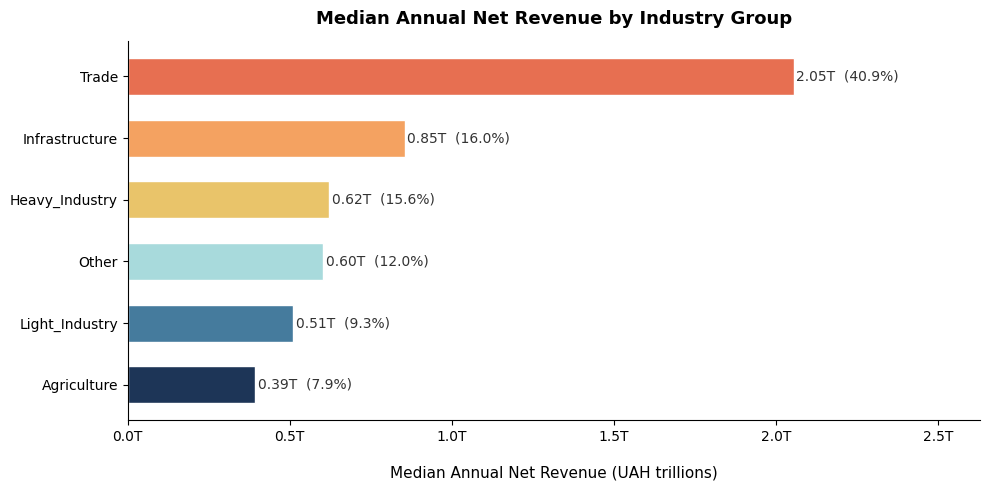

In [144]:
# ── Медіана виручки по групі (для графіку) ──
industry_revenue = (
    df_clean.groupby(['Industry_Group', 'Year'])['Net Revenue']
    .sum()
    .reset_index()
    .groupby('Industry_Group')['Net Revenue']
    .median()
)

industry_plot = industry_revenue.to_frame(name='Median_Revenue')
industry_plot['Revenue_Share'] = result['Revenue Share (%)']
industry_plot = industry_plot.sort_values('Median_Revenue', ascending=True)

# ── Plot ──
colors = ['#1d3557', '#457b9d', '#a8dadc', '#e9c46a', '#f4a261', '#e76f51']
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    industry_plot.index,
    industry_plot['Median_Revenue'],
    color=colors,
    edgecolor='white',
    height=0.6
)
for bar, (_, row) in zip(bars, industry_plot.iterrows()):
    ax.text(
        row['Median_Revenue'] + industry_plot['Median_Revenue'].max() * 0.004,
        bar.get_y() + bar.get_height() / 2,
        f"{row['Median_Revenue']/1e9:.2f}T  ({row['Revenue_Share']:.1f}%)",
        va='center', ha='left', fontsize=10, color='#333333'
    )
ax.set_xlabel('Median Annual Net Revenue (UAH trillions)', fontsize=11, labelpad=15)
ax.set_title('Median Annual Net Revenue by Industry Group', fontsize=13,
             fontweight='bold', pad=12)
ax.set_xlim(0, industry_revenue.max() * 1.28)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}T'))
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=10)
ax.grid(False)
plt.tight_layout()
plt.show()

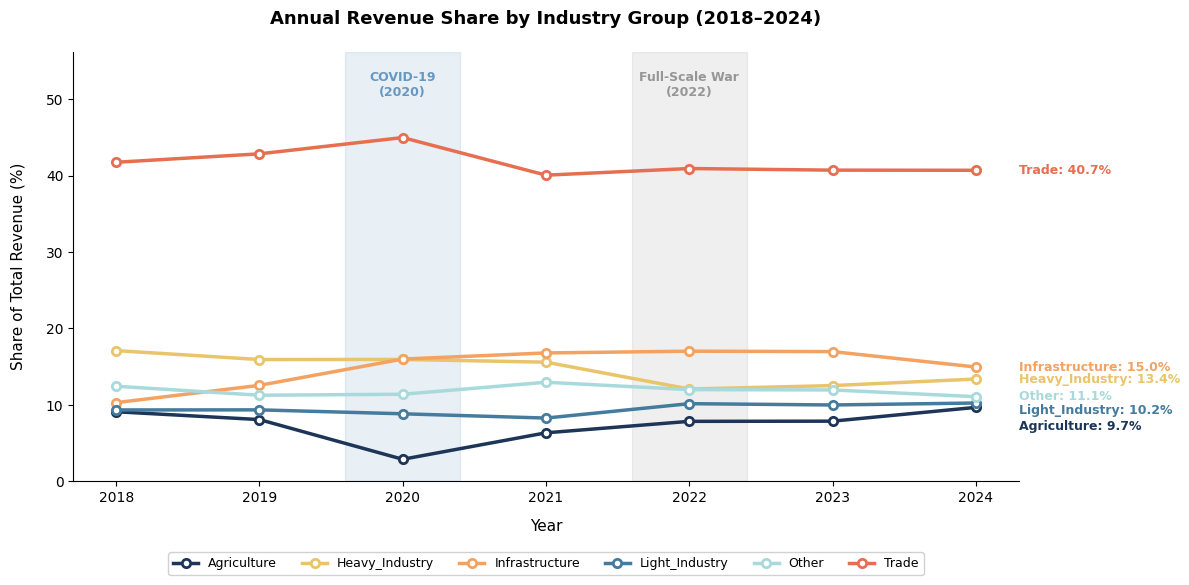

In [145]:
# ═══════════════════════════════════════════════════════════
# CELL · REVENUE SHARE BY INDUSTRY — DYNAMICS BY YEAR
# ═══════════════════════════════════════════════════════════
color_map = {
    'Trade'          : '#e76f51',
    'Infrastructure' : '#f4a261',
    'Light_Industry' : '#457b9d',
    'Heavy_Industry' : '#e9c46a',
    'Other'          : '#a8dadc',
    'Agriculture'    : '#1d3557',
}


industry_revenue_year = (
    df_clean.groupby(['Year', 'Industry_Group'])['Net Revenue']
    .sum()
    .reset_index()
)

# Частка кожної галузі в загальній виручці за рік
industry_revenue_year['Share'] = (
    industry_revenue_year.groupby('Year')['Net Revenue']
    .transform(lambda x: x / x.sum() * 100)
)

years = sorted(industry_revenue_year['Year'].unique())
industries = sorted(df_clean['Industry_Group'].dropna().unique())

fig, ax = plt.subplots(figsize=(12, 6))
offsets = {
    'Trade'          :  0.0,
    'Infrastructure' :  0.0,
    'Light_Industry' : -1.0,
    'Heavy_Industry' :  0.0,
    'Other'          : 0.0,
    'Agriculture'    :  -2.5,
}

# В циклі замість last_val використовуй:

ymax = industry_revenue_year['Share'].max()  # ~43%
ax.set_ylim(0, ymax * 1.25)  # додає 25% простору зверху



for industry in industries:
    data = industry_revenue_year[
        industry_revenue_year['Industry_Group'] == industry
    ].sort_values('Year')
    
    ax.plot(
        data['Year'].astype(str),
        data['Share'],
        color=color_map[industry],
        linewidth=2.5,
        marker='o',
        markersize=6,
        markerfacecolor='white',
        markeredgecolor=color_map[industry],
        markeredgewidth=2,
        label=industry
    )
    
    real_val = data['Share'].values[-1]
    label_pos = real_val + offsets.get(industry, 0)

    ax.text(
        len(years) - 0.7,
        label_pos,                          # позиція зі зсувом
        f'{industry}: {real_val:.1f}%',    # реальне значення
        va='center', ha='left',
        fontsize=9, color=color_map[industry], fontweight='bold'
    )

ax.axvspan(1.6, 2.4, alpha=0.12, color='steelblue')
ax.axvspan(3.6, 4.4, alpha=0.12, color='gray')
ax.text(2, ymax * 1.12 ,
        'COVID-19\n(2020)', ha='center', fontsize=9, color='steelblue', fontweight='bold', alpha=0.8)
ax.text(4, ymax * 1.12 ,
        'Full-Scale War\n(2022)', ha='center', fontsize=9, color='gray', fontweight='bold', alpha=0.8)

ax.set_title('Annual Revenue Share by Industry Group (2018–2024)',
             fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=11, labelpad=10)
ax.set_ylabel('Share of Total Revenue (%)', fontsize=11, labelpad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
          fontsize=9, ncol=6, framealpha=0.9)
ax.grid(False)

plt.tight_layout()
plt.show()

### Variables Calculation

In [146]:
# ── Profitability ──
df_clean['ROA'] = np.where(
    df_clean['Total Assets'] > 0,
    df_clean['Net Income'] / df_clean['Total Assets'],
    np.nan
)

df_clean['EBIT_Assets'] = np.where(
    df_clean['Total Assets'] > 0,
    df_clean['EBIT'] / df_clean['Total Assets'],
    np.nan
)

df_clean['Gross_Margin'] = np.where(
    df_clean['Net Revenue'] > 0,
    df_clean['Gross Profit'] / df_clean['Net Revenue'],
    np.nan
)

# ── Liquidity ──
df_clean['WC_Assets'] = np.where(
    df_clean['Total Assets'] > 0,
    (df_clean['Total Current Assets'] - df_clean['Total Current Liabilities'])
    / df_clean['Total Assets'],
    np.nan
)

df_clean['Current_Ratio'] = np.where(
    df_clean['Total Current Liabilities'] > 0,
    df_clean['Total Current Assets'] / df_clean['Total Current Liabilities'],
    np.nan
)

df_clean['Quick_Ratio'] = np.where(
    df_clean['Total Current Liabilities'] > 0,
    (df_clean['Total Current Assets'] - df_clean['Inventories'])
    / df_clean['Total Current Liabilities'],
    np.nan
)

# ── Leverage ──
df_clean['TL_Assets'] = np.where(
    df_clean['Total Assets'] > 0,
    df_clean['Total Liabilities'] / df_clean['Total Assets'],
    np.nan
)

df_clean['LT_Liab_Assets'] = np.where(
    df_clean['Total Assets'] > 0,
    df_clean['Total Long-term Liabilities'] / df_clean['Total Assets'],
    np.nan
)

df_clean['ST_Liab_Assets'] = np.where(
    df_clean['Total Assets'] > 0,
    df_clean['Total Current Liabilities'] / df_clean['Total Assets'],
    np.nan
)

df_clean['AP_Assets'] = np.where(
    df_clean['Total Assets'] > 0,
    df_clean['Accounts Payable'] / df_clean['Total Assets'],
    np.nan
)

df_clean['Has_Debt'] = (
    (df_clean['Total Debt']) > 0
).astype(int)


# ── Solvency ──
df_clean['IC_Ratio'] = np.where(
    df_clean['Financial Expenses'] > 0,
    df_clean['EBIT'] / df_clean['Financial Expenses'],
    np.nan
)

# ── Activity ──
df_clean['Asset_Turnover'] = np.where(
    df_clean['Total Assets'] > 0,
    df_clean['Net Revenue'] / df_clean['Total Assets'],
    np.nan
)

df_clean['Payables_Turnover'] = np.where(
    df_clean['Accounts Payable'] > 0,
    df_clean['COGS'] / df_clean['Accounts Payable'],
    np.nan
)

# ── Investment Opportunities ──
df_clean['PPE_prev'] = (
    df_clean
    .groupby('Firm ID')['PPE']
    .shift(1)
)

df_clean['Investment_Opportunities'] = np.where(
    df_clean['PPE_prev'] > 0,
    (df_clean['PPE'] - df_clean['PPE_prev'] + df_clean['Depreciation'])
    / df_clean['PPE_prev'],
    np.nan
)

df_clean = df_clean.drop(columns=['PPE_prev'])

# ── Size & Age ──
df_clean['Log_Assets'] = np.where(
    df_clean['Total Assets'] > 0,
    np.log(df_clean['Total Assets']),
    np.nan
)

# ── Summary ──
indicators = ['ROA', 'EBIT_Assets', 'Gross_Margin', 'WC_Assets', 'Current_Ratio',
              'Quick_Ratio', 'TL_Assets', 'LT_Liab_Assets', 'ST_Liab_Assets', 'AP_Assets',
              'Has_Debt', 'IC_Ratio', 'Asset_Turnover', 'Payables_Turnover', 
              'Investment_Opportunities', 'Log_Assets', 'Firm Age']

print("=" * 50)
print("INDICATORS")
print("=" * 50)
print(f"{'Indicator':<25} {'N present':>10}  {'% present':>10}  {'N missing':>10}")
print()
for col in indicators:
    n_present = df_clean[col].notna().sum()
    n_missing = df_clean[col].isna().sum()
    pct       = n_present / len(df_clean) * 100
    print(f"{col:<25} {n_present:>10,}  {pct:>9.1f}%  {n_missing:>10,}")

INDICATORS
Indicator                  N present   % present   N missing

ROA                           81,256      100.0%          13
EBIT_Assets                   81,255      100.0%          14
Gross_Margin                  69,496       85.5%      11,773
WC_Assets                     81,266      100.0%           3
Current_Ratio                 79,754       98.1%       1,515
Quick_Ratio                   79,754       98.1%       1,515
TL_Assets                     81,266      100.0%           3
LT_Liab_Assets                81,267      100.0%           2
ST_Liab_Assets                81,266      100.0%           3
AP_Assets                     81,266      100.0%           3
Has_Debt                      81,269      100.0%           0
IC_Ratio                      32,550       40.1%      48,719
Asset_Turnover                81,220       99.9%          49
Payables_Turnover             70,600       86.9%      10,669
Investment_Opportunities      53,859       66.3%      27,410
Log_Assets  

In [147]:
desc_vars = [
    'ROA', 'EBIT_Assets', 'Gross_Margin',
    'WC_Assets', 'Current_Ratio', 'Quick_Ratio',
    'TL_Assets', 'ST_Liab_Assets', 'LT_Liab_Assets', 'AP_Assets', 
    'IC_Ratio', 'Asset_Turnover', 'Payables_Turnover',
    'Investment_Opportunities', 'Log_Assets', 'Firm Age'
]
desc_vars = [v for v in desc_vars if v in df_clean.columns]

def get_desc(df, vars_list):
    rows = []
    for var in vars_list:
        s = df[var].dropna()
        rows.append({
            'Variable' : var,
            'N'        : len(s),
            'Mean'     : s.mean(),
            'Median'   : s.median(),
            'Std'      : s.std(),
            'Min'      : s.min(),
            'Max'      : s.max(),
            'Skewness' : s.skew(),
            'Kurtosis' : s.kurtosis(),
        })
    return pd.DataFrame(rows).set_index('Variable')

desc_before = get_desc(df_clean, desc_vars)
print("=" * 50)
print("DESCRIPTIVE STATISTICS — BEFORE WINSORIZATION")
print("=" * 50)
print(desc_before.to_string(float_format='{:.2f}'.format, col_space=12))

DESCRIPTIVE STATISTICS — BEFORE WINSORIZATION
                                    N         Mean       Median          Std          Min          Max     Skewness     Kurtosis
Variable                                                                                                                        
ROA                             81256        -0.31         0.02       119.16    -21521.77     19701.00       -30.12     23705.11
EBIT_Assets                     81255         1.34         0.02       215.23    -10170.25     41387.45       142.18     24451.13
Gross_Margin                    69496        -1.03         0.19        94.39    -17449.00       452.68      -133.17     20863.39
WC_Assets                       81266        -1.72         0.19       183.49    -36903.45         1.00      -165.91     29367.69
Current_Ratio                   79754       143.69         1.56      2976.94         0.00    517236.00       107.96     16003.49
Quick_Ratio                     79754       137.84 

In [148]:
wins_vars = [
    'ROA', 'EBIT_Assets', 'Gross_Margin',
    'WC_Assets', 'Current_Ratio', 'Quick_Ratio',
    'TL_Assets', 'ST_Liab_Assets', 'LT_Liab_Assets', 'AP_Assets',
    'IC_Ratio', 'Asset_Turnover', 'Payables_Turnover',
    'Investment_Opportunities',
]
wins_vars = [v for v in wins_vars if v in df_clean.columns]

for var in wins_vars:
    df_clean[f'{var}_orig'] = df_clean[var].copy()

# Winsorization P1/P99
for var in wins_vars:
    p1  = df_clean[f'{var}_orig'].quantile(0.01)
    p99 = df_clean[f'{var}_orig'].quantile(0.99)
    df_clean[var] = df_clean[f'{var}_orig'].clip(p1, p99)

desc_p1p99 = get_desc(df_clean, desc_vars)
print("=" * 55)
print("DESCRIPTIVE STATISTICS — AFTER WINSORIZATION P1/P99")
print("=" * 55)
print(desc_p1p99.to_string(float_format='{:.2f}'.format, col_space=12))

DESCRIPTIVE STATISTICS — AFTER WINSORIZATION P1/P99
                                    N         Mean       Median          Std          Min          Max     Skewness     Kurtosis
Variable                                                                                                                        
ROA                             81256         0.01         0.02         0.27        -1.73         0.75        -3.24        19.12
EBIT_Assets                     81255         0.02         0.02         0.27        -1.64         0.81        -2.81        16.55
Gross_Margin                    69496         0.20         0.19         0.68        -5.01         1.00        -5.13        35.81
WC_Assets                       81266         0.08         0.19         0.95        -6.44         1.00        -4.44        25.45
Current_Ratio                   79754        55.40         1.56       297.51         0.02      2510.07         7.17        52.91
Quick_Ratio                     79754        

In [149]:
wins_p5p95 = [
    'Current_Ratio', 'Quick_Ratio',
    'IC_Ratio', 'Payables_Turnover',
]

for var in wins_p5p95:
    p5  = df_clean[f'{var}_orig'].quantile(0.05)
    p95 = df_clean[f'{var}_orig'].quantile(0.95)
    df_clean[var] = df_clean[f'{var}_orig'].clip(p5, p95)

orig_cols = [f'{var}_orig' for var in wins_vars]
df_clean  = df_clean.drop(columns=orig_cols)

desc_final = get_desc(df_clean, desc_vars)
print("=" * 70)
print("DESCRIPTIVE STATISTICS — FINAL (AFTER WINSORIZATION P1/P99 and P5/P95)")
print("=" * 70)
print(desc_final.to_string(float_format='{:.2f}'.format, col_space=12))

DESCRIPTIVE STATISTICS — FINAL (AFTER WINSORIZATION P1/P99 and P5/P95)
                                    N         Mean       Median          Std          Min          Max     Skewness     Kurtosis
Variable                                                                                                                        
ROA                             81256         0.01         0.02         0.27        -1.73         0.75        -3.24        19.12
EBIT_Assets                     81255         0.02         0.02         0.27        -1.64         0.81        -2.81        16.55
Gross_Margin                    69496         0.20         0.19         0.68        -5.01         1.00        -5.13        35.81
WC_Assets                       81266         0.08         0.19         0.95        -6.44         1.00        -4.44        25.45
Current_Ratio                   79754        12.08         1.56        29.87         0.18       125.96         3.17         8.78
Quick_Ratio               

### Proxy Modeling

#### Revenue Growth

In [150]:
df_clean['Rev_prev'] = df_clean.groupby('Firm ID')['Net Revenue'].shift(1)

# Revenue Growth: both current and previous year must be > 0
df_clean['Revenue_Growth'] = np.where(
    (df_clean['Rev_prev'] > 0) & (df_clean['Net Revenue'] > 0),
    (df_clean['Net Revenue'] - df_clean['Rev_prev']) / df_clean['Rev_prev'],
    np.nan
)

In [151]:
def desc_single(series, name):
    s = series.dropna()
    return pd.DataFrame([{
        'Variable' : name,
        'Mean'     : s.mean(),
        'Median'   : s.median(),
        'Std'      : s.std(),
        'Min'      : s.min(),
        'Max'      : s.max(),
        'Skewness' : s.skew(),
        'Kurtosis' : s.kurtosis(),
    }]).set_index('Variable')

print("=" * 65)
print("DESCRIPTIVE STATISTICS — REVENUE GROWTH (BEFORE WINSORIZATION)")
print("=" * 65)
print(desc_single(df_clean['Revenue_Growth'], 'Revenue_Growth')
      .to_string(float_format='{:.2f}'.format, col_space=12))

# Winsorization P5/P95
p5  = df_clean['Revenue_Growth'].quantile(0.05)
p95 = df_clean['Revenue_Growth'].quantile(0.95)
n_clipped = ((df_clean['Revenue_Growth'] < p5) |
             (df_clean['Revenue_Growth'] > p95)).sum()
df_clean['Revenue_Growth'] = df_clean['Revenue_Growth'].clip(p5, p95)

print()
print("=" * 65)
print("DESCRIPTIVE STATISTICS — REVENUE GROWTH (AFTER WINSORIZATION)")
print("=" * 65)
print(desc_single(df_clean['Revenue_Growth'], 'Revenue_Growth')
      .to_string(float_format='{:.2f}'.format, col_space=12))

DESCRIPTIVE STATISTICS — REVENUE GROWTH (BEFORE WINSORIZATION)
                       Mean       Median          Std          Min          Max     Skewness     Kurtosis
Variable                                                                                                 
Revenue_Growth        33.38         0.08      3934.23        -1.00    867743.97       205.12     44728.33

DESCRIPTIVE STATISTICS — REVENUE GROWTH (AFTER WINSORIZATION)
                       Mean       Median          Std          Min          Max     Skewness     Kurtosis
Variable                                                                                                 
Revenue_Growth         0.16         0.08         0.58        -0.73         1.76         1.09         1.39


In [152]:
pivot = (
    df_clean[df_clean['Year'] >= 2019]
    .groupby(['Industry_Group', 'Year'])['Revenue_Growth']
    .mean()
    .mul(100)
    .round(1)
    .unstack('Year')
)
pivot['Overall Mean'] = pivot.mean(axis=1).round(1)

def style_growth_table(df):
    return (
        df.style
        .format('{:.1f}%', na_rep='—')
        .background_gradient(cmap='RdYlGn', axis=None, vmin=-30, vmax=50,
                             subset=df.columns[:-1])
        .background_gradient(cmap='RdYlGn', axis=None, vmin=-30, vmax=50,
                             subset=['Overall Mean'])
        .set_properties(**{'font-size': '11px', 'text-align': 'center',
                           'border': '1px solid #e0e0e0', 'padding': '6px 10px'})
        .set_properties(subset=pd.IndexSlice[:, ['Overall Mean']],
                        **{'font-weight': 'bold', 'border-left': '2px solid #555'})
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#2c3e50'),
                                         ('color', 'white'), ('font-size', '11px'),
                                         ('text-align', 'center'), ('padding', '8px 10px')]},
            {'selector': 'tr:hover', 'props': [('background-color', '#f5f5f5')]},
        ])
        .set_caption('Average Revenue Growth (%) by Industry Group and Year')
    )

display(style_growth_table(pivot))

Year,2019,2020,2021,2022,2023,2024,Overall Mean
Industry_Group,,,,,,,
Agriculture,7.8%,5.5%,45.6%,-4.2%,29.1%,31.1%,19.2%
Heavy_Industry,2.7%,1.0%,34.6%,-15.9%,37.5%,22.2%,13.7%
Infrastructure,13.6%,0.3%,24.5%,-8.9%,24.9%,19.8%,12.4%
Light_Industry,2.6%,3.8%,18.4%,9.8%,22.8%,13.2%,11.8%
Other,23.2%,11.6%,31.6%,-1.2%,31.3%,26.9%,20.6%
Trade,8.3%,1.8%,27.5%,-8.3%,33.2%,15.9%,13.1%


#### Composite Proxy

In [153]:
# ── Criterion 1: EBITDA < 0 ──
df_clean['Distress_EBITDA'] = np.where(
    df_clean['EBITDA'].notna(),
    (df_clean['EBITDA'] < 0).astype(int),
    np.nan
)

# ── Criterion 2: Total Equity < 0 ──
df_clean['Distress_Equity'] = np.where(
    df_clean['Total Equity'].notna(),
    (df_clean['Total Equity'] < 0).astype(int),
    np.nan
)

# ── Criterion 3: Revenue Distress ──
industry_year_stats = (
    df_clean[
        (df_clean['Year'] >= 2019) &
        (df_clean['Revenue_Growth'].notna())
    ]
    .groupby(['Industry_Group', 'Year'])['Revenue_Growth']
    .agg(mean='mean', std='std')
    .reset_index()
)
industry_year_stats['threshold'] = (
    industry_year_stats['mean'] - 0.5 * industry_year_stats['std']
)

df_clean = df_clean.merge(
    industry_year_stats[['Industry_Group', 'Year', 'threshold']],
    on=['Industry_Group', 'Year'],
    how='left'
)

df_clean['Distress_Revenue_Growth'] = np.where(
    df_clean['Revenue_Growth'].notna(),
    ((df_clean['Revenue_Growth'] < 0) &
     (df_clean['Revenue_Growth'] < df_clean['threshold'])).astype(int),
    np.nan
)

df_clean = df_clean.drop(columns=['threshold'])

# ── Composite: >= 2 of 3 (2019–2024 only) ──
df_clean['Distress_Score'] = np.where(
    df_clean['Year'] >= 2019,
    df_clean[['Distress_EBITDA', 'Distress_Revenue_Growth',
              'Distress_Equity']].sum(axis=1, min_count=1),
    np.nan
)

df_clean['Financial_Distress'] = np.where(
    df_clean['Distress_Score'].notna(),
    (df_clean['Distress_Score'] >= 2).astype(int),
    np.nan
)

# ── Summary ──
ana = df_clean[df_clean['Financial_Distress'].notna()]

print("CRITERIA INCIDENCE (2019–2024)")
print("=" * 55)
print(f"  Observations  : {len(ana):,}")
print(f"  Unique firms  : {ana['Firm ID'].nunique():,}")
print()
print(f"  Distress_EBITDA          = 1 : "
      f"{(ana['Distress_EBITDA'] == 1).sum():,}  "
      f"({(ana['Distress_EBITDA'] == 1).mean() * 100:.1f}%)")
print(f"  Distress_Equity          = 1 : "
      f"{(ana['Distress_Equity'] == 1).sum():,}  "
      f"({(ana['Distress_Equity'] == 1).mean() * 100:.1f}%)")
print(f"  Distress_Revenue_Growth  = 1 : "
      f"{(ana['Distress_Revenue_Growth'] == 1).sum():,}  "
      f"({(ana['Distress_Revenue_Growth'] == 1).mean() * 100:.1f}%)")
print()
print("COMPOSITE — FINANCIAL DISTRESS (>= 2 of 3)")
print("=" * 55)
print(f"  Distress (1) : {(ana['Financial_Distress'] == 1).sum():,}  "
      f"({(ana['Financial_Distress'] == 1).mean() * 100:.1f}%)")
print(f"  Healthy  (0) : {(ana['Financial_Distress'] == 0).sum():,}  "
      f"({(ana['Financial_Distress'] == 0).mean() * 100:.1f}%)")
print()
print("BY YEAR:")
print(ana.groupby('Year')['Financial_Distress']
      .agg(N_distress   = lambda x: (x == 1).sum(),
           N_total      = 'count',
           Distress_pct = lambda x: (x == 1).mean() * 100)
      .round(1).to_string())
print()
print("BY INDUSTRY:")
print(ana.groupby('Industry_Group')['Financial_Distress']
      .agg(N_distress   = lambda x: (x == 1).sum(),
           N_total      = 'count',
           Distress_pct = lambda x: (x == 1).mean() * 100)
      .round(1)
      .sort_values('Distress_pct', ascending=False)
      .to_string())

CRITERIA INCIDENCE (2019–2024)
  Observations  : 70,351
  Unique firms  : 18,183

  Distress_EBITDA          = 1 : 19,850  (28.2%)
  Distress_Equity          = 1 : 8,976  (12.8%)
  Distress_Revenue_Growth  = 1 : 14,095  (20.0%)

COMPOSITE — FINANCIAL DISTRESS (>= 2 of 3)
  Distress (1) : 9,670  (13.7%)
  Healthy  (0) : 60,681  (86.3%)

BY YEAR:
      N_distress  N_total  Distress_pct
Year                                   
2019        1661    12528          13.3
2020        1667    10673          15.6
2021        1458    12635          11.5
2022        1944    12117          16.0
2023        1622    11900          13.6
2024        1318    10498          12.6

BY INDUSTRY:
                N_distress  N_total  Distress_pct
Industry_Group                                   
Infrastructure        1698     7185          23.6
Heavy_Industry        1607     8209          19.6
Light_Industry         763     5499          13.9
Trade                 1382    10676          12.9
Other              

In [154]:
# ═══════════════════════════════════════════════════════════
# CELL · CRITERIA INDEPENDENCE — PHI COEFFICIENT
# ═══════════════════════════════════════════════════════════

from scipy.stats import chi2_contingency
import itertools

def phi_coefficient(x, y):
    ct = pd.crosstab(x, y)
    chi2, p, _, _ = chi2_contingency(ct)
    n = ct.values.sum()
    phi = np.sqrt(chi2 / n)
    return phi, p

criteria = {
    'EBITDA<0'  : 'Distress_EBITDA',
    'Rev↓'      : 'Distress_Revenue_Growth',
    'Equity<0'  : 'Distress_Equity',
}

# Тільки де всі три критерії є
mask = (
    ana['Distress_EBITDA'].notna() &
    ana['Distress_Revenue_Growth'].notna() &
    ana['Distress_Equity'].notna()
)
tmp = ana[mask].copy()

print("CRITERIA INDEPENDENCE — φ-COEFFICIENT")
print("=" * 60)
print(f"{'Pair':<40} {'φ':>8}  {'p-value':>10}  {'Interpretation':>15}")
print("-" * 60)

for (name_a, col_a), (name_b, col_b) in itertools.combinations(criteria.items(), 2):
    phi, p = phi_coefficient(tmp[col_a], tmp[col_b])
    
    if phi < 0.2:
        interp = '✓ weak'
    elif phi < 0.4:
        interp = '⚠ moderate'
    else:
        interp = '✗ strong'
    
    pair = f"{name_a}  vs  {name_b}"
    print(f"{pair:<40} {phi:>8.3f}  {p:>10.4f}  {interp:>15}")

print()
print("Interpretation:")
print("  φ < 0.20  → weak correlation   → criteria are sufficiently independent")
print("  φ < 0.40  → moderate           → acceptable for composite proxy")
print("  φ ≥ 0.40  → strong             → criteria overlap significantly")

CRITERIA INDEPENDENCE — φ-COEFFICIENT
Pair                                            φ     p-value   Interpretation
------------------------------------------------------------
EBITDA<0  vs  Rev↓                          0.228      0.0000       ⚠ moderate
EBITDA<0  vs  Equity<0                      0.317      0.0000       ⚠ moderate
Rev↓  vs  Equity<0                          0.102      0.0000           ✓ weak

Interpretation:
  φ < 0.20  → weak correlation   → criteria are sufficiently independent
  φ < 0.40  → moderate           → acceptable for composite proxy
  φ ≥ 0.40  → strong             → criteria overlap significantly


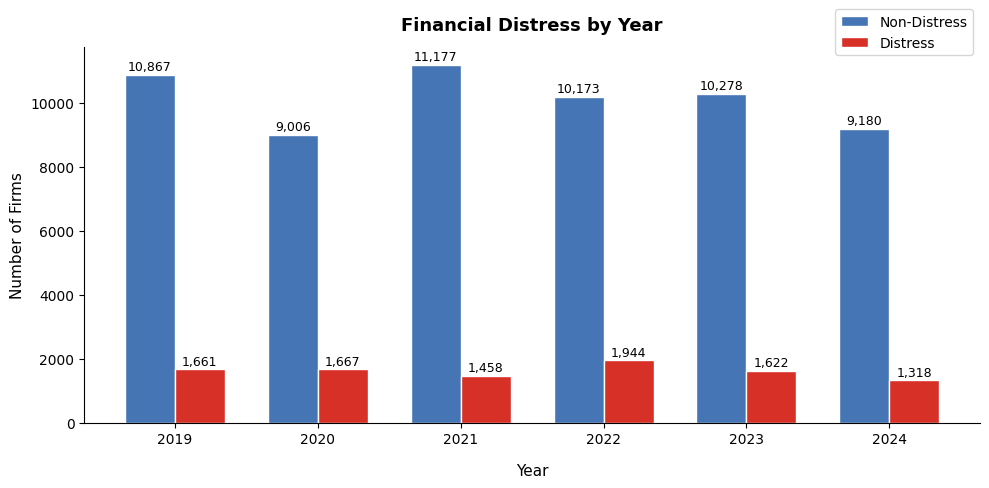

In [155]:
# ═══════════════════════════════════════════════════════════
# CELL · FINANCIAL DISTRESS BY YEAR — ABSOLUTE
# ═══════════════════════════════════════════════════════════

yearly = (
    ana.groupby('Year')['Financial_Distress']
    .agg(
        Distress     = lambda x: (x == 1).sum(),
        Non_Distress = lambda x: (x == 0).sum(),
        Total        = 'count',
        Distress_pct = lambda x: (x == 1).mean() * 100
    )
    .reset_index()
)
yearly['Year'] = yearly['Year'].astype(int)

fig, ax = plt.subplots(figsize=(10, 5))

x     = np.arange(len(yearly))
width = 0.35

bars1 = ax.bar(x - width/2, yearly['Non_Distress'],
               width, label='Non-Distress',
               color='#4575b4', edgecolor='white')
bars2 = ax.bar(x + width/2, yearly['Distress'],
               width, label='Distress',
               color='#d73027', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50,
            f'{int(bar.get_height()):,}',
            ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50,
            f'{int(bar.get_height()):,}',
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(yearly['Year'])
ax.set_xlabel('Year', fontsize=11, labelpad=12)
ax.set_ylabel('Number of Firms', fontsize=11)
ax.set_title('Financial Distress by Year',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10,
          loc='upper right', bbox_to_anchor=(1, 1.12))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()

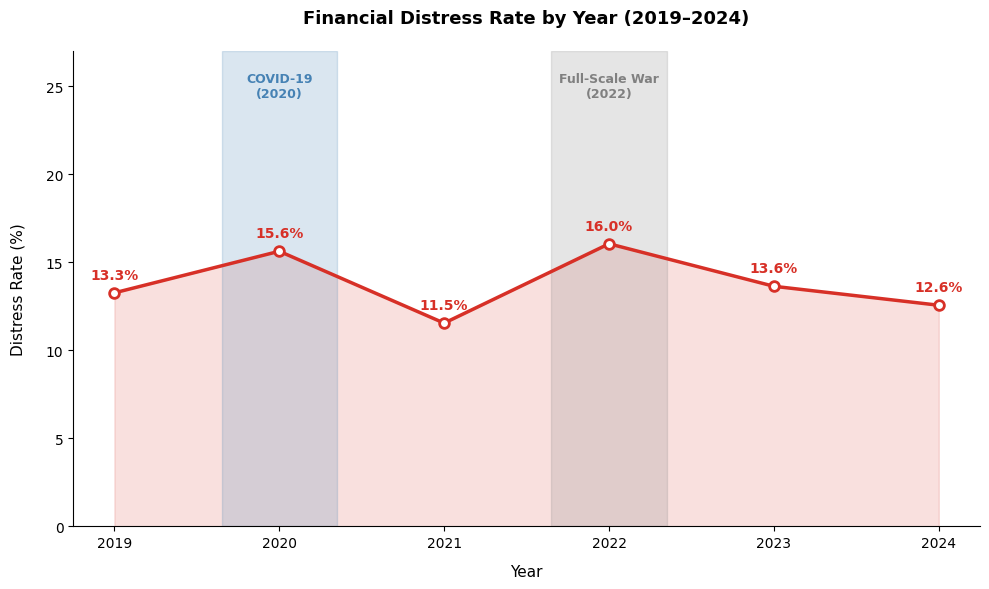

In [156]:
# ═══════════════════════════════════════════════════════════
# CELL · DISTRESS RATE BY YEAR — SHARE %
# ═══════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(yearly['Year'], yearly['Distress_pct'],
                alpha=0.15, color='#d73027')
ax.plot(yearly['Year'], yearly['Distress_pct'],
        color='#d73027', lw=2.5, marker='o',
        markersize=7, markerfacecolor='white',
        markeredgewidth=2)

for _, row in yearly.iterrows():
    ax.annotate(f"{row['Distress_pct']:.1f}%",
                xy=(row['Year'], row['Distress_pct']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=10,
                color='#d73027', fontweight='bold')
    


# ── Стрілки замість пунктиру ──
covid_y = yearly.loc[yearly['Year'] == 2020, 'Distress_pct'].values[0]
war_y   = yearly.loc[yearly['Year'] == 2022, 'Distress_pct'].values[0]

ax.axvspan(2019.65, 2020.35, alpha=0.2, color='steelblue')
ax.axvspan(2021.65, 2022.35, alpha=0.2, color='gray')

ymax = yearly['Distress_pct'].max()
ax.text(2020, ymax * 1.52, 'COVID-19\n(2020)',
        ha='center', fontsize=9, color='steelblue',
        fontweight='bold')
ax.text(2022, ymax * 1.52, 'Full-Scale War\n(2022)',
        ha='center', fontsize=9, color='gray',
        fontweight='bold')

ax.set_xlabel('Year', fontsize=11, labelpad=10)
ax.set_ylabel('Distress Rate (%)', fontsize=11, labelpad=15)
ax.set_title('Financial Distress Rate by Year (2019–2024)',
             fontsize=13, fontweight='bold', pad=20)
ax.set_ylim(0, 27)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()

In [157]:
status_distress = (
    ana.merge(
        df_clean[['Firm ID', 'Firm Status (Latest)']].drop_duplicates('Firm ID'),
        on='Firm ID', how='left'
    )
    .groupby('Firm Status (Latest)_y')['Firm ID']
    .nunique()
    .reset_index()
    .rename(columns={
        'Firm Status (Latest)_y': 'Status',
        'Firm ID': 'Unique Firms'
    })
)

# Дистрес по унікальних фірмах
distress_firms = (
    ana[ana['Financial_Distress'] == 1]
    .merge(
        df_clean[['Firm ID', 'Firm Status (Latest)']].drop_duplicates('Firm ID'),
        on='Firm ID', how='left'
    )
    .groupby('Firm Status (Latest)_y')['Firm ID']
    .nunique()
    .reset_index()
    .rename(columns={
        'Firm Status (Latest)_y': 'Status',
        'Firm ID': 'Distressed Firms'
    })
)

result = status_distress.merge(distress_firms, on='Status', how='left')
result['Healthy Firms'] = result['Unique Firms'] - result['Distressed Firms']
result['Distress (%)'] = (result['Distressed Firms'] / result['Unique Firms'] * 100).round(1)
result = result.sort_values('Distress (%)', ascending=False)

status_map = {
    'Не перебуває в процесі припинення'        : 'Active',
    'В стані припинення'                        : 'In liquidation',
    'Припинено'                                 : 'Liquidated',
    'Порушено справу про банкрутство'           : 'Bankruptcy proceedings',
    'Порушено справу про банкрутство (санація)' : 'Bankruptcy (restructuring)',
}

result['Status'] = result['Status'].replace(status_map)

print("=" * 75)
print("DISTRESS BY FIRM STATUS (Unique Firms)")
print("=" * 75)
print(result.to_string(index=False))

DISTRESS BY FIRM STATUS (Unique Firms)
                    Status  Unique Firms  Distressed Firms  Healthy Firms  Distress (%)
Bankruptcy (restructuring)            36                27              9          75.0
    Bankruptcy proceedings           126                71             55          56.3
            In liquidation           799               401            398          50.2
                Liquidated           731               229            502          31.3
                    Active         16491              4412          12079          26.8


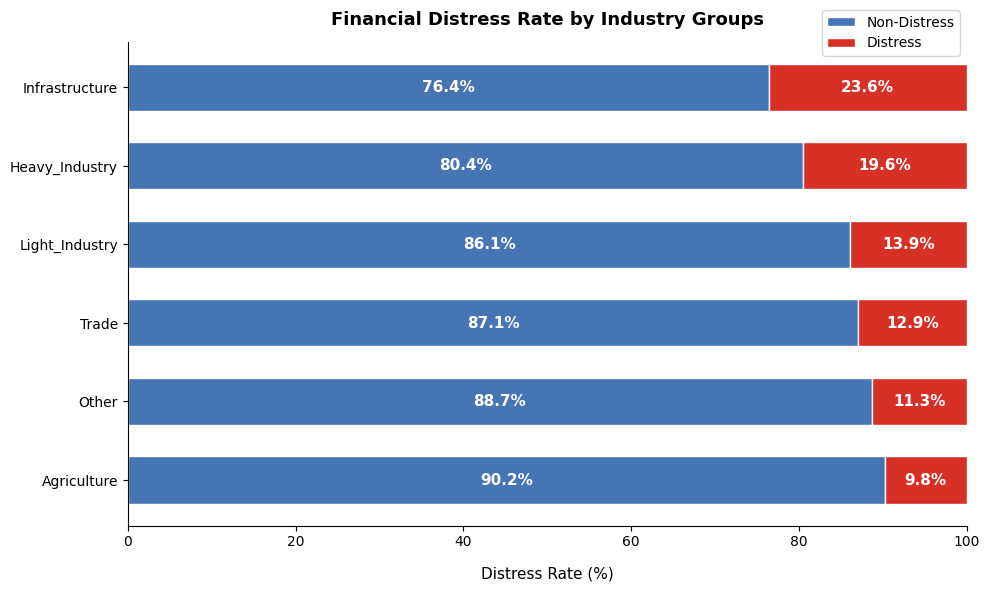

In [158]:
# ═══════════════════════════════════════════════════════════
# CELL · FIGURE 2 — DISTRESS BY INDUSTRY (STACKED BAR)
# ═══════════════════════════════════════════════════════════

industry = (
    ana.groupby('Industry_Group')['Financial_Distress']
    .agg(
        Distress     = lambda x: (x == 1).mean() * 100,
        Non_Distress = lambda x: (x == 0).mean() * 100,
    )
    .reset_index()
    .sort_values('Distress', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

bars_nd = ax.barh(industry['Industry_Group'],
                  industry['Non_Distress'],
                  color='#4575b4', edgecolor='white',
                  label='Non-Distress', height=0.6)
bars_d  = ax.barh(industry['Industry_Group'],
                  industry['Distress'],
                  left=industry['Non_Distress'],
                  color='#d73027', edgecolor='white',
                  label='Distress', height=0.6)

for bar, val in zip(bars_nd, industry['Non_Distress']):
    ax.text(val/2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', ha='center', va='center',
            fontsize=11, color='white', fontweight='bold')
for bar, val, left in zip(bars_d, industry['Distress'],
                           industry['Non_Distress']):
    ax.text(left + val/2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', ha='center', va='center',
            fontsize=11, color='white', fontweight='bold')

ax.set_xlabel('Distress Rate (%)', fontsize=11, labelpad=12)
ax.set_title('Financial Distress Rate by Industry Groups',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='upper right', fontsize=10, bbox_to_anchor=(1, 1.08))
ax.set_xlim(0, 100)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()

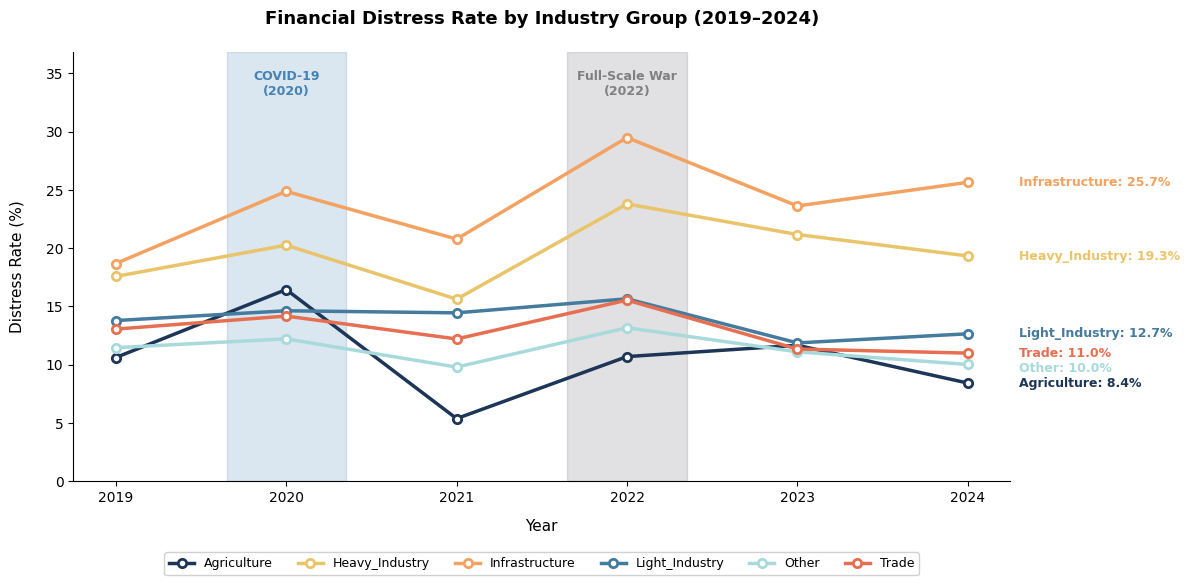

In [159]:
# ═══════════════════════════════════════════════════════════
# CELL · DISTRESS RATE BY INDUSTRY — DYNAMICS BY YEAR
# ═══════════════════════════════════════════════════════════

distress_year = (
    ana.groupby(['Year', 'Industry_Group'])['Financial_Distress']
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={'Financial_Distress': 'Distress_Rate'})
)

years = sorted(distress_year['Year'].unique())
industries = sorted(ana['Industry_Group'].dropna().unique())

offsets = {
    'Trade'          :  0.0,
    'Infrastructure' :  0.0,
    'Light_Industry' : 0.0,
    'Heavy_Industry' :  0.0,
    'Other'          : -0.3,
    'Agriculture'    :  0.0,
}

fig, ax = plt.subplots(figsize=(12, 6))

for industry in industries:
    data = distress_year[
        distress_year['Industry_Group'] == industry
    ].sort_values('Year')

    ax.plot(
        data['Year'].astype(str),
        data['Distress_Rate'],
        color=color_map[industry],
        linewidth=2.5,
        marker='o',
        markersize=6,
        markerfacecolor='white',
        markeredgecolor=color_map[industry],
        markeredgewidth=2,
        label=industry
    )

    last_val = data['Distress_Rate'].values[-1]
    ax.text(
        len(years) - 0.7,
        last_val + offsets.get(industry, 0),
        f'{industry}: {last_val:.1f}%',
        va='center', ha='left',
        fontsize=9, color=color_map[industry],
        fontweight='bold'
    )

x_pos = {str(y): i for i, y in enumerate(years)}
ax.axvspan(x_pos['2019'] + 0.65, x_pos['2020'] + 0.35, alpha=0.2, color='steelblue')
ax.axvspan(x_pos['2021'] + 0.65, x_pos['2022'] + 0.35, alpha=0.2, color='#6d6875')

y_max = distress_year['Distress_Rate'].max()
ax.set_ylim(0, y_max * 1.25)

ax.text(x_pos['2020'], y_max * 1.125, 'COVID-19\n(2020)',
        ha='center', fontsize=9, color='steelblue', fontweight='bold')
ax.text(x_pos['2022'], y_max * 1.125, 'Full-Scale War\n(2022)',
        ha='center', fontsize=9, color='gray', fontweight='bold')

ax.set_title('Financial Distress Rate by Industry Group (2019–2024)',
             fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=11, labelpad=10)
ax.set_ylabel('Distress Rate (%)', fontsize=11, labelpad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
          fontsize=9, ncol=6, framealpha=0.9)
ax.grid(False)

plt.tight_layout()
plt.show()


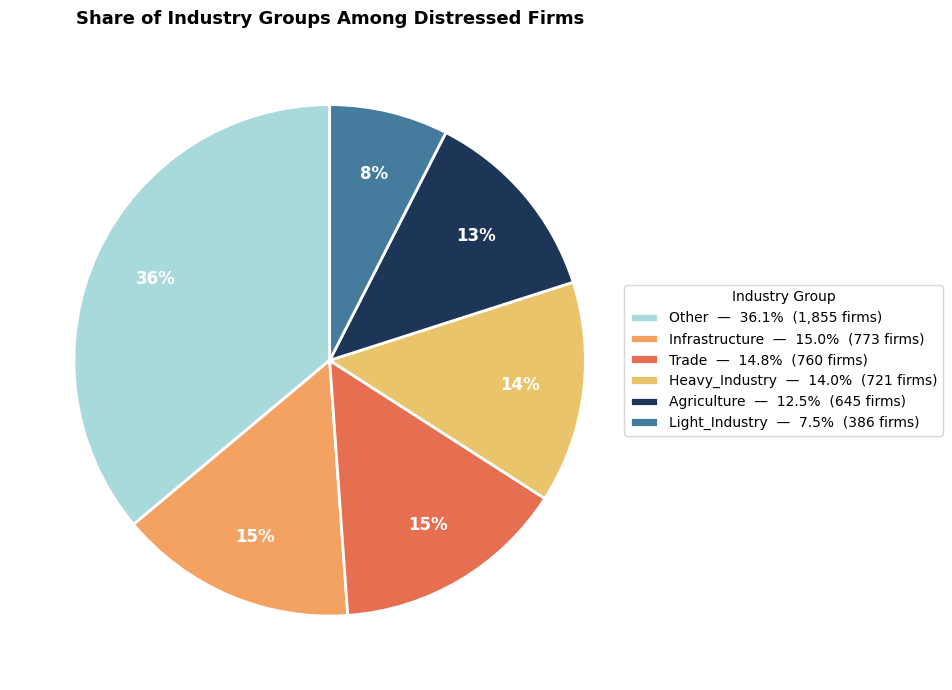

In [160]:
# ═══════════════════════════════════════════════════════════
# CELL · FIGURE 3 — INDUSTRY SHARE AMONG DISTRESSED FIRMS
# ═══════════════════════════════════════════════════════════

distressed = ana[ana['Financial_Distress'] == 1]

industry_dist = (
    distressed.groupby('Industry_Group')['Firm ID']
    .nunique()
    .reset_index()
    .rename(columns={'Firm ID': 'N_firms'})
    .sort_values('N_firms', ascending=False)
)
industry_dist['Share'] = (
    industry_dist['N_firms'] / industry_dist['N_firms'].sum() * 100
)

colors_pie = ['#a8dadc', '#f4a261', '#e76f51','#e9c46a', '#1d3557', '#457b9d']


fig, ax = plt.subplots(figsize=(9, 7))

wedges, texts, autotexts = ax.pie(
    industry_dist['Share'],
    labels=None,
    colors=colors_pie,
    autopct='%1.0f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
)

for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

legend_labels = [
    f"{row['Industry_Group']}  —  {row['Share']:.1f}%  ({row['N_firms']:,} firms)"
    for _, row in industry_dist.iterrows()
]
ax.legend(wedges, legend_labels,
          title='Industry Group',
          loc='center left',
          bbox_to_anchor=(0.95, 0.5),
          fontsize=10)

ax.set_title('Share of Industry Groups Among Distressed Firms',
             fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

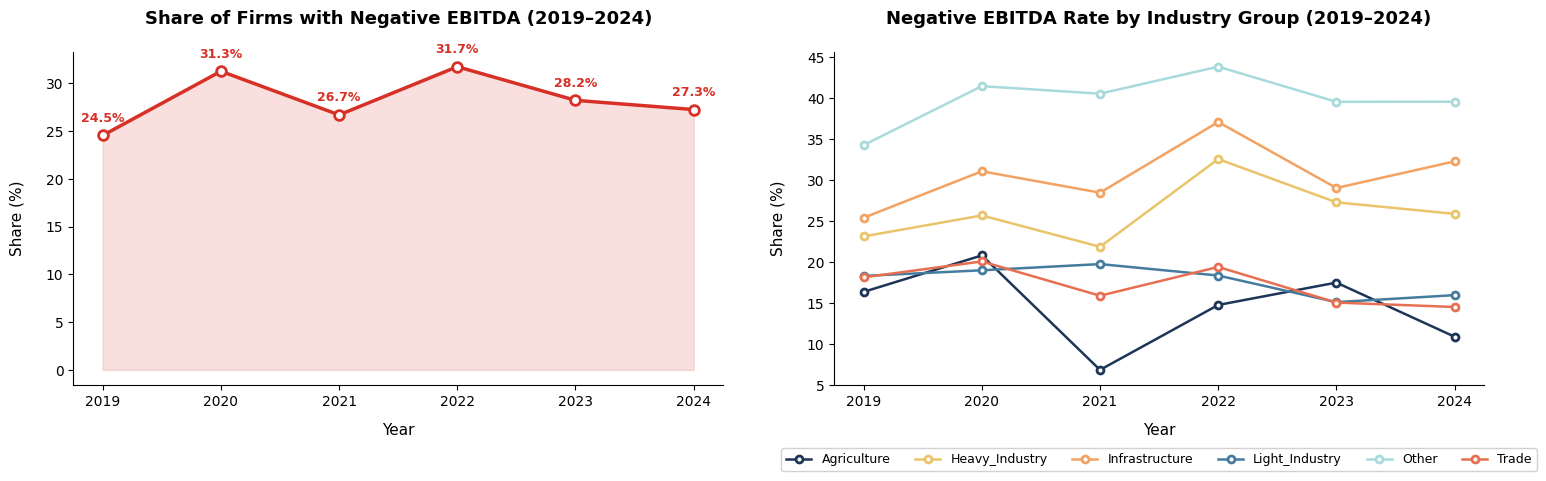

In [161]:
# ── EBITDA < 0 ──
col, title, color = 'Distress_EBITDA', 'EBITDA < 0', '#d73027'

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax_left, ax_right = axes[0], axes[1]

yearly_c = (
    ana.groupby('Year')[col]
    .agg(Share=lambda x: (x == 1).mean() * 100)
    .reset_index()
)
yearly_c['Year'] = yearly_c['Year'].astype(int)

ax_left.fill_between(yearly_c['Year'], yearly_c['Share'], alpha=0.15, color=color)
ax_left.plot(yearly_c['Year'], yearly_c['Share'], color=color, lw=2.5, marker='o',
             markersize=7, markerfacecolor='white', markeredgewidth=2)
for _, r in yearly_c.iterrows():
    ax_left.annotate(f"{r['Share']:.1f}%", xy=(r['Year'], r['Share']),
                     xytext=(0, 10), textcoords='offset points',
                     ha='center', fontsize=9, color=color, fontweight='bold')

y_max_l = yearly_c['Share'].max()
ax_left.set_title('Share of Firms with Negative EBITDA (2019–2024)', fontsize=13, fontweight='bold', pad=20)
ax_left.set_xlabel('Year', fontsize=11, labelpad=10)
ax_left.set_ylabel('Share (%)', fontsize=11, labelpad=15)
ax_left.spines[['top', 'right']].set_visible(False)
ax_left.grid(False)

for industry in industries:
    ind_data = (
        ana[ana['Industry_Group'] == industry]
        .groupby('Year')[col]
        .agg(Share=lambda x: (x == 1).mean() * 100)
        .reset_index()
    )
    ind_data['Year'] = ind_data['Year'].astype(int)
    ax_right.plot(ind_data['Year'], ind_data['Share'],
                  color=color_map[industry], lw=1.8, marker='o', markersize=5,
                  label=industry, markerfacecolor='white', markeredgecolor=color_map[industry], markeredgewidth=2,)

y_max_r = max(
    ana[ana['Industry_Group'] == ind].groupby('Year')[col]
    .mean().max() * 100 for ind in industries
)



ax_right.set_title('Negative EBITDA Rate by Industry Group (2019–2024)', fontsize=13, fontweight='bold', pad=20)
ax_right.set_xlabel('Year', fontsize=11, labelpad=10)
ax_right.set_ylabel('Share (%)', fontsize=11, labelpad=15)
ax_right.legend(loc='upper center', bbox_to_anchor=(0.5, -0.17),
                fontsize=9, ncol=6, framealpha=0.9)
ax_right.spines[['top', 'right']].set_visible(False)
ax_right.grid(False)

plt.tight_layout()
plt.show()

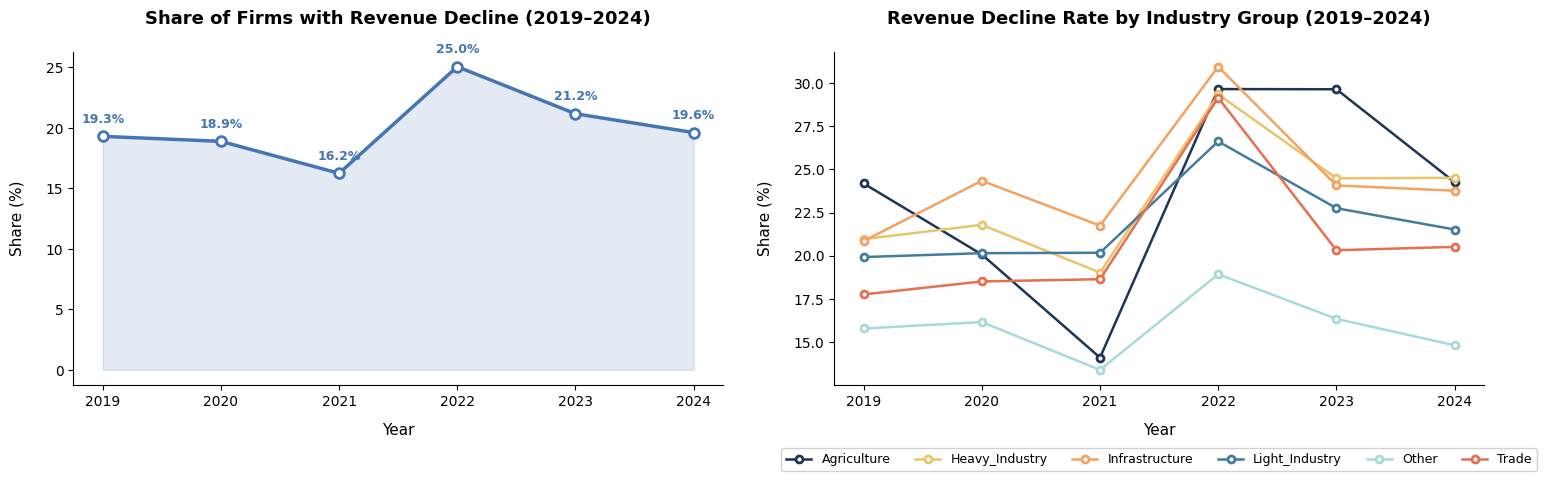

In [162]:
# ── EBITDA < 0 ──
col, title, color = 'Distress_Revenue_Growth', 'Revenue Decline', '#4575b4'
# решта коду ідентична

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax_left, ax_right = axes[0], axes[1]

yearly_c = (
    ana.groupby('Year')[col]
    .agg(Share=lambda x: (x == 1).mean() * 100)
    .reset_index()
)
yearly_c['Year'] = yearly_c['Year'].astype(int)

ax_left.fill_between(yearly_c['Year'], yearly_c['Share'], alpha=0.15, color=color)
ax_left.plot(yearly_c['Year'], yearly_c['Share'], color=color, lw=2.5, marker='o',
             markersize=7, markerfacecolor='white', markeredgewidth=2)
for _, r in yearly_c.iterrows():
    ax_left.annotate(f"{r['Share']:.1f}%", xy=(r['Year'], r['Share']),
                     xytext=(0, 10), textcoords='offset points',
                     ha='center', fontsize=9, color=color, fontweight='bold')

ax_left.set_title(f'Share of Firms with Revenue Decline (2019–2024)', fontsize=13, fontweight='bold', pad=20)
ax_left.set_xlabel('Year', fontsize=11, labelpad=10)
ax_left.set_ylabel('Share (%)', fontsize=11, labelpad=15)
ax_left.spines[['top', 'right']].set_visible(False)
ax_left.grid(False)

for industry in industries:
    ind_data = (
        ana[ana['Industry_Group'] == industry]
        .groupby('Year')[col]
        .agg(Share=lambda x: (x == 1).mean() * 100)
        .reset_index()
    )
    ind_data['Year'] = ind_data['Year'].astype(int)
    ax_right.plot(ind_data['Year'], ind_data['Share'],
                  color=color_map[industry], lw=1.8, marker='o', markersize=5,
                  label=industry, markerfacecolor='white', markeredgecolor=color_map[industry], markeredgewidth=2,)

y_max_r = max(
    ana[ana['Industry_Group'] == ind].groupby('Year')[col]
    .mean().max() * 100 for ind in industries
)
ax_right.set_title('Revenue Decline Rate by Industry Group (2019–2024)', fontsize=13, fontweight='bold', pad=20)
ax_right.set_xlabel('Year', fontsize=11, labelpad=10)
ax_right.set_ylabel('Share (%)', fontsize=11, labelpad=15)
ax_right.legend(loc='upper center', bbox_to_anchor=(0.5, -0.17),
                fontsize=9, ncol=6, framealpha=0.9)
ax_right.spines[['top', 'right']].set_visible(False)
ax_right.grid(False)

plt.tight_layout()
plt.show()

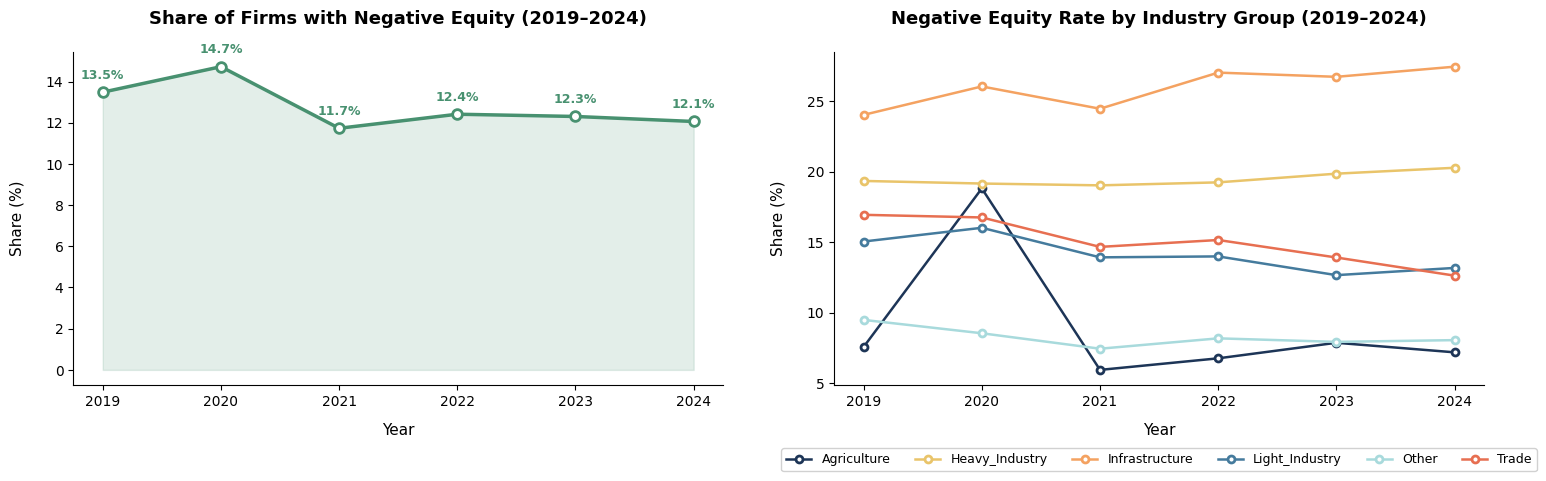

In [163]:
col, title, color = 'Distress_Equity', 'Equity < 0', "#489170"
# решта коду ідентична

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax_left, ax_right = axes[0], axes[1]

yearly_c = (
    ana.groupby('Year')[col]
    .agg(Share=lambda x: (x == 1).mean() * 100)
    .reset_index()
)
yearly_c['Year'] = yearly_c['Year'].astype(int)

ax_left.fill_between(yearly_c['Year'], yearly_c['Share'], alpha=0.15, color=color)
ax_left.plot(yearly_c['Year'], yearly_c['Share'], color=color, lw=2.5, marker='o',
             markersize=7, markerfacecolor='white', markeredgewidth=2)
for _, r in yearly_c.iterrows():
    ax_left.annotate(f"{r['Share']:.1f}%", xy=(r['Year'], r['Share']),
                     xytext=(0, 10), textcoords='offset points',
                     ha='center', fontsize=9, color=color, fontweight='bold')


ax_left.set_title('Share of Firms with Negative Equity (2019–2024)', fontsize=13, fontweight='bold', pad=20)
ax_left.set_xlabel('Year', fontsize=11, labelpad=10)
ax_left.set_ylabel('Share (%)', fontsize=11, labelpad=15)
ax_left.spines[['top', 'right']].set_visible(False)
ax_left.grid(False)

for industry in industries:
    ind_data = (
        ana[ana['Industry_Group'] == industry]
        .groupby('Year')[col]
        .agg(Share=lambda x: (x == 1).mean() * 100)
        .reset_index()
    )
    ind_data['Year'] = ind_data['Year'].astype(int)
    ax_right.plot(ind_data['Year'], ind_data['Share'],
                  color=color_map[industry], lw=1.8, marker='o', markersize=5,
                  label=industry, markerfacecolor='white', markeredgecolor=color_map[industry], markeredgewidth=2,)

y_max_r = max(
    ana[ana['Industry_Group'] == ind].groupby('Year')[col]
    .mean().max() * 100 for ind in industries
)

ax_right.set_title('Negative Equity Rate by Industry Group (2019–2024)', fontsize=13, fontweight='bold', pad=20)
ax_right.set_xlabel('Year', fontsize=11, labelpad=10)
ax_right.set_ylabel('Share (%)', fontsize=11, labelpad=15)
ax_right.legend(loc='upper center', bbox_to_anchor=(0.5, -0.17),
                fontsize=9, ncol=6, framealpha=0.9)
ax_right.spines[['top', 'right']].set_visible(False)
ax_right.grid(False)

plt.tight_layout()
plt.show()

In [164]:
# ═══════════════════════════════════════════════════════════
# CELL · DISTRESS SCORE — OVERALL DISTRIBUTION
# ═══════════════════════════════════════════════════════════

score_colors = ['#52b788', '#e9c46a', '#f4a261', '#e76f51']
score_labels = ['0 — Healthy', '1 — At risk', '2 — Distress', '3 — Severe']

score_dist = (
    ana['Distress_Score']
    .value_counts()
    .sort_index()
    .reset_index()
)
score_dist.columns = ['Score', 'N']
score_dist['Share'] = score_dist['N'] / score_dist['N'].sum() * 100

# ── Text output ──
print("DISTRESS SCORE DISTRIBUTION")
print("=" * 45)
print(f"  Total observations : {score_dist['N'].sum():,}")
print()
print(f"  {'Score':<20} {'N':>8}  {'Share':>8}")
print(f"  {'-'*38}")
for _, row in score_dist.iterrows():
    label = score_labels[int(row['Score'])]
    print(f"  {label:<20} {int(row['N']):>8,}  {row['Share']:>7.1f}%")

print()
distress_n     = score_dist[score_dist['Score'] >= 2]['N'].sum()
distress_share = score_dist[score_dist['Score'] >= 2]['Share'].sum()
healthy_n      = score_dist[score_dist['Score'] == 0]['N'].sum()
healthy_share  = score_dist[score_dist['Score'] == 0]['Share'].sum()
print(f"  Healthy (score=0)      : {int(healthy_n):,} ({healthy_share:.1f}%)")
print(f"  Distress (score>=2)    : {int(distress_n):,} ({distress_share:.1f}%)")



DISTRESS SCORE DISTRIBUTION
  Total observations : 70,351

  Score                       N     Share
  --------------------------------------
  0 — Healthy            38,728     55.0%
  1 — At risk            21,953     31.2%
  2 — Distress            8,042     11.4%
  3 — Severe              1,628      2.3%

  Healthy (score=0)      : 38,728 (55.0%)
  Distress (score>=2)    : 9,670 (13.7%)


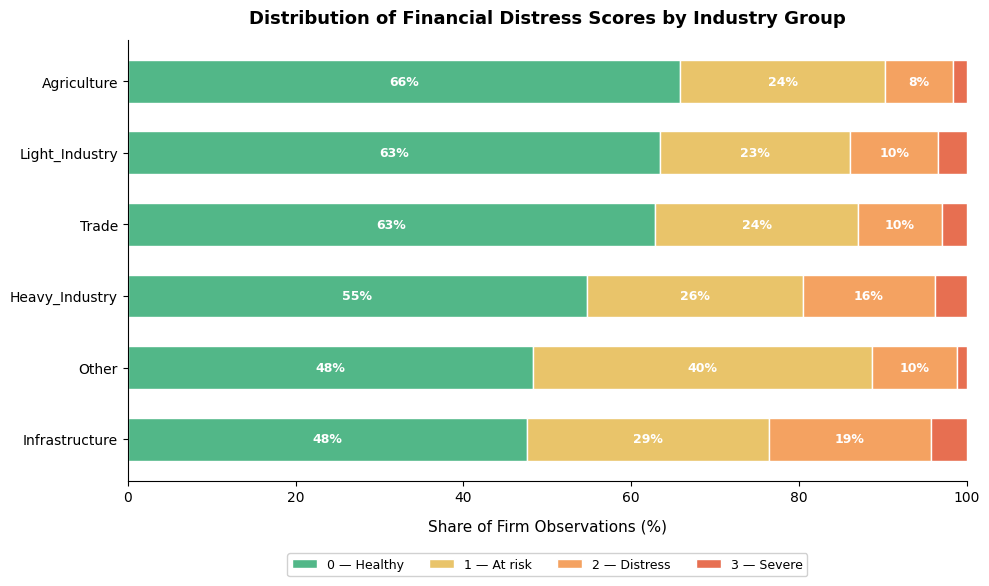

In [165]:
# ═══════════════════════════════════════════════════════════
# CELL · DISTRESS SCORE — BY INDUSTRY
# ═══════════════════════════════════════════════════════════

industry_score = (
    ana.groupby(['Industry_Group', 'Distress_Score'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: x / x.sum() * 100, axis=1)
    .sort_values(0, ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

bottom = np.zeros(len(industry_score))
for i, (score, color) in enumerate(zip([0, 1, 2, 3], score_colors)):
    if score in industry_score.columns:
        vals = industry_score[score].values
        bars = ax.barh(industry_score.index, vals,
                       left=bottom, color=color,
                       edgecolor='white', height=0.6,
                       label=score_labels[i])
        for j, (bar, val) in enumerate(zip(bars, vals)):
            if val > 5:
                ax.text(bottom[j] + val/2,
                        bar.get_y() + bar.get_height()/2,
                        f'{val:.0f}%',
                        ha='center', va='center',
                        fontsize=9, color='white',
                        fontweight='bold')
        bottom += vals

ax.set_xlabel('Share of Firm Observations (%)', fontsize=11, labelpad=10)
ax.set_title('Distribution of Financial Distress Scores by Industry Group',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, 100)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
          fontsize=9, ncol=4, framealpha=0.9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()

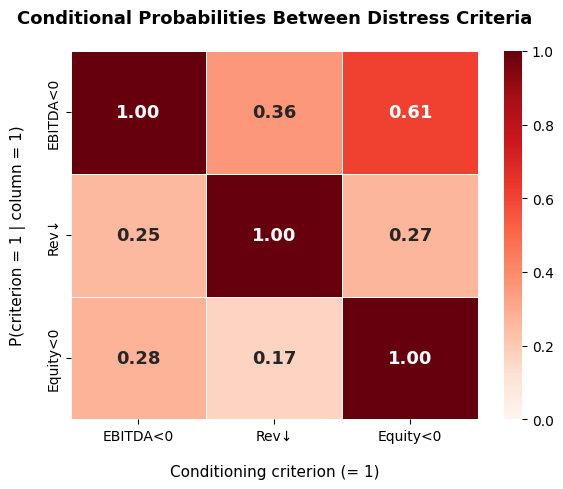

In [166]:
# ═══════════════════════════════════════════════════════════
# CELL · CONDITIONAL PROBABILITY HEATMAP
# ═══════════════════════════════════════════════════════════

import seaborn as sns

crit_cols  = ['Distress_EBITDA', 'Distress_Revenue_Growth', 'Distress_Equity']
crit_names = ['EBITDA<0', 'Rev↓', 'Equity<0']

# P(row=1 | col=1)
cond_prob = np.zeros((3, 3))
for i, col_a in enumerate(crit_cols):
    for j, col_b in enumerate(crit_cols):
        mask = ana[col_b] == 1
        cond_prob[i, j] = (ana.loc[mask, col_a] == 1).mean()

cond_df = pd.DataFrame(cond_prob,
                        index=crit_names,
                        columns=crit_names)

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cond_df,
    annot=True, fmt='.2f',
    cmap='Reds',
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 13, 'weight': 'bold'}
)

ax.set_xlabel('Conditioning criterion (= 1)', fontsize=11, labelpad=15)
ax.set_ylabel('P(criterion = 1 | column = 1)', fontsize=11, labelpad=15)
ax.set_title('Conditional Probabilities Between Distress Criteria',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

In [167]:
# ═══════════════════════════════════════════════════════════
# CELL · TRANSITION MATRIX + BOOTSTRAP CI
# ═══════════════════════════════════════════════════════════

from sklearn.utils import resample

def build_pairs(df):
    """Build consecutive year pairs for transition analysis."""
    df_s = df.sort_values(['Firm ID', 'Year'])
    df_s['Distress_t1'] = df_s.groupby('Firm ID')['Financial_Distress'].shift(-1)
    df_s['Year_next']   = df_s.groupby('Firm ID')['Year'].shift(-1)
    pairs = df_s[
        (df_s['Distress_t1'].notna()) &
        (df_s['Year_next'] - df_s['Year'] == 1)
    ].copy()
    pairs = pairs.rename(columns={'Financial_Distress': 'Distress_t'})
    return pairs[['Firm ID', 'Year', 'Industry_Group',
                  'Distress_t', 'Distress_t1']]

def boot_persistence(df_pairs, n_boot=1000, seed=42):
    np.random.seed(seed)
    rates = []
    for _ in range(n_boot):
        s = resample(df_pairs)
        distressed = s[s['Distress_t'] == 1]
        if len(distressed) > 0:
            rates.append(distressed['Distress_t1'].mean())
    ci = np.percentile(rates, [2.5, 97.5])
    return ci

pairs = build_pairs(ana)

# ── 1. Overall Transition Matrix ──
print("TRANSITION MATRIX — OVERALL")
print("=" * 55)

tm = pd.crosstab(
    pairs['Distress_t'].astype(int),
    pairs['Distress_t1'].astype(int),
    normalize='index'
).round(3)
tm.index   = ['Healthy (t)', 'Distress (t)']
tm.columns = ['→ Healthy (t+1)', '→ Distress (t+1)']
print(tm.to_string())

# Bootstrap CI for persistence
ci_overall = boot_persistence(pairs)
persist_rate = pairs[pairs['Distress_t'] == 1]['Distress_t1'].mean()
print(f"\nPersistence rate : {persist_rate:.3f}")
print(f"95% Bootstrap CI : [{ci_overall[0]:.3f}, {ci_overall[1]:.3f}]")

# ── 2. Persistence by Sub-period ──
print()
print("PERSISTENCE RATE BY SUB-PERIOD")
print("=" * 55)
print(f"{'Sub-period':<20} {'Rate':>8}  {'CI Lower':>10}  {'CI Upper':>10}  {'N distress':>12}")
print("-" * 55)

subperiods = {
    'Pre-COVID (2019)'   : (pairs['Year'] == 2019),
    'COVID-19 (2020)'  : (pairs['Year'] == 2020),
    'Full-scale War (2022)'    : (pairs['Year'] == 2022),
}

for label, mask in subperiods.items():
    sub = pairs[mask]
    distressed = sub[sub['Distress_t'] == 1]
    if len(distressed) > 10:
        rate = distressed['Distress_t1'].mean()
        ci   = boot_persistence(distressed)
        print(f"{label:<20} {rate:>8.3f}  {ci[0]:>10.3f}  {ci[1]:>10.3f}  {len(distressed):>12,}")

# ── 3. Persistence by Industry ──
print()
print("PERSISTENCE RATE BY INDUSTRY")
print("=" * 65)
print(f"{'Industry':<25} {'Rate':>8}  {'CI Lower':>10}  {'CI Upper':>10}  {'N distress':>12}")
print("-" * 65)

industry_results = []
for industry in sorted(pairs['Industry_Group'].unique()):
    sub = pairs[pairs['Industry_Group'] == industry]
    distressed = sub[sub['Distress_t'] == 1]
    if len(distressed) > 10:
        rate = distressed['Distress_t1'].mean()
        ci   = boot_persistence(distressed)
        industry_results.append({
            'Industry'  : industry,
            'Rate'      : rate,
            'CI_lower'  : ci[0],
            'CI_upper'  : ci[1],
            'N_distress': len(distressed)
        })

industry_df = pd.DataFrame(industry_results).sort_values('Rate', ascending=False)
for _, r in industry_df.iterrows():
    print(f"{r['Industry']:<25} {r['Rate']:>8.3f}  "
          f"{r['CI_lower']:>10.3f}  {r['CI_upper']:>10.3f}  "
          f"{int(r['N_distress']):>12,}")

TRANSITION MATRIX — OVERALL
              → Healthy (t+1)  → Distress (t+1)
Healthy (t)             0.913             0.087
Distress (t)            0.440             0.560

Persistence rate : 0.560
95% Bootstrap CI : [0.548, 0.571]

PERSISTENCE RATE BY SUB-PERIOD
Sub-period               Rate    CI Lower    CI Upper    N distress
-------------------------------------------------------
Pre-COVID (2019)        0.629       0.601       0.658         1,130
COVID-19 (2020)         0.537       0.505       0.564         1,187
Full-scale War (2022)    0.503       0.478       0.526         1,645

PERSISTENCE RATE BY INDUSTRY
Industry                      Rate    CI Lower    CI Upper    N distress
-----------------------------------------------------------------
Infrastructure               0.670       0.644       0.696         1,172
Heavy_Industry               0.634       0.606       0.661         1,146
Light_Industry               0.625       0.578       0.669           507
Trade              

In [168]:
# ═══════════════════════════════════════════════════════════
# CELL · SURVIVAL ANALYSIS — DURATION IN DISTRESS
# ═══════════════════════════════════════════════════════════

# ── Step 1: Build distress spells ──
df_s = ana.sort_values(['Firm ID', 'Year']).copy()

df_s['distress_spell'] = (
    df_s.groupby('Firm ID')['Financial_Distress']
    .transform(lambda x: (x != x.shift()).cumsum())
)

spell_len = (
    df_s[df_s['Financial_Distress'] == 1]
    .groupby(['Firm ID', 'distress_spell', 'Industry_Group'])
    .agg(spell_duration=('Year', 'count'))
    .reset_index()
)

# ── Step 2: Overall distribution ──
spell_len['Duration_Group'] = spell_len['spell_duration'].apply(
    lambda x: '1 year' if x == 1 else ('2 years' if x == 2 else '3+ years')
)

overall = (
    spell_len['Duration_Group']
    .value_counts()
    .reindex(['1 year', '2 years', '3+ years'])
    .reset_index()
)
overall.columns = ['Duration', 'N_spells']
overall['Share'] = overall['N_spells'] / overall['N_spells'].sum() * 100

print("DISTRESS EPISODE DURATION — OVERALL")
print("=" * 50)
print(f"  Total episodes : {len(spell_len):,}")
print()
print(f"  {'Duration':<12} {'N episodes':>10}  {'Share':>8}")
print(f"  {'-'*32}")
for _, r in overall.iterrows():
    print(f"  {r['Duration']:<12} {int(r['N_spells']):>10,}  {r['Share']:>7.1f}%")

print()
print(f"  Transient (1 year)  : {overall.loc[0, 'Share']:.1f}%")
print(f"  Moderate  (2 years) : {overall.loc[1, 'Share']:.1f}%")
print(f"  Chronic   (3+ years): {overall.loc[2, 'Share']:.1f}%")

# ── Step 3: By industry ──
print()
print("DISTRESS EPISODE DURATION BY INDUSTRY")
print("=" * 65)

industry_spells = (
    spell_len.groupby(['Industry_Group', 'Duration_Group'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['1 year', '2 years', '3+ years'], fill_value=0)
)
industry_spells_pct = industry_spells.div(industry_spells.sum(axis=1), axis=0) * 100
industry_spells_pct['Chronic_Share'] = industry_spells_pct['3+ years']
industry_spells_pct = industry_spells_pct.sort_values('Chronic_Share', ascending=False)

print(f"  {'Industry':<25} {'1 year':>8}  {'2 years':>8}  {'3+ years':>8}  {'N episodes':>10}")
print(f"  {'-'*60}")
for ind in industry_spells_pct.index:
    n = industry_spells.loc[ind].sum()
    print(f"  {ind:<25} "
          f"{industry_spells_pct.loc[ind, '1 year']:>7.1f}%  "
          f"{industry_spells_pct.loc[ind, '2 years']:>7.1f}%  "
          f"{industry_spells_pct.loc[ind, '3+ years']:>7.1f}%  "
          f"{int(n):>10,}")

DISTRESS EPISODE DURATION — OVERALL
  Total episodes : 5,959

  Duration     N episodes     Share
  --------------------------------
  1 year            3,958     66.4%
  2 years           1,116     18.7%
  3+ years            885     14.9%

  Transient (1 year)  : 66.4%
  Moderate  (2 years) : 18.7%
  Chronic   (3+ years): 14.9%

DISTRESS EPISODE DURATION BY INDUSTRY
  Industry                    1 year   2 years  3+ years  N episodes
  ------------------------------------------------------------
  Infrastructure               57.5%     20.8%     21.7%         908
  Heavy_Industry               58.2%     20.7%     21.1%         866
  Light_Industry               59.2%     23.2%     17.5%         439
  Trade                        62.9%     21.4%     15.8%         843
  Other                        72.2%     17.3%     10.4%       2,147
  Agriculture                  78.2%     12.4%      9.4%         756


### Exploritary Data Description

#### Profitability

ROA — General Overview (df_clean, 2018–2024)

Median ROA by Industry and Year:
Year             2018   2019   2020   2021   2022   2023   2024
Industry_Group                                                 
Agriculture     0.077  0.035  0.011  0.162  0.051  0.025  0.083
Heavy_Industry  0.036  0.029  0.020  0.027  0.005  0.023  0.025
Infrastructure  0.009  0.012  0.003  0.007  0.001  0.005  0.005
Light_Industry  0.024  0.024  0.019  0.018  0.023  0.039  0.034
Other           0.002  0.003  0.002  0.002  0.000  0.004  0.006
Trade           0.032  0.031  0.025  0.036  0.023  0.039  0.045


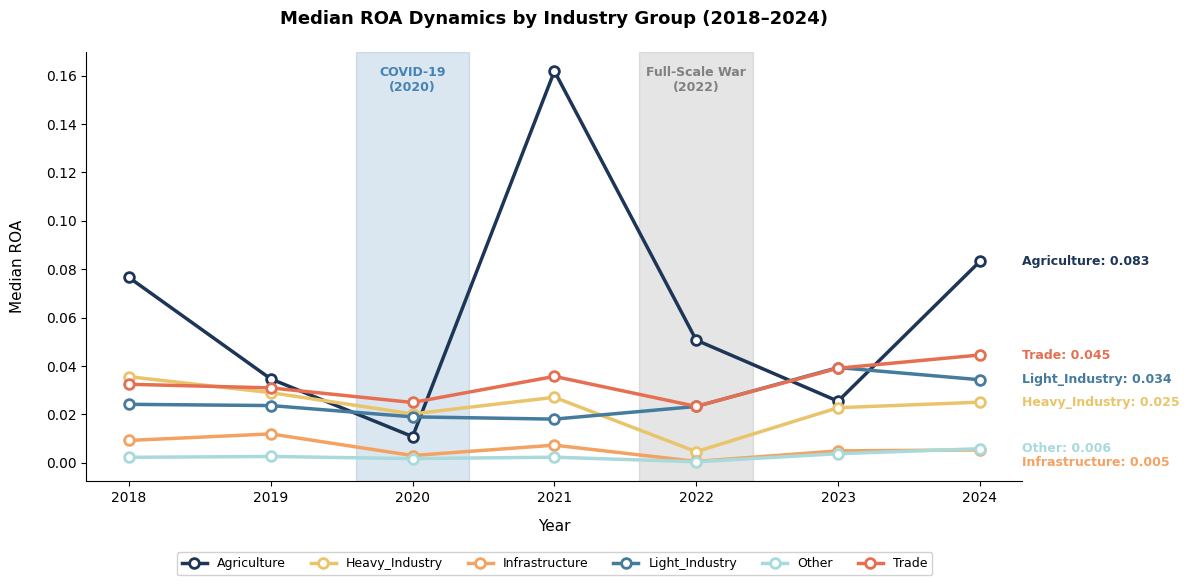

In [169]:
# ═══════════════════════════════════════════════════════════
# CELL · ROA — GENERAL DYNAMICS BY INDUSTRY AND YEAR
# ═══════════════════════════════════════════════════════════

color_map = {
    'Trade'          : '#e76f51',
    'Infrastructure' : '#f4a261',
    'Light_Industry' : '#457b9d',
    'Heavy_Industry' : '#e9c46a',
    'Other'          : '#a8dadc',
    'Agriculture'    : '#1d3557',
}



industries = sorted(df_clean['Industry_Group'].dropna().unique())

print("=" * 55)
print("ROA — General Overview (df_clean, 2018–2024)")
print("=" * 55)
print(f"\nMedian ROA by Industry and Year:")
roa_pivot = (
    df_clean.groupby(['Industry_Group', 'Year'])['ROA']
    .median()
    .unstack('Year')
    .round(3)
)
print(roa_pivot.to_string())

# ── Plot ──
fig, ax = plt.subplots(figsize=(12, 6))

offsets = {
    'Infrastructure' : -0.005,
    'Other'          :  0.00,
}

for industry in industries:
    color  = color_map[industry]
    yearly = (
        df_clean[df_clean['Industry_Group'] == industry]
        .groupby('Year')['ROA']
        .median()
    )
    ax.plot(yearly.index.astype(str), yearly.values,
            color=color, linewidth=2.5, marker='o',
            markersize=7, markerfacecolor='white',
            markeredgecolor=color, markeredgewidth=2,
            label=industry)

    last_y = yearly.values[-1] + offsets.get(industry, 0)
    ax.text(len(yearly) - 0.7, last_y,
            f'{industry}: {yearly.values[-1]:.3f}',
            va='center', ha='left',
            fontsize=9, color=color, fontweight='bold')


y_max = (
    df_clean.groupby(['Industry_Group', 'Year'])['ROA']
    .median().max()
)
y_min = (
    df_clean.groupby(['Industry_Group', 'Year'])['ROA']
    .median().min()
)


y_max = (
    df_clean.groupby(['Industry_Group', 'Year'])['ROA']
    .median().max()
)

# ── Виділення періодів ──
years = list(df_clean['Year'].sort_values().unique())
x_pos = {str(y): i for i, y in enumerate(years)}

ax.axvspan(x_pos['2020'] - 0.4, x_pos['2020'] + 0.4,
           alpha=0.2, color='steelblue')
ax.axvspan(x_pos['2022'] - 0.4, x_pos['2022'] + 0.4,
           alpha=0.2, color='gray')
ax.text(x_pos['2020'], y_max * 0.95, 'COVID-19\n(2020)',
        ha='center', fontsize=9, color='steelblue', fontweight='bold')
ax.text(x_pos['2022'], y_max * 0.95, 'Full-Scale War\n(2022)',
        ha='center', fontsize=9, color='gray', fontweight='bold')

ax.set_title('Median ROA Dynamics by Industry Group (2018–2024)',
             fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=11, labelpad=10)
ax.set_ylabel('Median ROA', fontsize=11, labelpad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
                fontsize=9, ncol=6, framealpha=0.9)
ax.tick_params(axis='y', labelsize=10)
ax.grid(False)

plt.tight_layout()
plt.show()

PROFITABILITY — Distress vs Non-Distress

ROA:
  Median Non-Distress :   0.0253
  Median Distress     :  -0.1009
  Difference          :   0.1263
  Mann-Whitney p      : 0.0000  ✓ significant
  Effect size (r)     : 0.7654  large

EBIT/Assets:
  Median Non-Distress :   0.0332
  Median Distress     :  -0.1020
  Difference          :   0.1353
  Mann-Whitney p      : 0.0000  ✓ significant
  Effect size (r)     : 0.7837  large

Gross Margin:
  Median Non-Distress :   0.2000
  Median Distress     :   0.1011
  Difference          :   0.0989
  Mann-Whitney p      : 0.0000  ✓ significant
  Effect size (r)     : 0.2244  small

RANKING by Effect Size:
      Metric  Median Non-D  Median Distress  Difference  Effect size
 EBIT/Assets        0.0332          -0.1020      0.1353       0.7837
         ROA        0.0253          -0.1009      0.1263       0.7654
Gross Margin        0.2000           0.1011      0.0989       0.2244

→ Best predictor: EBIT/Assets


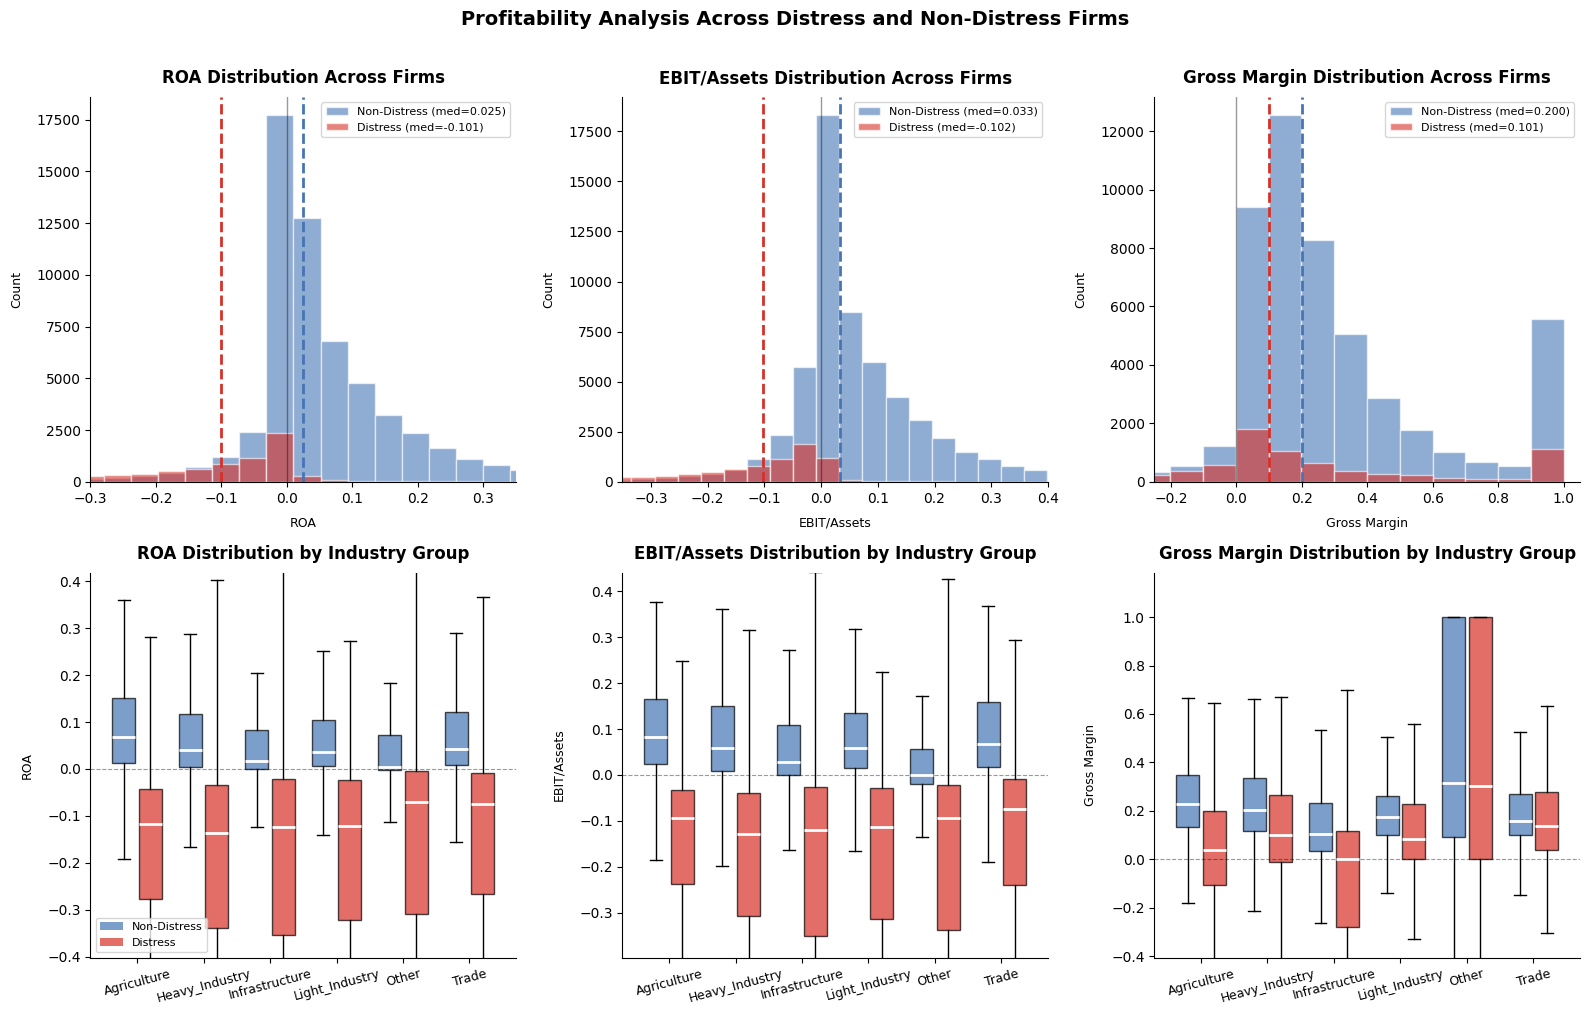

In [170]:
# ═══════════════════════════════════════════════════════════
# CELL · PROFITABILITY — DISTRESS vs NON-DISTRESS
# ═══════════════════════════════════════════════════════════

from scipy import stats
from matplotlib.patches import Patch

metrics = {
    'ROA'         : 'ROA',
    'EBIT/Assets' : 'EBIT_Assets',
    'Gross Margin': 'Gross_Margin',
}

xlim_map = {
    'ROA'         : (-0.30, 0.35),
    'EBIT/Assets' : (-0.35, 0.40),
    'Gross Margin': (-0.25, 1.05),
}

# ── Statistics ──
print("=" * 65)
print("PROFITABILITY — Distress vs Non-Distress")
print("=" * 65)

results = []
for name, col in metrics.items():
    d0 = ana[ana['Financial_Distress'] == 0][col].dropna()
    d1 = ana[ana['Financial_Distress'] == 1][col].dropna()

    stat, p_val = stats.mannwhitneyu(d0, d1, alternative='two-sided')
    n1, n2      = len(d0), len(d1)
    effect      = 1 - (2 * stat) / (n1 * n2)

    results.append({
        'Metric'          : name,
        'Median Non-D'    : d0.median(),
        'Median Distress' : d1.median(),
        'Difference'      : d0.median() - d1.median(),
        'p-value'         : p_val,
        'Effect size'     : abs(effect),
    })

    print(f"\n{name}:")
    print(f"  Median Non-Distress : {d0.median():>8.4f}")
    print(f"  Median Distress     : {d1.median():>8.4f}")
    print(f"  Difference          : {d0.median() - d1.median():>8.4f}")
    print(f"  Mann-Whitney p      : {p_val:.4f}  "
          f"{'✓ significant' if p_val < 0.05 else '✗ not significant'}")
    print(f"  Effect size (r)     : {abs(effect):.4f}  "
          f"{'large' if abs(effect) > 0.5 else 'medium' if abs(effect) > 0.3 else 'small'}")

results_df = pd.DataFrame(results).sort_values('Effect size', ascending=False)

print(f"\n{'='*65}")
print("RANKING by Effect Size:")
print(results_df[['Metric', 'Median Non-D', 'Median Distress',
                   'Difference', 'Effect size']].round(4).to_string(index=False))
print(f"\n→ Best predictor: {results_df.iloc[0]['Metric']}")

# ── Plots ──
colors_group = {0: '#4575b4', 1: '#d73027'}
labels_group = {0: 'Non-Distress', 1: 'Distress'}
industries   = sorted(ana['Industry_Group'].dropna().unique())

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col_idx, (name, col) in enumerate(metrics.items()):

    # ── Top row: distributions ──
    ax_hist = axes[0, col_idx]

    for group in [0, 1]:
        data = ana[ana['Financial_Distress'] == group][col].dropna()
        ax_hist.hist(data, bins=60,
                     color=colors_group[group], alpha=0.6,
                     edgecolor='white',
                     label=f"{labels_group[group]} (med={data.median():.3f})")
        ax_hist.axvline(data.median(),
                        color=colors_group[group],
                        linewidth=2, linestyle='--')

    ax_hist.axvline(0, color='black', linewidth=1.0,
                    linestyle='-', alpha=0.4)
    ax_hist.set_xlim(*xlim_map[name])
    ax_hist.set_title(f'{name} Distribution Across Firms',
                      fontsize=12, fontweight='bold', pad=10)
    ax_hist.set_xlabel(name, fontsize=9, labelpad=8)
    ax_hist.set_ylabel('Count', fontsize=9, labelpad=10)
    ax_hist.legend(fontsize=8, framealpha=0.8)
    ax_hist.spines[['top', 'right']].set_visible(False)
    ax_hist.grid(False)

    # ── Bottom row: boxplot by industry ──
    ax_box = axes[1, col_idx]

    positions_0 = np.arange(len(industries)) - 0.2
    positions_1 = np.arange(len(industries)) + 0.2

    data_0 = [ana[(ana['Industry_Group'] == ind) &
                   (ana['Financial_Distress'] == 0)][col].dropna()
               for ind in industries]
    data_1 = [ana[(ana['Industry_Group'] == ind) &
                   (ana['Financial_Distress'] == 1)][col].dropna()
               for ind in industries]

    bp0 = ax_box.boxplot(data_0, positions=positions_0, widths=0.35,
                         patch_artist=True, showfliers=False,
                         medianprops=dict(color='white', linewidth=2))
    bp1 = ax_box.boxplot(data_1, positions=positions_1, widths=0.35,
                         patch_artist=True, showfliers=False,
                         medianprops=dict(color='white', linewidth=2))

    for patch in bp0['boxes']:
        patch.set_facecolor(colors_group[0])
        patch.set_alpha(0.7)
    for patch in bp1['boxes']:
        patch.set_facecolor(colors_group[1])
        patch.set_alpha(0.7)

    # Y-axis scale P5–P95
    all_data = ana[col].dropna()
    p5       = all_data.quantile(0.05)
    p95      = all_data.quantile(0.95)
    margin   = (p95 - p5) * 0.15
    ax_box.set_ylim(p5 - margin, p95 + margin)

    ax_box.axhline(y=0, color='black', linewidth=0.8,
                   linestyle='--', alpha=0.4)
    ax_box.set_xticks(np.arange(len(industries)))
    ax_box.set_xticklabels(industries, rotation=15, fontsize=9)
    ax_box.set_title(f'{name} Distribution by Industry Group',
                     fontsize=12, fontweight='bold', pad=10)
    ax_box.set_ylabel(name, fontsize=9, labelpad=10)
    ax_box.spines[['top', 'right']].set_visible(False)
    ax_box.grid(False)

    if col_idx == 0:
        legend_elements = [
            Patch(facecolor=colors_group[0], alpha=0.7, label='Non-Distress'),
            Patch(facecolor=colors_group[1], alpha=0.7, label='Distress')
        ]
        ax_box.legend(handles=legend_elements, fontsize=8,
                      loc='lower left')

fig.suptitle('Profitability Analysis Across Distress and Non-Distress Firms',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### Liquidity

CURRENT RATIO — Industry Norms (df_clean, 2018–2024)

Median Current Ratio by Industry and Year:
Year             2018   2019   2020   2021   2022   2023   2024
Industry_Group                                                 
Agriculture     3.064  2.577  1.134  3.137  2.940  3.096  3.628
Heavy_Industry  1.361  1.279  1.283  1.235  1.250  1.279  1.316
Infrastructure  1.029  1.013  1.006  1.001  1.016  1.026  1.029
Light_Industry  1.320  1.261  1.298  1.288  1.361  1.496  1.511
Other           1.770  1.726  1.852  2.065  2.250  2.327  2.421
Trade           1.215  1.212  1.202  1.235  1.274  1.341  1.364


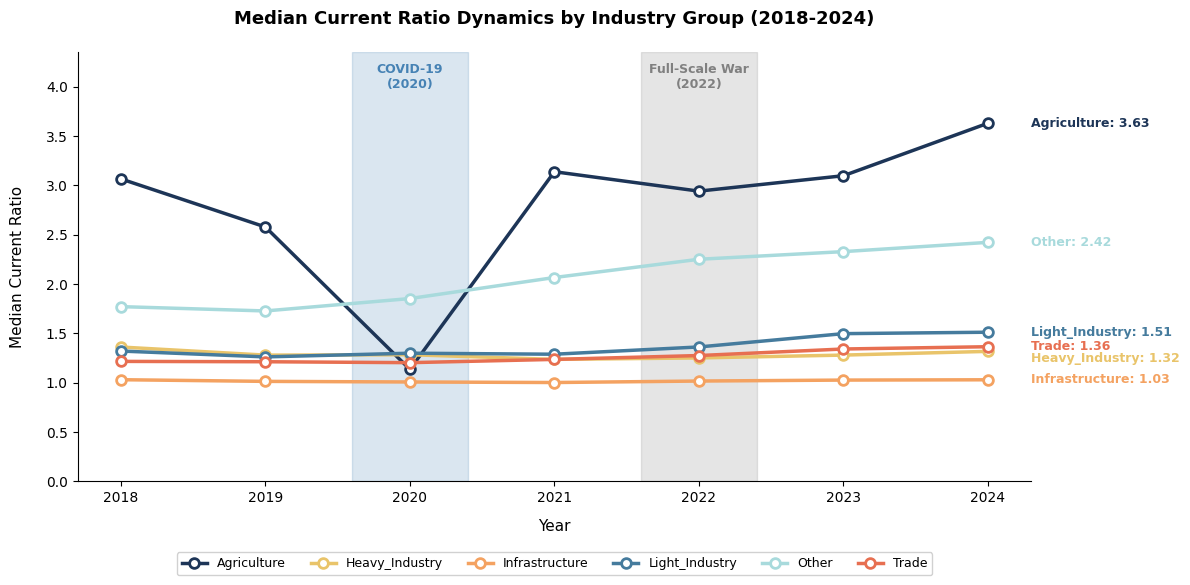

In [171]:
# ═══════════════════════════════════════════════════════════
# CELL · LIQUIDITY — INDUSTRY NORMS BY YEAR
# ═══════════════════════════════════════════════════════════

color_map = {
    'Trade'          : '#e76f51',
    'Infrastructure' : '#f4a261',
    'Light_Industry' : '#457b9d',
    'Heavy_Industry' : '#e9c46a',
    'Other'          : '#a8dadc',
    'Agriculture'    : '#1d3557',
}

industries = sorted(df_clean['Industry_Group'].dropna().unique())

print("=" * 60)
print("CURRENT RATIO — Industry Norms (df_clean, 2018–2024)")
print("=" * 60)


industry_stats = (
    df_clean.groupby('Industry_Group')['Current_Ratio']
    .agg(
        N       = 'count',
        Mean    = 'mean',
        Median  = 'median',
        P25     = lambda x: x.quantile(0.25),
        P75     = lambda x: x.quantile(0.75),
        Below_1 = lambda x: (x < 1).mean() * 100
    )
    .round(3)
    .sort_values('Median', ascending=False)
)
industry_stats['Below_1'] = industry_stats['Below_1'].round(1)


print("\nMedian Current Ratio by Industry and Year:")
qr_pivot = (
    df_clean.groupby(['Industry_Group', 'Year'])['Current_Ratio']
    .median()
    .unstack('Year')
    .round(3)
)
print(qr_pivot.to_string())

# ── Plot ──
fig, ax = plt.subplots(figsize=(12, 6))

offsets = {
    'Other'          :  0.00,
    'Agriculture'    :  0.00,
    'Trade'          :  0.0,
    'Light_Industry' :  0.0,
    'Infrastructure' :  0.0,
    'Heavy_Industry' : -0.07,
}

for industry in industries:
    color  = color_map[industry]
    yearly = (
        df_clean[df_clean['Industry_Group'] == industry]
        .groupby('Year')['Current_Ratio']
        .median()
    )
    ax.plot(yearly.index.astype(str), yearly.values,
            color=color, linewidth=2.5, marker='o',
            markersize=7, markerfacecolor='white',
            markeredgecolor=color, markeredgewidth=2,
            label=industry)

    last_y = yearly.values[-1] + offsets.get(industry, 0)
    ax.text(len(yearly) - 0.7, last_y,
            f'{industry}: {yearly.values[-1]:.2f}',
            va='center', ha='left',
            fontsize=9, color=color, fontweight='bold')

y_max = (
    df_clean.groupby(['Industry_Group', 'Year'])['Current_Ratio']
    .median().max()
)
y_min = (
    df_clean.groupby(['Industry_Group', 'Year'])['Current_Ratio']
    .median().min()
)



# ── Виділення періодів ──
years = list(df_clean['Year'].sort_values().unique())
x_pos = {str(y): i for i, y in enumerate(years)}

ax.axvspan(x_pos['2020'] - 0.4, x_pos['2020'] + 0.4,
           alpha=0.2, color='steelblue')
ax.axvspan(x_pos['2022'] - 0.4, x_pos['2022'] + 0.4,
           alpha=0.2, color='gray')

ax.text(x_pos['2020'], y_max * 1.1, 'COVID-19\n(2020)',
        ha='center', fontsize=9, color='steelblue', fontweight='bold')
ax.text(x_pos['2022'], y_max * 1.1, 'Full-Scale War\n(2022)',
        ha='center', fontsize=9, color='gray', fontweight='bold')

ax.set_ylim(0, y_max * 1.2)
ax.set_title('Median Current Ratio Dynamics by Industry Group (2018-2024)',
             fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=11, labelpad=10)
ax.set_ylabel('Median Current Ratio', fontsize=11, labelpad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=10)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
                fontsize=9, ncol=6, framealpha=0.9)
ax.grid(False)

plt.tight_layout()
plt.show()

LIQUIDITY — Distress vs Non-Distress

Current Ratio:
  Median Non-Distress :   1.7860
  Median Distress     :   0.6389
  Difference          :   1.1471
  Mann-Whitney p      : 0.0000  ✓ significant
  Effect size (r)     : 0.5274  large

Quick Ratio:
  Median Non-Distress :   1.1423
  Median Distress     :   0.4047
  Difference          :   0.7376
  Mann-Whitney p      : 0.0000  ✓ significant
  Effect size (r)     : 0.4394  medium

WC/Assets:
  Median Non-Distress :   0.2419
  Median Distress     :  -0.3271
  Difference          :   0.5690
  Mann-Whitney p      : 0.0000  ✓ significant
  Effect size (r)     : 0.5556  large

RANKING by Effect Size:
       Metric  Median Non-D  Median Distress  Difference  Effect size
    WC/Assets        0.2419          -0.3271      0.5690       0.5556
Current Ratio        1.7860           0.6389      1.1471       0.5274
  Quick Ratio        1.1423           0.4047      0.7376       0.4394

→ Best predictor: WC/Assets


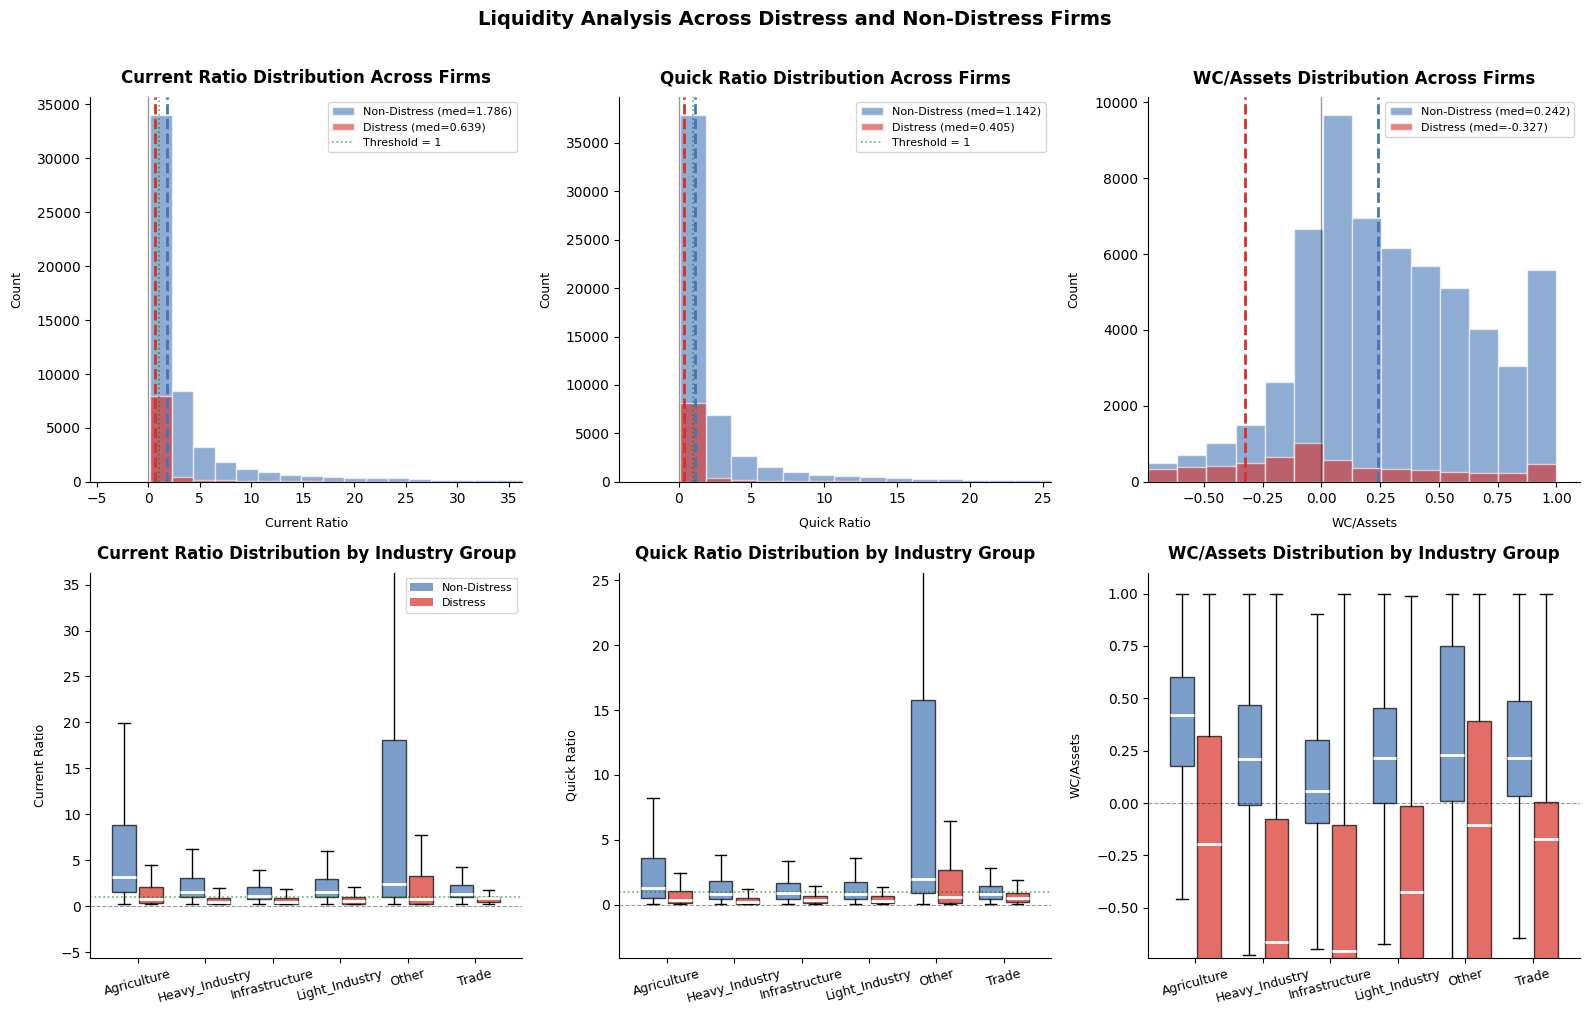

In [172]:
# ═══════════════════════════════════════════════════════════
# CELL · LIQUIDITY — DISTRESS vs NON-DISTRESS
# ═══════════════════════════════════════════════════════════

from scipy import stats
from matplotlib.patches import Patch

metrics = {
    'Current Ratio': 'Current_Ratio',
    'Quick Ratio'  : 'Quick_Ratio',
    'WC/Assets'    : 'WC_Assets',
}

# ── Statistics ──
print("=" * 65)
print("LIQUIDITY — Distress vs Non-Distress")
print("=" * 65)

results = []
for name, col in metrics.items():
    d0 = ana[ana['Financial_Distress'] == 0][col].dropna()
    d1 = ana[ana['Financial_Distress'] == 1][col].dropna()

    stat, p_val = stats.mannwhitneyu(d0, d1, alternative='two-sided')
    n1, n2      = len(d0), len(d1)
    effect      = 1 - (2 * stat) / (n1 * n2)

    results.append({
        'Metric'          : name,
        'Median Non-D'    : d0.median(),
        'Median Distress' : d1.median(),
        'Difference'      : d0.median() - d1.median(),
        'p-value'         : p_val,
        'Effect size'     : abs(effect),
    })

    print(f"\n{name}:")
    print(f"  Median Non-Distress : {d0.median():>8.4f}")
    print(f"  Median Distress     : {d1.median():>8.4f}")
    print(f"  Difference          : {d0.median() - d1.median():>8.4f}")
    print(f"  Mann-Whitney p      : {p_val:.4f}  "
          f"{'✓ significant' if p_val < 0.05 else '✗ not significant'}")
    print(f"  Effect size (r)     : {abs(effect):.4f}  "
          f"{'large' if abs(effect) > 0.5 else 'medium' if abs(effect) > 0.3 else 'small'}")

results_df = pd.DataFrame(results).sort_values('Effect size', ascending=False)

print(f"\n{'='*65}")
print("RANKING by Effect Size:")
print(results_df[['Metric', 'Median Non-D', 'Median Distress',
                   'Difference', 'Effect size']].round(4).to_string(index=False))
print(f"\n→ Best predictor: {results_df.iloc[0]['Metric']}")

# ── Plots ──
colors_group = {0: '#4575b4', 1: '#d73027'}
labels_group = {0: 'Non-Distress', 1: 'Distress'}
industries   = sorted(ana['Industry_Group'].dropna().unique())

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col_idx, (name, col) in enumerate(metrics.items()):

    # ── Top row: distributions ──
    ax_hist = axes[0, col_idx]

    # Auto xlim P10/P90
    all_data_hist = ana[col].dropna()
    p10_h    = all_data_hist.quantile(0.10)
    p90_h    = all_data_hist.quantile(0.90)
    margin_h = (p90_h - p10_h) * 0.2

    for group in [0, 1]:
        data = ana[ana['Financial_Distress'] == group][col].dropna()
        ax_hist.hist(data, bins=60,
                     color=colors_group[group], alpha=0.6,
                     edgecolor='white',
                     label=f"{labels_group[group]} (med={data.median():.3f})")
        ax_hist.axvline(data.median(),
                        color=colors_group[group],
                        linewidth=2, linestyle='--')

    ax_hist.axvline(0, color='black', linewidth=1.0,
                    linestyle='-', alpha=0.4)

    if name in ['Current Ratio', 'Quick Ratio']:
        ax_hist.axvline(1, color='green', linewidth=1.2,
                        linestyle=':', alpha=0.6, label='Threshold = 1')

    ax_hist.set_xlim(p10_h - margin_h, p90_h + margin_h)
    ax_hist.set_title(f'{name} Distribution Across Firms',
                      fontsize=12, fontweight='bold', pad=10)
    ax_hist.set_xlabel(name, fontsize=9, labelpad=8)
    ax_hist.set_ylabel('Count', fontsize=9, labelpad=10)
    ax_hist.legend(fontsize=8, framealpha=0.8)
    ax_hist.spines[['top', 'right']].set_visible(False)
    ax_hist.grid(False)

    # ── Bottom row: boxplot by industry ──
    ax_box = axes[1, col_idx]

    positions_0 = np.arange(len(industries)) - 0.2
    positions_1 = np.arange(len(industries)) + 0.2

    data_0 = [ana[(ana['Industry_Group'] == ind) &
                   (ana['Financial_Distress'] == 0)][col].dropna()
               for ind in industries]
    data_1 = [ana[(ana['Industry_Group'] == ind) &
                   (ana['Financial_Distress'] == 1)][col].dropna()
               for ind in industries]

    bp0 = ax_box.boxplot(data_0, positions=positions_0, widths=0.35,
                         patch_artist=True, showfliers=False,
                         medianprops=dict(color='white', linewidth=2))
    bp1 = ax_box.boxplot(data_1, positions=positions_1, widths=0.35,
                         patch_artist=True, showfliers=False,
                         medianprops=dict(color='white', linewidth=2))

    for patch in bp0['boxes']:
        patch.set_facecolor(colors_group[0])
        patch.set_alpha(0.7)
    for patch in bp1['boxes']:
        patch.set_facecolor(colors_group[1])
        patch.set_alpha(0.7)

    # Y-axis scale P10/P90
    all_data = ana[col].dropna()
    p10      = all_data.quantile(0.10)
    p90      = all_data.quantile(0.90)
    margin   = (p90 - p10) * 0.2
    ax_box.set_ylim(p10 - margin, p90 + margin)

    ax_box.axhline(y=0, color='black', linewidth=0.8,
                   linestyle='--', alpha=0.4)

    if name in ['Current Ratio', 'Quick Ratio']:
        ax_box.axhline(y=1, color='green', linewidth=1.2,
                       linestyle=':', alpha=0.6, label='Threshold = 1')
        # ax_box.legend(fontsize=8)

    ax_box.set_xticks(np.arange(len(industries)))
    ax_box.set_xticklabels(industries, rotation=15, fontsize=9)
    ax_box.set_title(f'{name} Distribution by Industry Group',
                     fontsize=12, fontweight='bold', pad=10)
    ax_box.set_ylabel(name, fontsize=9, labelpad=10)
    ax_box.spines[['top', 'right']].set_visible(False)
    ax_box.grid(False)

    if col_idx == 0:
        legend_elements = [
            Patch(facecolor=colors_group[0], alpha=0.7, label='Non-Distress'),
            Patch(facecolor=colors_group[1], alpha=0.7, label='Distress')
        ]
        ax_box.legend(handles=legend_elements, fontsize=8)

fig.suptitle('Liquidity Analysis Across Distress and Non-Distress Firms',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

##### Leverage & Debt Structure

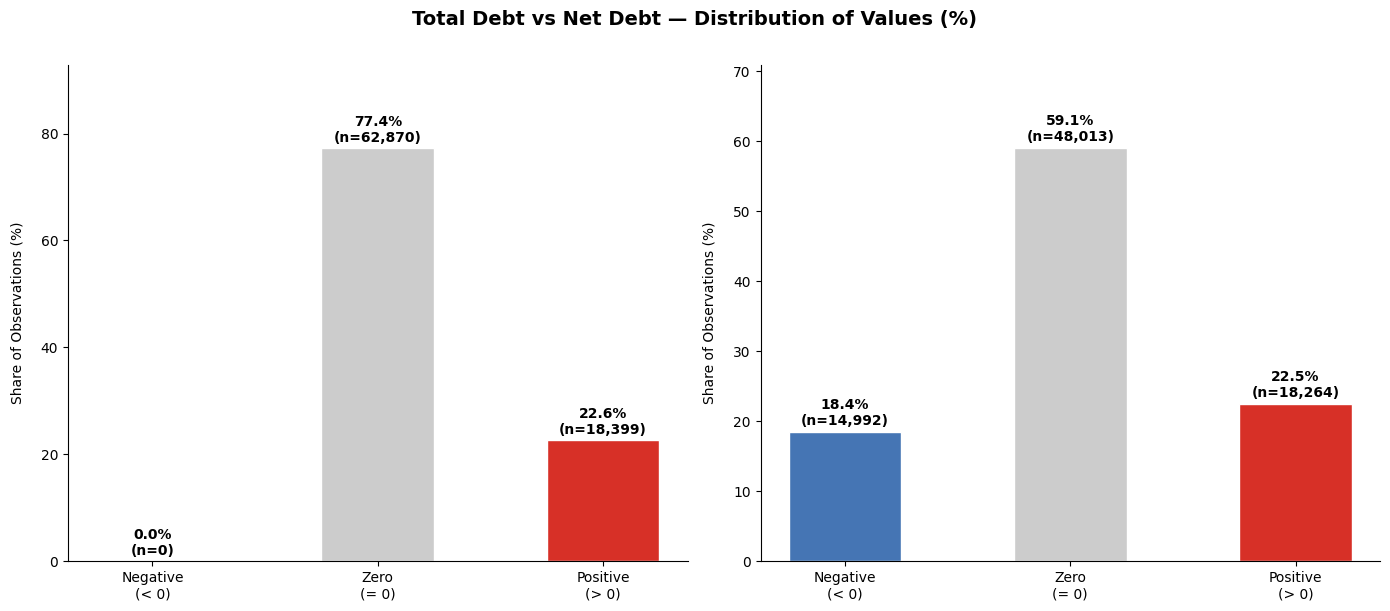

In [173]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_bar = ['#4575b4', '#cccccc', '#d73027']
labels_bar = ['Negative\n(< 0)', 'Zero\n(= 0)', 'Positive\n(> 0)']

for ax, col in zip(axes, ['Total Debt', 'Net Debt']):
    data = df_clean[col].dropna()
    total = len(data)

    negative = (data < 0).sum()
    zero     = (data == 0).sum()
    positive = (data > 0).sum()

    bars = ax.bar(
        labels_bar,
        [negative/total*100, zero/total*100, positive/total*100],
        color=colors_bar, edgecolor='white', width=0.5
    )

    for bar, val, n in zip(bars,
                           [negative/total*100, zero/total*100, positive/total*100],
                           [negative, zero, positive]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%\n(n={n:,})',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_ylabel('Share of Observations (%)', fontsize=10, labelpad=12)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(False)
    ax.set_ylim(0, max(negative, zero, positive)/total*100 * 1.2)

fig.suptitle('Total Debt vs Net Debt — Distribution of Values (%)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

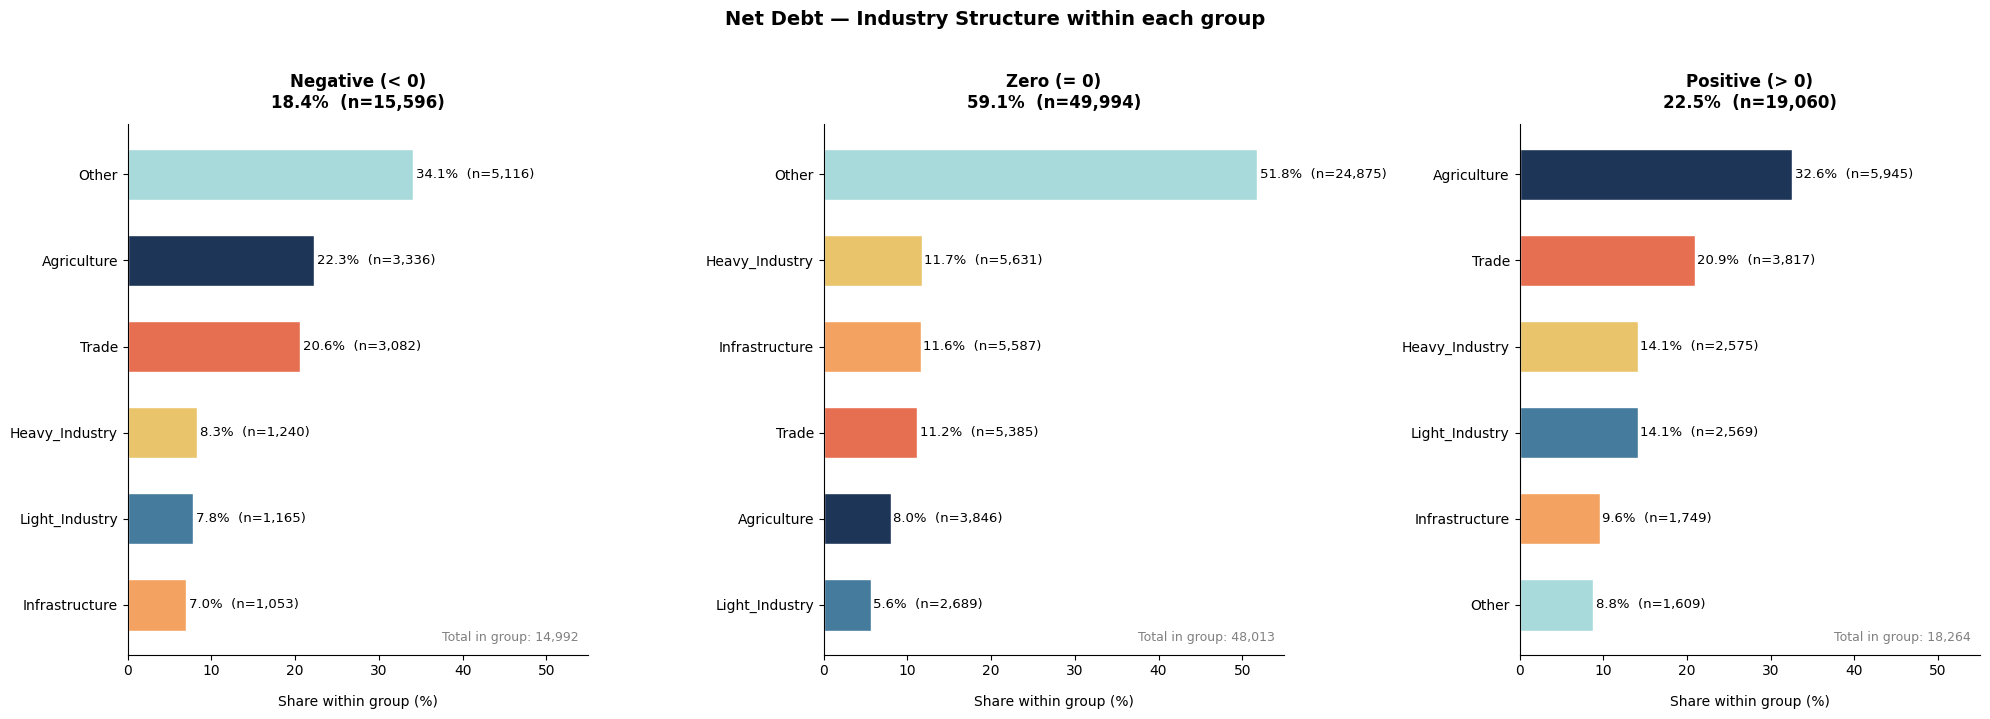

In [174]:
color_map = {
    'Trade'          : '#e76f51',
    'Infrastructure' : '#f4a261',
    'Light_Industry' : '#457b9d',
    'Heavy_Industry' : '#e9c46a',
    'Other'          : '#a8dadc',
    'Agriculture'    : '#1d3557',
}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

total_all = len(df_clean)
groups = {
    f'Negative (< 0)\n18.4%  (n=15,596)' : df_clean[df_clean['Net Debt'] < 0],
    f'Zero (= 0)\n59.1%  (n=49,994)'      : df_clean[df_clean['Net Debt'] == 0],
    f'Positive (> 0)\n22.5%  (n=19,060)'  : df_clean[df_clean['Net Debt'] > 0],
}

for ax, (title, subset) in zip(axes, groups.items()):
    industry_share = (
        subset.groupby('Industry_Group')['Firm ID']
        .count()
        .sort_values(ascending=True)
    )
    total_group  = len(subset)
    industry_pct = (industry_share / total_group * 100).round(1)

    bar_colors = [color_map[ind] for ind in industry_pct.index]

    bars = ax.barh(
        industry_pct.index,
        industry_pct.values,
        color=bar_colors,
        edgecolor='white', height=0.6
    )

    for bar, val, n in zip(bars, industry_pct.values, industry_share.values):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%  (n={n:,})',
                va='center', ha='left', fontsize=9.5)

    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel('Share within group (%)', fontsize=10, labelpad=12)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(False)
    ax.set_xlim(0, 55)
    ax.text(0.98, 0.02, f'Total in group: {total_group:,}',
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=9, color='gray')

fig.suptitle('Net Debt — Industry Structure within each group',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

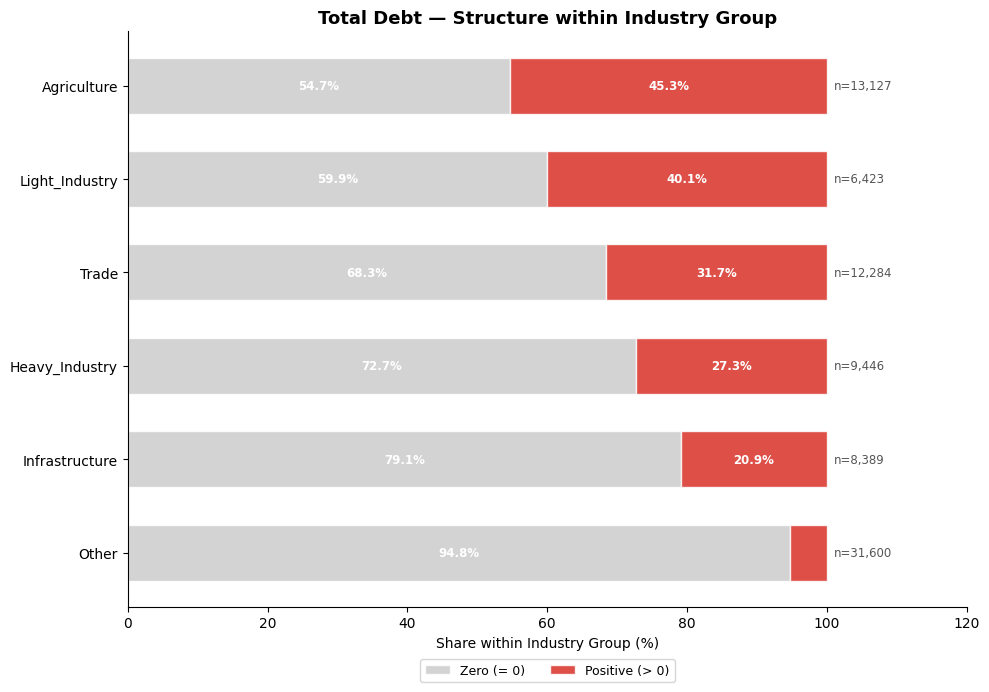

In [175]:
fig, ax2 = plt.subplots(1, 1, figsize=(10, 7))

col = 'Total Debt'
labels = ['Zero (= 0)', 'Positive (> 0)']
colors = ['#cccccc', '#d73027']

industry_pct = df_clean.groupby('Industry_Group').apply(lambda x: pd.Series({
    labels[0]: (x[col] == 0).sum() / len(x) * 100,
    labels[1]: (x[col] > 0).sum() / len(x) * 100,
    'N': len(x)
})).sort_values(labels[1], ascending=True)

y_pos = np.arange(len(industry_pct))
left = np.zeros(len(industry_pct))

for category, color in zip(labels, colors):
    vals = industry_pct[category].values
    bars = ax2.barh(y_pos, vals, left=left, color=color,
                   edgecolor='white', alpha=0.85,
                   label=category, height=0.6)
    for i, (bar, val) in enumerate(zip(bars, vals)):
        if val > 8:
            ax2.text(left[i] + val/2, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', ha='center',
                    fontsize=8.5, color='white', fontweight='bold')
    left += vals

for i, (idx, row_data) in enumerate(industry_pct.iterrows()):
    ax2.text(101, y_pos[i], f'n={int(row_data["N"]):,}',
            va='center', ha='left', fontsize=8.5, color='#555555')

ax2.set_yticks(y_pos)
ax2.set_yticklabels(industry_pct.index, fontsize=10)
ax2.set_title(f'{col} — Structure within Industry Group',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Share within Industry Group (%)', fontsize=10)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(False)
ax2.legend(fontsize=9, loc='upper center', bbox_to_anchor=(0.5, -0.08),
           ncol=3, frameon=True)
ax2.set_xlim(0, 120)

plt.tight_layout()
plt.show()

In [176]:
df_debt = df_clean[df_clean['Total Debt'] > 0].copy()
debt_structure = (
    df_debt.groupby(['Industry_Group', 'Year'])
    .agg(
        Total_Debt = ('Total Debt',            'sum'),
        ST_Bank    = ('Short-Term Bank Loans', 'sum'),
        LT_Bank    = ('Long-Term Bank Loans',  'sum'),
    )
    .reset_index()
)

debt_structure['ST_Share'] = debt_structure['ST_Bank'] / debt_structure['Total_Debt'] * 100
debt_structure['LT_Share'] = debt_structure['LT_Bank'] / debt_structure['Total_Debt'] * 100

# ── Таблиця ──
pivot_st = (
    debt_structure.pivot(index='Industry_Group', columns='Year', values='ST_Share')
    .round(1)
)
pivot_lt = (
    debt_structure.pivot(index='Industry_Group', columns='Year', values='LT_Share')
    .round(1)
)

print("=" * 70)
print("ST Bank Loans as % of Total Debt")
print("=" * 70)
print(pivot_st.to_string())

print()
print("=" * 70)
print("LT Bank Loans as % of Total Debt")
print("=" * 70)
print(pivot_lt.to_string())

ST Bank Loans as % of Total Debt
Year            2018  2019  2020  2021  2022  2023  2024
Industry_Group                                          
Agriculture     57.9  64.9  73.0  65.1  73.4  66.9  55.3
Heavy_Industry  57.5  58.4  65.0  65.6  62.6  65.1  60.1
Infrastructure  30.8  44.8  28.1  38.2  38.2  23.6  57.3
Light_Industry  45.3  50.0  60.3  75.5  78.1  65.0  67.7
Other           45.3  33.4  24.7  34.5  42.8  25.0  27.5
Trade           63.8  64.4  63.2  70.8  71.1  70.4  69.0

LT Bank Loans as % of Total Debt
Year            2018  2019  2020  2021  2022  2023  2024
Industry_Group                                          
Agriculture     42.1  35.1  27.0  34.9  26.6  33.1  44.7
Heavy_Industry  42.5  41.6  35.0  34.4  37.4  34.9  39.9
Infrastructure  69.2  55.2  71.9  61.8  61.8  76.4  42.7
Light_Industry  54.7  50.0  39.7  24.5  21.9  35.0  32.3
Other           54.7  66.6  75.3  65.5  57.2  75.0  72.5
Trade           36.2  35.6  36.8  29.2  28.9  29.6  31.0


In [177]:
median_structure = (
    debt_structure.groupby('Industry_Group')
    .agg(
        ST_Median=('ST_Share', 'median'),
        LT_Median=('LT_Share', 'median'),
    )
    .reset_index()
    .sort_values('ST_Median', ascending=True)
)

print("=" * 55)
print("MEDIAN DEBT STRUCTURE BY INDUSTRY (2018–2024)")
print("=" * 55)
print(f"{'Industry':<25} {'ST Median (%)':>15}  {'LT Median (%)':>15}")
print("-" * 55)
for _, r in median_structure.iterrows():
    print(f"{r['Industry_Group']:<25} {r['ST_Median']:>14.1f}%  {r['LT_Median']:>14.1f}%")

MEDIAN DEBT STRUCTURE BY INDUSTRY (2018–2024)
Industry                    ST Median (%)    LT Median (%)
-------------------------------------------------------
Other                               33.4%            66.6%
Infrastructure                      38.2%            61.8%
Heavy_Industry                      62.6%            37.4%
Light_Industry                      65.0%            35.0%
Agriculture                         65.1%            34.9%
Trade                               69.0%            31.0%


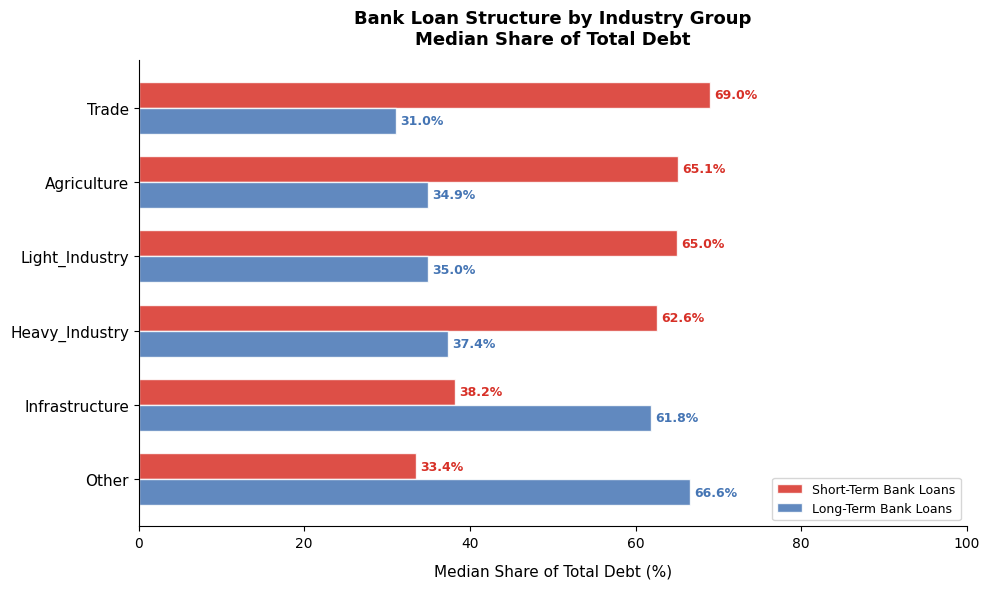

In [178]:
industries_sorted = median_structure['Industry_Group'].tolist()
x     = np.arange(len(industries_sorted))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars_st = ax.barh(x + width/2, median_structure['ST_Median'], width,
                  color='#d73027', edgecolor='white', label='Short-Term Bank Loans', alpha=0.85)
bars_lt = ax.barh(x - width/2, median_structure['LT_Median'], width,
                  color='#4575b4', edgecolor='white', label='Long-Term Bank Loans', alpha=0.85)

for bar, val in zip(bars_st, median_structure['ST_Median']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', ha='left',
            fontsize=9, color='#d73027', fontweight='bold')

for bar, val in zip(bars_lt, median_structure['LT_Median']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', ha='left',
            fontsize=9, color='#4575b4', fontweight='bold')

ax.set_yticks(x)
ax.set_yticklabels(industries_sorted, fontsize=11)
ax.set_xlabel('Median Share of Total Debt (%)', fontsize=11, labelpad=10)
ax.set_title('Bank Loan Structure by Industry Group\nMedian Share of Total Debt',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, 100)
ax.legend(fontsize=9, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.show()

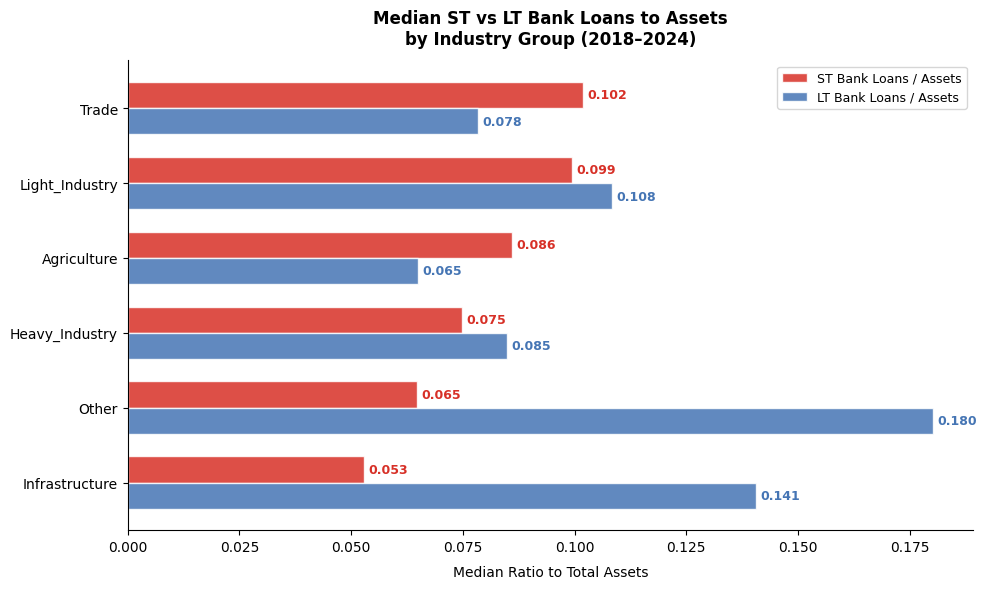

In [179]:
df_debt['ST_Bank_Assets'] = df_debt['Short-Term Bank Loans'] / df_debt['Total Assets']
df_debt['LT_Bank_Assets'] = df_debt['Long-Term Bank Loans']  / df_debt['Total Assets']

median_assets = (
    df_debt.groupby('Industry_Group')
    .apply(lambda g: pd.Series({
        'ST_Assets': g.loc[g['Short-Term Bank Loans'] > 0, 'ST_Bank_Assets'].median(),
        'LT_Assets': g.loc[g['Long-Term Bank Loans']  > 0, 'LT_Bank_Assets'].median(),
    }))
    .reset_index()
    .sort_values('ST_Assets', ascending=True)
)

industries_sorted = median_assets['Industry_Group'].tolist()
x     = np.arange(len(industries_sorted))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars_st = ax.barh(x + width/2, median_assets['ST_Assets'], width,
                  color='#d73027', edgecolor='white', label='ST Bank Loans / Assets', alpha=0.85)
bars_lt = ax.barh(x - width/2, median_assets['LT_Assets'], width,
                  color='#4575b4', edgecolor='white', label='LT Bank Loans / Assets', alpha=0.85)

for bar, val in zip(bars_st, median_assets['ST_Assets']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left',
            fontsize=9, color='#d73027', fontweight='bold')

for bar, val in zip(bars_lt, median_assets['LT_Assets']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left',
            fontsize=9, color='#4575b4', fontweight='bold')

ax.set_yticks(x)
ax.set_yticklabels(industries_sorted, fontsize=10)
ax.set_xlabel('Median Ratio to Total Assets', fontsize=10, labelpad=8)
ax.set_title('Median ST vs LT Bank Loans to Assets\nby Industry Group (2018–2024)',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.show()

In [180]:
# ═══════════════════════════════════════════════════════════
# CELL · LEVERAGE — INDUSTRY NORMS BY YEAR
# ═══════════════════════════════════════════════════════════

colors_ind = ['#1d3557', '#457b9d', '#a8dadc', '#e9c46a', '#f4a261', '#e76f51']
industries = sorted(df_clean['Industry_Group'].dropna().unique())

metrics_all = {
    'AP/Assets': 'AP_Assets',
    'TL/Assets': 'TL_Assets',
}

# ── Statistics ──
print("=" * 65)
print(f"LEVERAGE — AP/Assets and TL/Assets (df_clean, 2018–2024)")
print(f"Total observations: {len(df_clean):,}")
print("=" * 65)

for name, col in metrics_all.items():
    print(f"\n{name}:")
    print(f"  Overall median : {df_clean[col].median():.4f}")
    print(f"  Overall mean   : {df_clean[col].mean():.4f}")
    print(f"  By Industry:")
    ind_stats = (
        df_clean.groupby('Industry_Group')[col]
        .agg(Median='median', Mean='mean',
             P25=lambda x: x.quantile(0.25),
             P75=lambda x: x.quantile(0.75))
        .round(4)
        .sort_values('Median', ascending=False)
    )
    print(ind_stats.to_string())

print("\nBy Year:")
for name, col in metrics_all.items():
    print(f"\n{name}:")
    print(df_clean.groupby('Year')[col].median().round(4).to_string())

LEVERAGE — AP/Assets and TL/Assets (df_clean, 2018–2024)
Total observations: 81,269

AP/Assets:
  Overall median : 0.0353
  Overall mean   : 0.1729
  By Industry:
                Median    Mean     P25     P75
Industry_Group                                
Trade           0.2413  0.3354  0.0545  0.5309
Light_Industry  0.1408  0.2402  0.0393  0.3292
Infrastructure  0.1008  0.2948  0.0133  0.4137
Heavy_Industry  0.0939  0.2187  0.0196  0.2767
Agriculture     0.0320  0.0937  0.0051  0.1056
Other           0.0022  0.0829  0.0000  0.0338

TL/Assets:
  Overall median : 0.4275
  Overall mean   : 0.6568
  By Industry:
                Median    Mean     P25     P75
Industry_Group                                
Infrastructure  0.7704  1.0131  0.3397  1.0031
Trade           0.7421  0.8033  0.4157  0.9556
Heavy_Industry  0.5848  0.8761  0.2746  0.9131
Light_Industry  0.5682  0.7460  0.2768  0.8793
Agriculture     0.2632  0.4526  0.0980  0.5303
Other           0.2041  0.5065  0.0229  0.6891

By Ye

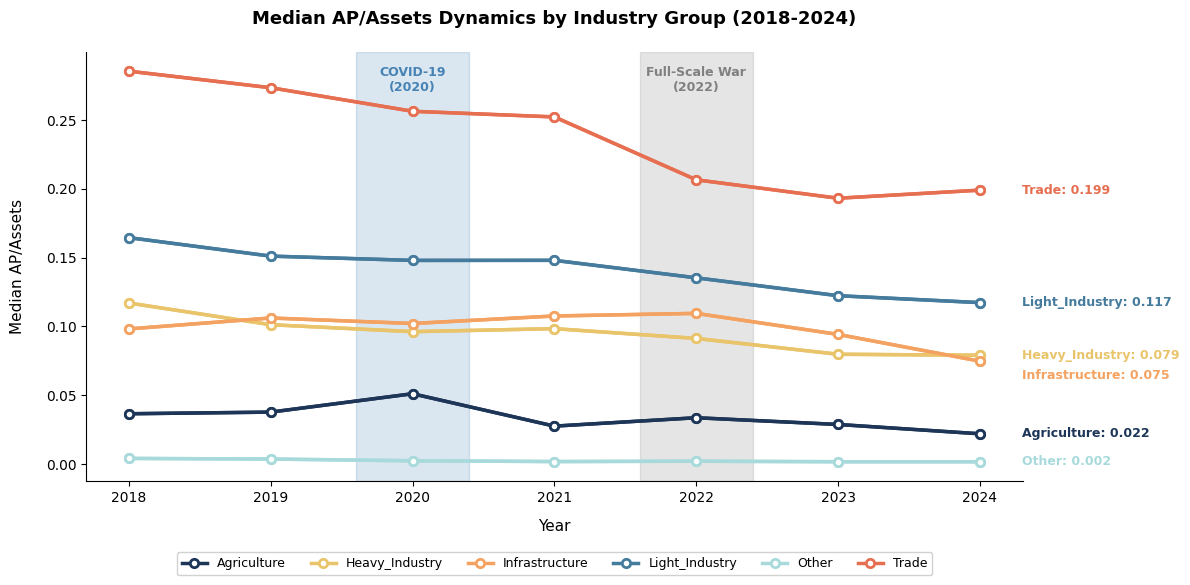

In [181]:
# ═══════════════════════════════════════════════════════════
# CELL · AP/ASSETS — INDUSTRY AND YEAR
# ═══════════════════════════════════════════════════════════

color_map = {
    'Trade'          : '#e76f51',
    'Infrastructure' : '#f4a261',
    'Light_Industry' : '#457b9d',
    'Heavy_Industry' : '#e9c46a',
    'Other'          : '#a8dadc',
    'Agriculture'    : '#1d3557',
}
industries = sorted(df_clean['Industry_Group'].dropna().unique())
col, name  = 'AP_Assets', 'AP/Assets'

fig, ax_line = plt.subplots(figsize=(12, 6))

offsets = {
    'Trade'          : 0.0,
    'Infrastructure' : -0.01,
    'Light_Industry' : 0.0,
    'Heavy_Industry' : 0.0,
    'Other'          : 0.0,
    'Agriculture'    : 0.0,
}

for industry in industries:
    yearly = (
        df_clean[df_clean['Industry_Group'] == industry]
        .groupby('Year')[col].median()
    )
    ax_line.plot(yearly.index.astype(str), yearly.values,
                 color=color_map[industry], linewidth=2.5, marker='o',
                 markersize=6, markerfacecolor='white',
                 markeredgecolor=color_map[industry], markeredgewidth=2)

    last_val = yearly.values[-1]
    ax_line.text(len(years) - 0.7,
                 last_val + offsets.get(industry, 0),
                 f'{industry}: {last_val:.3f}',
                 va='center', ha='left',
                 fontsize=9, color=color_map[industry], fontweight='bold')

# ── Right: by year ──

years = sorted(df_clean['Year'].unique())
x_pos = {y: i for i, y in enumerate(years)}
y_max = df_clean.groupby(['Industry_Group', 'Year'])[col].median().max()

for industry in industries:
    yearly = (
        df_clean[df_clean['Industry_Group'] == industry]
        .groupby('Year')[col].median()
    )
    ax_line.plot(yearly.index.astype(str), yearly.values,
                 color=color_map[industry], linewidth=2.5, marker='o',
                 markersize=6, markerfacecolor='white',
                 markeredgecolor=color_map[industry], markeredgewidth=2,
                 label=industry)

ax_line.axvspan(x_pos[2019] + 0.6, x_pos[2020] + 0.4,
                alpha=0.2, color='steelblue')
ax_line.axvspan(x_pos[2021] + 0.6, x_pos[2022] + 0.4,
                alpha=0.2, color='gray')
ax_line.text(x_pos[2020], y_max * 0.95, 'COVID-19\n(2020)',
             ha='center', fontsize=9, color='steelblue', fontweight='bold')
ax_line.text(x_pos[2022], y_max * 0.95, 'Full-Scale War\n(2022)',
             ha='center', fontsize=9, color='gray', fontweight='bold')

ax_line.set_title('Median AP/Assets Dynamics by Industry Group (2018-2024)', fontsize=13, fontweight='bold', pad=20)
ax_line.set_xlabel('Year', fontsize=11, labelpad=10)
ax_line.set_ylabel('Median AP/Assets', fontsize=11, labelpad=15)
ax_line.spines[['top', 'right']].set_visible(False)
ax_line.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
                fontsize=9, ncol=6, framealpha=0.9)
ax_line.grid(False)

plt.tight_layout()
plt.show()

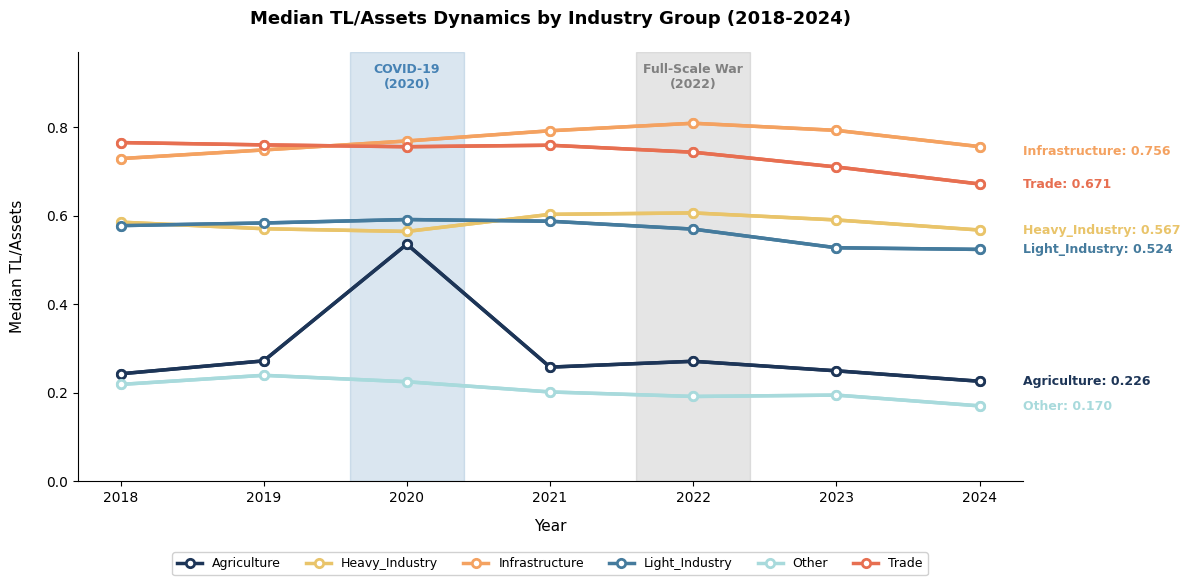

In [182]:
# ═══════════════════════════════════════════════════════════
# CELL · TL/ASSETS — INDUSTRY AND YEAR
# ═══════════════════════════════════════════════════════════

col, name = 'TL_Assets', 'TL/Assets'

fig, ax_line = plt.subplots(figsize=(12, 6))


# ── Right: by year ──

y_max = df_clean.groupby(['Industry_Group', 'Year'])[col].median().max()

for industry in industries:
    yearly = (
        df_clean[df_clean['Industry_Group'] == industry]
        .groupby('Year')[col].median()
    )
    ax_line.plot(yearly.index.astype(str), yearly.values,
                 color=color_map[industry], linewidth=2.5, marker='o',
                 markersize=6, markerfacecolor='white',
                 markeredgecolor=color_map[industry], markeredgewidth=2,
                 label=industry)
    
for industry in industries:
    yearly = (
        df_clean[df_clean['Industry_Group'] == industry]
        .groupby('Year')[col].median()
    )
    ax_line.plot(yearly.index.astype(str), yearly.values,
                 color=color_map[industry], linewidth=2.5, marker='o',
                 markersize=6, markerfacecolor='white',
                 markeredgecolor=color_map[industry], markeredgewidth=2)

    last_val = yearly.values[-1]
    ax_line.text(len(years) - 0.7,
                 last_val + offsets.get(industry, 0),
                 f'{industry}: {last_val:.3f}',
                 va='center', ha='left',
                 fontsize=9, color=color_map[industry], fontweight='bold')


ax_line.axvspan(x_pos[2019] + 0.6, x_pos[2020] + 0.4,
                alpha=0.2, color='steelblue')
ax_line.axvspan(x_pos[2021] + 0.6, x_pos[2022] + 0.4,
                alpha=0.2, color='gray')
ax_line.text(x_pos[2020], y_max * 1.1, 'COVID-19\n(2020)',
             ha='center', fontsize=9, color='steelblue', fontweight='bold')
ax_line.text(x_pos[2022], y_max * 1.1, 'Full-Scale War\n(2022)',
             ha='center', fontsize=9, color='gray', fontweight='bold')

ax_line.set_ylim(0, y_max * 1.2)
ax_line.set_title('Median TL/Assets Dynamics by Industry Group (2018-2024)', fontsize=13, fontweight='bold', pad=20)
ax_line.set_xlabel('Year', fontsize=11, labelpad=10)
ax_line.set_ylabel('Median TL/Assets', fontsize=11, labelpad=15)
ax_line.spines[['top', 'right']].set_visible(False)
ax_line.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
                fontsize=9, ncol=6, framealpha=0.9)
ax_line.grid(False)

plt.tight_layout()
plt.show()

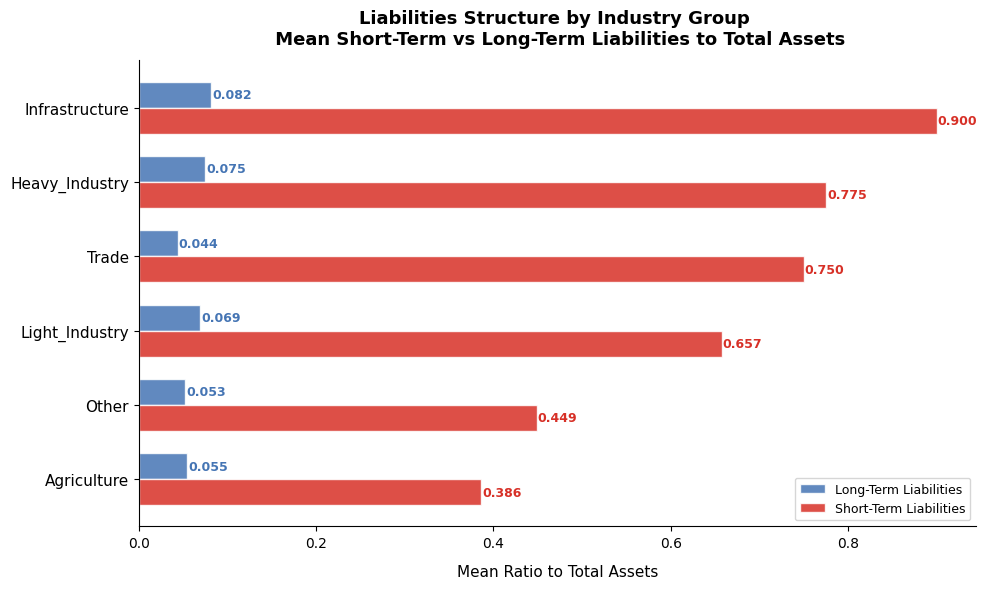

In [183]:
# ═══════════════════════════════════════════════════════════
# CELL · LT vs ST BANK DEBT — GROUPED BAR BY INDUSTRY
# ═══════════════════════════════════════════════════════════



df_liab = df_clean[df_clean['Total Liabilities'] > 0].copy()

lt_st = (
    df_liab.groupby('Industry_Group')
    .agg(
        LT_Liab=('LT_Liab_Assets', 'mean'),
        ST_Liab=('ST_Liab_Assets', 'mean'),
    )
    .reset_index()
    .sort_values('ST_Liab', ascending=True)
)

industries = lt_st['Industry_Group'].tolist()
x = np.arange(len(industries))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars_lt = ax.barh(x + width/2, lt_st['LT_Liab'], width,
                  color='#4575b4', edgecolor='white', label='Long-Term Liabilities', alpha=0.85)
bars_st = ax.barh(x - width/2, lt_st['ST_Liab'], width,
                  color='#d73027', edgecolor='white', label='Short-Term Liabilities', alpha=0.85)

for bar, val in zip(bars_lt, lt_st['LT_Liab']):
    if val > 0.001:
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', ha='left', fontsize=9,
                color='#4575b4', fontweight='bold')

for bar, val in zip(bars_st, lt_st['ST_Liab']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left', fontsize=9,
            color='#d73027', fontweight='bold')

ax.set_yticks(x)
ax.set_yticklabels(industries, fontsize=11)
ax.set_xlabel('Mean Ratio to Total Assets', fontsize=11, labelpad=10)
ax.set_title('Liabilities Structure by Industry Group \n Mean Short-Term vs Long-Term Liabilities to Total Assets',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()

In [184]:
print(f"LT_Liab_Assets = 0: {(df_liab['LT_Liab_Assets'] == 0).mean()*100:.1f}%")
print(f"ST_Liab_Assets = 0: {(df_liab['ST_Liab_Assets'] == 0).mean()*100:.1f}%")
print()
print(df_liab['LT_Liab_Assets'].describe())

LT_Liab_Assets = 0: 63.8%
ST_Liab_Assets = 0: 0.3%

count    79966.000000
mean         0.058693
std          0.165789
min          0.000000
25%          0.000000
50%          0.000000
75%          0.017868
max          1.021455
Name: LT_Liab_Assets, dtype: float64


In [185]:
# ═══════════════════════════════════════════════════════════
# CELL · BANK DEBT — PREVALENCE AND STRUCTURE
# ═══════════════════════════════════════════════════════════

colors_ind = ['#1d3557', '#457b9d', '#a8dadc', '#e9c46a', '#f4a261', '#e76f51']
industries = sorted(df_clean['Industry_Group'].dropna().unique())

# ── Calculate bank debt ratios ──
df_clean['LT_Bank_Assets']   = df_clean['Long-Term Bank Loans']  / df_clean['Total Assets']
df_clean['ST_Bank_Assets']   = df_clean['Short-Term Bank Loans'] / df_clean['Total Assets']
df_clean['Bank_Debt_Assets'] = df_clean['LT_Bank_Assets'] + df_clean['ST_Bank_Assets']

# Propagate to ana
ana['LT_Bank_Assets']   = ana['Long-Term Bank Loans']  / ana['Total Assets']
ana['ST_Bank_Assets']   = ana['Short-Term Bank Loans'] / ana['Total Assets']
ana['Bank_Debt_Assets'] = ana['LT_Bank_Assets'] + ana['ST_Bank_Assets']

# Subsamples
df_debt     = df_clean[df_clean['Bank_Debt_Assets'] > 0].copy()
df_debt_ana = ana[ana['Bank_Debt_Assets'] > 0].copy()

# ── Statistics ──
print("=" * 65)
print("BANK DEBT — PREVALENCE AND STRUCTURE")
print("=" * 65)
print(f"\ndf_clean (2018–2024):")
print(f"  Total observations  : {len(df_clean):,}")
print(f"  With bank debt      : {len(df_debt):,}  "
      f"({len(df_debt)/len(df_clean)*100:.1f}%)")
print(f"  Unique firms w/debt : {df_debt['Firm ID'].nunique():,}")

print(f"\nAnalytical sample (ana, 2019–2024):")
print(f"  Total observations  : {len(ana):,}")
print(f"  With bank debt      : {len(df_debt_ana):,}  "
      f"({len(df_debt_ana)/len(ana)*100:.1f}%)")
print(f"\n  Distress rate WITH debt    : "
      f"{df_debt_ana['Financial_Distress'].mean()*100:.1f}%")
print(f"  Distress rate WITHOUT debt : "
      f"{ana[ana['Bank_Debt_Assets']==0]['Financial_Distress'].mean()*100:.1f}%")

print("\nShare of firms with bank debt by Industry:")
industry_debt_share = (
    df_clean.groupby('Industry_Group')
    .apply(lambda x: pd.Series({
        'Total'     : len(x),
        'With Debt' : (x['Bank_Debt_Assets'] > 0).sum(),
        'Share (%)'  : (x['Bank_Debt_Assets'] > 0).mean() * 100,
    }))
    .round(1)
    .sort_values('Share (%)', ascending=False)
)
print(industry_debt_share.to_string())

print("\nDistress rate among firms WITH debt by Industry:")
distress_debt = (
    df_debt_ana.groupby('Industry_Group')['Financial_Distress']
    .agg(N='count', Distress_Rate='mean')
    .assign(Distress_Rate=lambda x: (x['Distress_Rate']*100).round(1))
    .sort_values('Distress_Rate', ascending=False)
)
print(distress_debt.to_string())

print("\nLT vs ST Bank Debt Structure (firms with debt):")
for col, name in [('LT_Bank_Assets',   'LT Bank/Assets'),
                  ('ST_Bank_Assets',   'ST Bank/Assets'),
                  ('Bank_Debt_Assets', 'Total Bank/Assets')]:
    print(f"  {name:<25} median: {df_debt[col].median():.4f}")

print("\nLT vs ST by Industry (median):")
lt_st = df_debt.groupby('Industry_Group')[
    ['LT_Bank_Assets', 'ST_Bank_Assets', 'Bank_Debt_Assets']
].median().round(4)
lt_st.columns = ['LT Bank/Assets', 'ST Bank/Assets', 'Total Bank/Assets']
lt_st['LT Share (%)'] = (lt_st['LT Bank/Assets'] / lt_st['Total Bank/Assets'] * 100).round(1)
lt_st['ST Share (%)'] = (lt_st['ST Bank/Assets'] / lt_st['Total Bank/Assets'] * 100).round(1)
print(lt_st.to_string())

BANK DEBT — PREVALENCE AND STRUCTURE

df_clean (2018–2024):
  Total observations  : 81,269
  With bank debt      : 18,399  (22.6%)
  Unique firms w/debt : 5,595

Analytical sample (ana, 2019–2024):
  Total observations  : 70,351
  With bank debt      : 15,648  (22.2%)

  Distress rate WITH debt    : 8.6%
  Distress rate WITHOUT debt : 15.2%

Share of firms with bank debt by Industry:
                  Total  With Debt  Share (%)
Industry_Group                               
Agriculture     13127.0     5951.0       45.3
Light_Industry   6423.0     2573.0       40.1
Trade           12284.0     3889.0       31.7
Heavy_Industry   9446.0     2577.0       27.3
Infrastructure   8389.0     1752.0       20.9
Other           31600.0     1657.0        5.2

Distress rate among firms WITH debt by Industry:
                   N  Distress_Rate
Industry_Group                     
Infrastructure  1498           14.4
Heavy_Industry  2212           11.8
Other           1402           11.1
Agriculture    

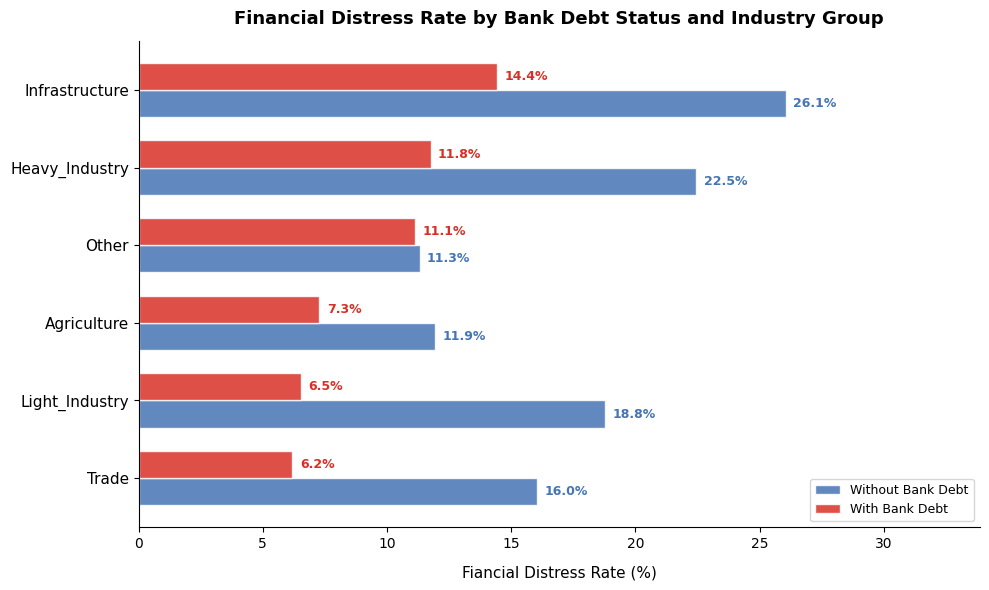

In [186]:
fig1, ax2 = plt.subplots(figsize=(10, 6))

distress_comparison = ana.groupby('Industry_Group').apply(
    lambda x: pd.Series({
        'With Debt'    : x[x['Bank_Debt_Assets'] > 0]['Financial_Distress'].mean() * 100,
        'Without Debt' : x[x['Bank_Debt_Assets'] == 0]['Financial_Distress'].mean() * 100,
    })
).sort_values('With Debt', ascending=True)

y     = np.arange(len(distress_comparison))
width = 0.35

bars1 = ax2.barh(y - width/2, distress_comparison['Without Debt'],
                 height=width, color='#4575b4', edgecolor='white', label='Without Bank Debt', alpha=0.85)
bars2 = ax2.barh(y + width/2, distress_comparison['With Debt'],
                 height=width, color='#d73027', edgecolor='white', label='With Bank Debt', alpha=0.85)

# for bar, val in zip(bars1, distress_comparison['Without Debt']):
#     ax2.text(val + 0.3, bar.get_y() + bar.get_height()/2,
#              f'{val:.1f}%', va='center', ha='left', fontsize=9)
# for bar, val in zip(bars2, distress_comparison['With Debt']):
#     ax2.text(val + 0.3, bar.get_y() + bar.get_height()/2,
#              f'{val:.1f}%', va='center', ha='left', fontsize=9)

for bar, val in zip(bars1, distress_comparison['Without Debt']):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', ha='left',
            fontsize=9, color='#4575b4', fontweight='bold')

for bar, val in zip(bars2, distress_comparison['With Debt']):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', ha='left',
            fontsize=9, color='#d73027', fontweight='bold')

ax2.set_yticks(y)
ax2.set_yticklabels(distress_comparison.index, fontsize=11)
ax2.set_title('Financial Distress Rate by Bank Debt Status and Industry Group',
              fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Fiancial Distress Rate (%)', fontsize=11, labelpad=10)
ax2.set_xlim(0, distress_comparison.max().max() * 1.3)
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(fontsize=9, loc='lower right')
ax2.grid(False)
plt.tight_layout()
plt.show()

AP/Assets QUARTILE ANALYSIS

AP/Assets quartile thresholds:
0.25    0.0013
0.50    0.0333
0.75    0.1978

Financial profile by AP/Assets quartile:
AP_quartile         Q1 (Low)          Q2          Q3   Q4 (High)
N                 17587.0000  17587.0000  17587.0000  17587.0000
Median_Assets        32.6000     66.7000     92.9000     81.4000
Median_Revenue        0.8000     29.9000     81.5000    103.6000
Median_ROA            0.0022      0.0171      0.0288      0.0144
Distress_Rate        10.6000     10.4000     11.4000     22.6000
Has_Debt              6.1000     21.1000     34.2000     27.5000
Median_AP_Assets      0.0000      0.0094      0.0855      0.4560

Distress rate by AP quartile and Industry:
AP_quartile     Q1 (Low)    Q2    Q3  Q4 (High)
Industry_Group                                 
Agriculture          7.3   6.4   9.6       22.7
Heavy_Industry      26.9  15.7  13.1       27.3
Infrastructure      26.5  17.5  13.9       33.0
Light_Industry      17.3  11.6   8.6       19.4
O

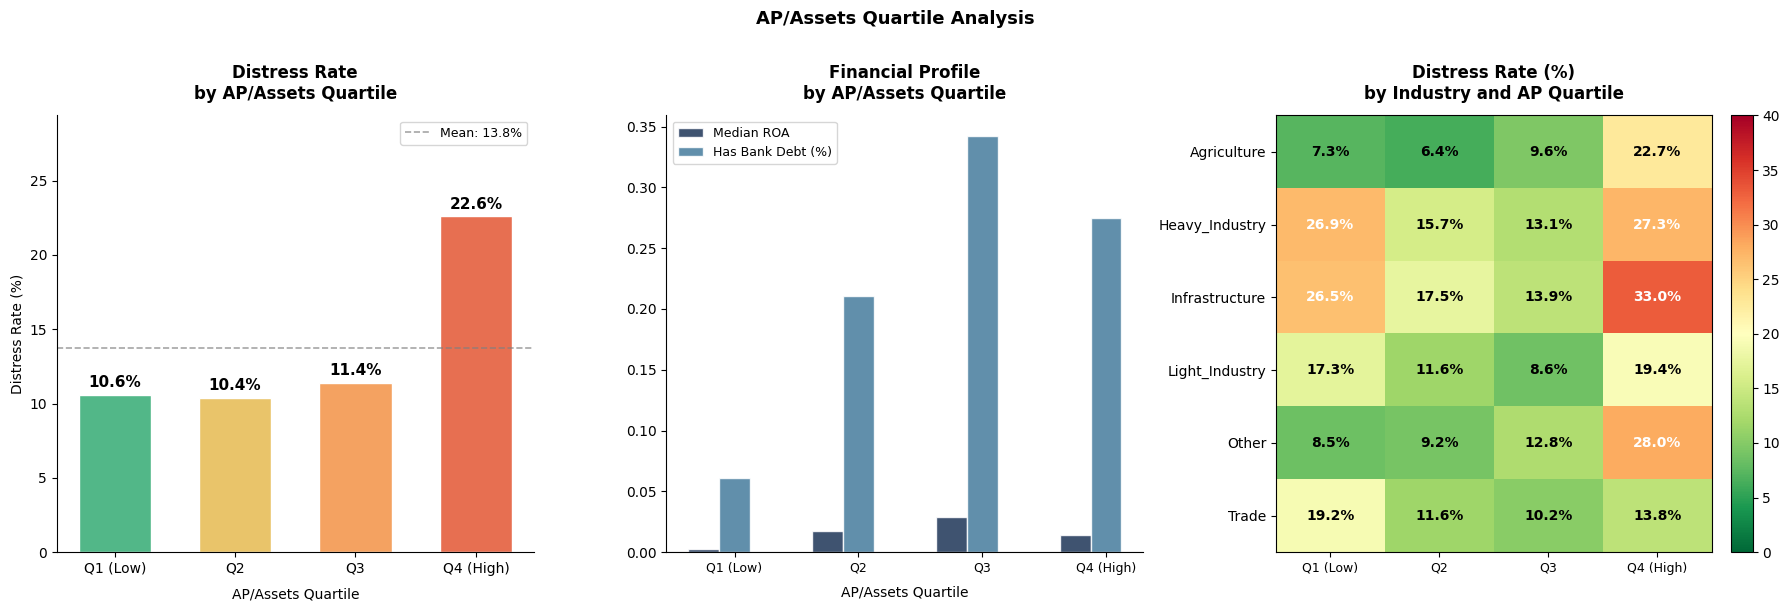

In [187]:
# ═══════════════════════════════════════════════════════════
# CELL · AP/ASSETS QUARTILE ANALYSIS
# ═══════════════════════════════════════════════════════════

# ── AP quartiles ──
ana['AP_quartile'] = pd.qcut(
    ana['AP_Assets'],
    q=4,
    labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']
)

# ── Statistics ──
print("=" * 65)
print("AP/Assets QUARTILE ANALYSIS")
print("=" * 65)

print("\nAP/Assets quartile thresholds:")
print(ana['AP_Assets'].quantile([0.25, 0.50, 0.75]).round(4).to_string())

comparison = ana.groupby('AP_quartile', observed=True).agg(
    N                = ('Firm ID',             'count'),
    Median_Assets    = ('Total Assets',        'median'),
    Median_Revenue   = ('Net Revenue',         'median'),
    Median_ROA       = ('ROA',                 'median'),
    Distress_Rate    = ('Financial_Distress',  'mean'),
    Has_Debt         = ('Has_Debt',            'mean'),
    Median_AP_Assets = ('AP_Assets',           'median'),
).round(4)

comparison['Distress_Rate']  = (comparison['Distress_Rate']  * 100).round(1)
comparison['Has_Debt']       = (comparison['Has_Debt']       * 100).round(1)
comparison['Median_Assets']  = (comparison['Median_Assets']  / 1e3).round(1)
comparison['Median_Revenue'] = (comparison['Median_Revenue'] / 1e3).round(1)

print("\nFinancial profile by AP/Assets quartile:")
print(comparison.T.to_string())

print("\nDistress rate by AP quartile and Industry:")
industry_quartile = (
    ana.groupby(['Industry_Group', 'AP_quartile'], observed=True)['Financial_Distress']
    .mean()
    .mul(100)
    .round(1)
    .unstack('AP_quartile')
)
print(industry_quartile.to_string())

# ── Plots ──
quartiles = ['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']
colors_q  = ['#52b788', '#e9c46a', '#f4a261', '#e76f51']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Plot 1: Distress rate by quartile ──
ax1 = axes[0]
distress_by_q = comparison['Distress_Rate']

bars = ax1.bar(quartiles, distress_by_q.values,
               color=colors_q, edgecolor='white', width=0.6)

for bar, val in zip(bars, distress_by_q.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom',
             fontsize=11, fontweight='bold')

ax1.axhline(y=distress_by_q.mean(), color='gray', linestyle='--',
            linewidth=1.2, alpha=0.7,
            label=f'Mean: {distress_by_q.mean():.1f}%')
ax1.set_title('Distress Rate\nby AP/Assets Quartile',
              fontsize=12, fontweight='bold', pad=12)
ax1.set_ylabel('Distress Rate (%)', fontsize=10)
ax1.set_xlabel('AP/Assets Quartile', fontsize=10, labelpad=8)
ax1.set_ylim(0, distress_by_q.max() * 1.3)
ax1.spines[['top', 'right']].set_visible(False)
ax1.legend(fontsize=9)
ax1.grid(False)

# ── Plot 2: Financial profile by quartile ──
ax2 = axes[1]
metrics_plot = {
    'Median ROA'       : 'Median_ROA',
    'Has Bank Debt (%)': 'Has_Debt',
}

x     = np.arange(len(quartiles))
width = 0.25

for i, (name, col) in enumerate(metrics_plot.items()):
    vals = comparison[col].values
    vals_plot = vals / 100 if col == 'Has_Debt' else vals
    ax2.bar(x + i * width, vals_plot, width=width,
            label=name, edgecolor='white', alpha=0.85,
            color=['#1d3557', '#457b9d', '#a8dadc'][i])

ax2.set_title('Financial Profile\nby AP/Assets Quartile',
              fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel('AP/Assets Quartile', fontsize=10, labelpad=8)
ax2.set_xticks(x + width)
ax2.set_xticklabels(quartiles, fontsize=9)
ax2.axhline(y=0, color='black', linewidth=0.8, alpha=0.4)
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(fontsize=9)
ax2.grid(False)

# ── Plot 3: Heatmap by industry and quartile ──
ax3 = axes[2]
im = ax3.imshow(industry_quartile.values, cmap='RdYlGn_r',
                aspect='auto', vmin=0, vmax=40)

ax3.set_xticks(range(4))
ax3.set_yticks(range(len(industry_quartile)))
ax3.set_xticklabels(quartiles, fontsize=9)
ax3.set_yticklabels(industry_quartile.index, fontsize=10)

for i in range(len(industry_quartile)):
    for j in range(4):
        val   = industry_quartile.values[i, j]
        color = 'white' if val > 25 else 'black'
        ax3.text(j, i, f'{val:.1f}%',
                 ha='center', va='center',
                 fontsize=10, fontweight='bold', color=color)

plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
ax3.set_title('Distress Rate (%)\nby Industry and AP Quartile',
              fontsize=12, fontweight='bold', pad=12)

fig.suptitle(
    f'AP/Assets Quartile Analysis',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

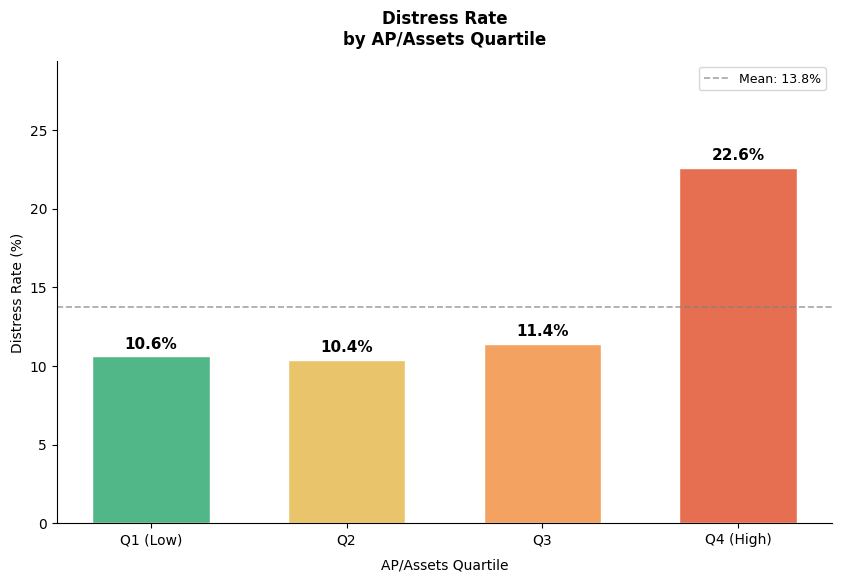

In [188]:

# ── Plots ──
quartiles = ['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']
colors_q  = ['#52b788', '#e9c46a', '#f4a261', '#e76f51']

fig, ax1 = plt.subplots(figsize=(10, 6))

# ── Plot 1: Distress rate by quartile ──

distress_by_q = comparison['Distress_Rate']

bars = ax1.bar(quartiles, distress_by_q.values,
               color=colors_q, edgecolor='white', width=0.6)

for bar, val in zip(bars, distress_by_q.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom',
             fontsize=11, fontweight='bold')

ax1.axhline(y=distress_by_q.mean(), color='gray', linestyle='--',
            linewidth=1.2, alpha=0.7,
            label=f'Mean: {distress_by_q.mean():.1f}%')
ax1.set_title('Distress Rate\nby AP/Assets Quartile',
              fontsize=12, fontweight='bold', pad=12)
ax1.set_ylabel('Distress Rate (%)', fontsize=10)
ax1.set_xlabel('AP/Assets Quartile', fontsize=10, labelpad=8)
ax1.set_ylim(0, distress_by_q.max() * 1.3)
ax1.spines[['top', 'right']].set_visible(False)
ax1.legend(fontsize=9)
ax1.grid(False)

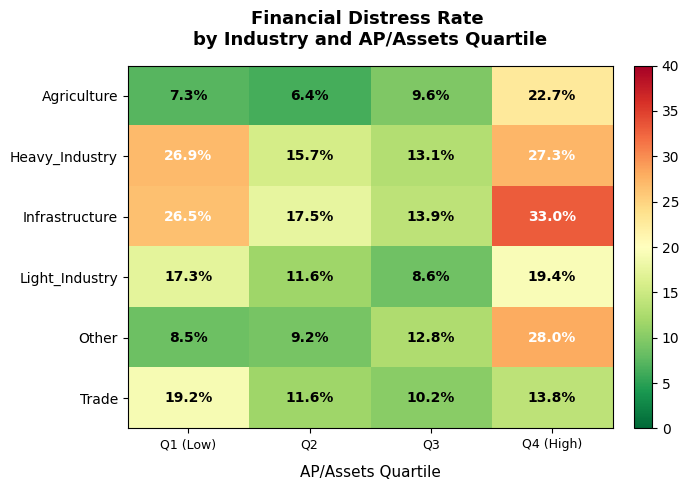

In [189]:
# ── Plot 3: Heatmap by industry and quartile ──

fig, ax3 = plt.subplots(figsize=(7, 5))

im = ax3.imshow(industry_quartile.values, cmap='RdYlGn_r',
                aspect='auto', vmin=0, vmax=40)

ax3.set_xticks(range(4))
ax3.set_yticks(range(len(industry_quartile)))
ax3.set_xticklabels(quartiles, fontsize=9)
ax3.set_yticklabels(industry_quartile.index, fontsize=10)

for i in range(len(industry_quartile)):
    for j in range(4):
        val   = industry_quartile.values[i, j]
        color = 'white' if val > 25 else 'black'
        ax3.text(j, i, f'{val:.1f}%',
                 ha='center', va='center',
                 fontsize=10, fontweight='bold', color=color)

plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
ax3.set_xlabel('AP/Assets Quartile', fontsize=11, labelpad=10)
ax3.set_title('Financial Distress Rate \nby Industry and AP/Assets Quartile',
              fontsize=13, fontweight='bold', pad=15)


plt.tight_layout()
plt.show()

LEVERAGE — Distress vs Non-Distress
Analytical sample: 70,351 observations

TL/Assets:
  Median Non-Distress :   0.3621
  Median Distress     :   1.1316
  Difference          :  +0.7695
  Mann-Whitney p      : 0.0000
  Effect size (r)     : 0.6052  large

AP/Assets:
  Median Non-Distress :   0.0284
  Median Distress     :   0.0956
  Difference          :  +0.0672
  Mann-Whitney p      : 0.0000
  Effect size (r)     : 0.2322  small

LT Liab/Assets:
  Median Non-Distress :   0.0000
  Median Distress     :   0.0000
  Difference          :  +0.0000
  Mann-Whitney p      : 0.0204
  Effect size (r)     : 0.0125  small

ST Liab/Assets:
  Median Non-Distress :   0.2917
  Median Distress     :   1.0598
  Difference          :  +0.7681
  Mann-Whitney p      : 0.0000
  Effect size (r)     : 0.5612  large

RANKING by Effect Size:
        Metric  Median Non-D  Median Distress  Difference  Effect size
     TL/Assets        0.3621           1.1316      0.7695       0.6052
ST Liab/Assets        0.2917

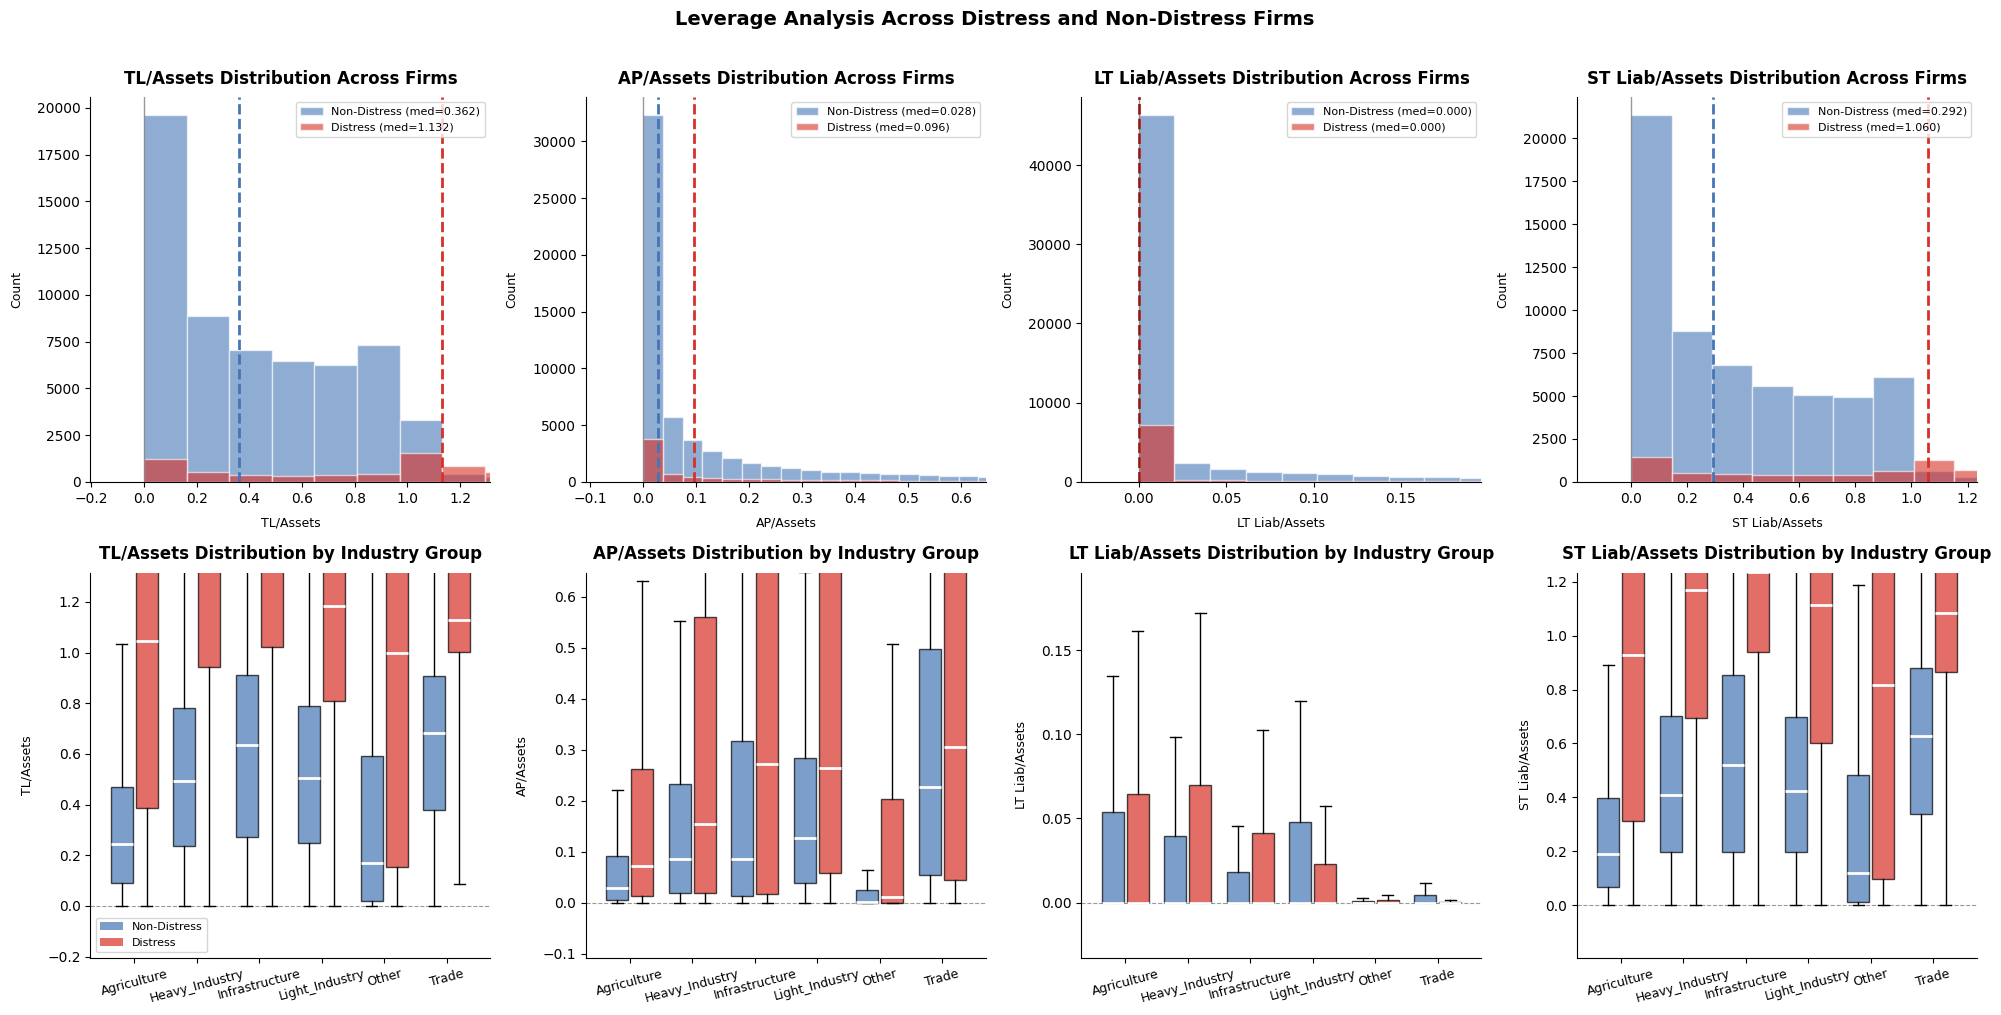

In [190]:
# ═══════════════════════════════════════════════════════════
# CELL · LEVERAGE — DISTRESS vs NON-DISTRESS
# ═══════════════════════════════════════════════════════════

from scipy import stats
from matplotlib.patches import Patch

metrics = {
    'TL/Assets'       : 'TL_Assets',
    'AP/Assets'       : 'AP_Assets',
    'LT Liab/Assets'  : 'LT_Liab_Assets',
    'ST Liab/Assets'  : 'ST_Liab_Assets',
}

colors_group = {0: '#4575b4', 1: '#d73027'}
labels_group = {0: 'Non-Distress', 1: 'Distress'}
industries   = sorted(ana['Industry_Group'].dropna().unique())

# ── Statistics ──
print("=" * 65)
print("LEVERAGE — Distress vs Non-Distress")
print(f"Analytical sample: {len(ana):,} observations")
print("=" * 65)

results = []
for name, col in metrics.items():
    d0 = ana[ana['Financial_Distress'] == 0][col].dropna()
    d1 = ana[ana['Financial_Distress'] == 1][col].dropna()

    stat, p_val = stats.mannwhitneyu(d0, d1, alternative='two-sided')
    effect      = abs(1 - (2 * stat) / (len(d0) * len(d1)))

    results.append({
        'Metric'          : name,
        'Median Non-D'    : d0.median(),
        'Median Distress' : d1.median(),
        'Difference'      : d1.median() - d0.median(),
        'p-value'         : p_val,
        'Effect size'     : effect,
    })

    print(f"\n{name}:")
    print(f"  Median Non-Distress : {d0.median():>8.4f}")
    print(f"  Median Distress     : {d1.median():>8.4f}")
    print(f"  Difference          : {d1.median() - d0.median():>+8.4f}")
    print(f"  Mann-Whitney p      : {p_val:.4f}")
    print(f"  Effect size (r)     : {effect:.4f}  "
          f"{'large' if effect > 0.5 else 'medium' if effect > 0.3 else 'small'}")

results_df = pd.DataFrame(results).sort_values('Effect size', ascending=False)

print(f"\n{'='*65}")
print("RANKING by Effect Size:")
print(results_df[['Metric', 'Median Non-D', 'Median Distress',
                   'Difference', 'Effect size']].round(4).to_string(index=False))
print(f"\n→ Best predictor: {results_df.iloc[0]['Metric']}")

# ── Plots ──
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for col_idx, (name, col) in enumerate(metrics.items()):

    # ── Top row: distributions ──
    ax_hist = axes[0, col_idx]

    all_data_hist = ana[col].dropna()
    p10_h    = all_data_hist.quantile(0.10)
    p90_h    = all_data_hist.quantile(0.90)
    margin_h = (p90_h - p10_h) * 0.2

    for group in [0, 1]:
        data = ana[ana['Financial_Distress'] == group][col].dropna()
        ax_hist.hist(data, bins=50,
                     color=colors_group[group], alpha=0.6,
                     edgecolor='white',
                     label=f"{labels_group[group]} (med={data.median():.3f})")
        ax_hist.axvline(data.median(),
                        color=colors_group[group],
                        linewidth=2, linestyle='--')

    ax_hist.axvline(0, color='black', linewidth=1.0,
                    linestyle='-', alpha=0.4)
    ax_hist.set_xlim(p10_h - margin_h, p90_h + margin_h)
    ax_hist.set_title(f'{name} Distribution Across Firms',
                      fontsize=12, fontweight='bold', pad=10)
    ax_hist.set_xlabel(name, fontsize=9, labelpad=8)
    ax_hist.set_ylabel('Count', fontsize=9, labelpad=10)
    ax_hist.legend(fontsize=8, framealpha=0.8)
    ax_hist.spines[['top', 'right']].set_visible(False)
    ax_hist.grid(False)

    # ── Bottom row: boxplot by industry ──
    ax_box = axes[1, col_idx]

    positions_0 = np.arange(len(industries)) - 0.2
    positions_1 = np.arange(len(industries)) + 0.2

    data_0 = [ana[(ana['Industry_Group'] == ind) &
                   (ana['Financial_Distress'] == 0)][col].dropna()
               for ind in industries]
    data_1 = [ana[(ana['Industry_Group'] == ind) &
                   (ana['Financial_Distress'] == 1)][col].dropna()
               for ind in industries]

    bp0 = ax_box.boxplot(data_0, positions=positions_0, widths=0.35,
                         patch_artist=True, showfliers=False,
                         medianprops=dict(color='white', linewidth=2))
    bp1 = ax_box.boxplot(data_1, positions=positions_1, widths=0.35,
                         patch_artist=True, showfliers=False,
                         medianprops=dict(color='white', linewidth=2))

    for patch in bp0['boxes']:
        patch.set_facecolor(colors_group[0])
        patch.set_alpha(0.7)
    for patch in bp1['boxes']:
        patch.set_facecolor(colors_group[1])
        patch.set_alpha(0.7)

    # Y-axis scale P10/P90
    all_data = ana[col].dropna()
    p10      = all_data.quantile(0.10)
    p90      = all_data.quantile(0.90)
    margin   = (p90 - p10) * 0.2
    ax_box.set_ylim(p10 - margin, p90 + margin)

    ax_box.axhline(y=0, color='black', linewidth=0.8,
                   linestyle='--', alpha=0.4)
    ax_box.set_xticks(np.arange(len(industries)))
    ax_box.set_xticklabels(industries, rotation=15, fontsize=9)
    ax_box.set_title(f'{name} Distribution by Industry Group',
                     fontsize=12, fontweight='bold', pad=10)
    ax_box.set_ylabel(name, fontsize=9, labelpad=10)
    ax_box.spines[['top', 'right']].set_visible(False)
    ax_box.grid(False)

    if col_idx == 0:
        legend_elements = [
            Patch(facecolor=colors_group[0], alpha=0.7, label='Non-Distress'),
            Patch(facecolor=colors_group[1], alpha=0.7, label='Distress')
        ]
        ax_box.legend(handles=legend_elements, fontsize=8)

fig.suptitle('Leverage Analysis Across Distress and Non-Distress Firms',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


##### Solvency

INTEREST COVERAGE ANALYSIS

Total observations:           81,269
With Financial Expenses > 0:  32,550  (40.1%)

IC categories (EBIT-based):
  IC > 3  (comfortable)          16,255  (49.9%)
  IC 1-3  (adequate)              6,465  (19.9%)
  IC 0-1  (at risk)               2,406  (7.4%)
  IC < 0  (critical)              7,353  (22.6%)

Median IC_Ratio by Industry:
                Median    Mean  Below_1
Industry_Group                         
Agriculture      5.860  34.484   19.285
Heavy_Industry   4.507  33.663   25.977
Light_Industry   3.986  28.981   18.333
Trade            3.783  34.398   18.839
Infrastructure   1.823  25.766   38.370
Other            0.899  18.193   53.321

Median IC_Ratio by Year:
Year
2018    3.421
2019    2.414
2020    1.987
2021    4.673
2022    2.521
2023    2.709
2024    3.891


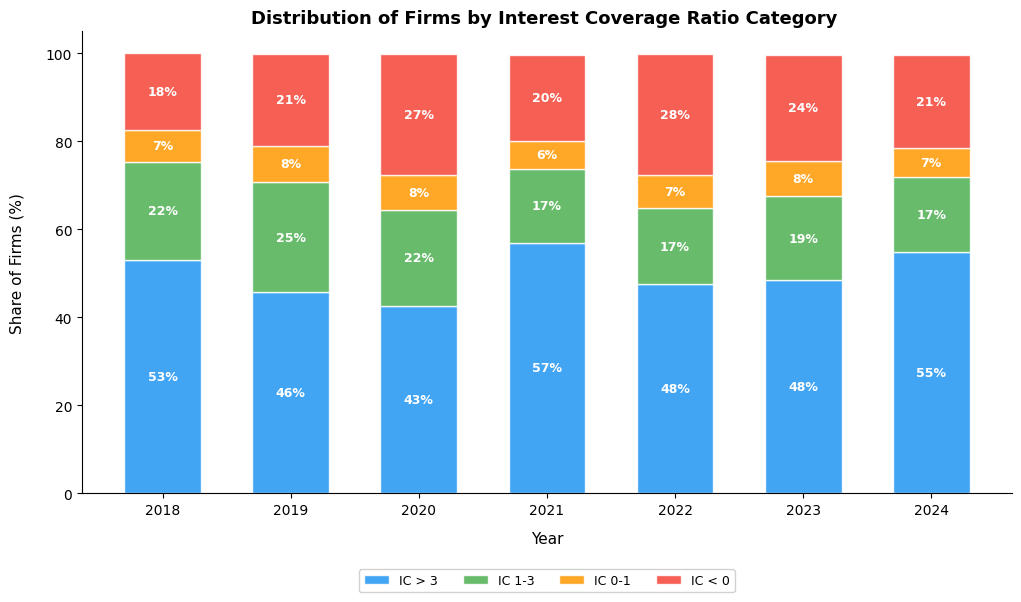

In [191]:
# ══════════════════════════════════════════════════════
# F1. INTEREST COVERAGE (df_clean)
# ══════════════════════════════════════════════════════
df_ic = df_clean[df_clean['Financial Expenses'] > 0].copy()

industries = sorted(df_clean['Industry_Group'].dropna().unique())

# ── Статистика ──
print("=" * 65)
print("INTEREST COVERAGE ANALYSIS")
print("=" * 65)
print(f"\nTotal observations:           {len(df_clean):,}")
print(f"With Financial Expenses > 0:  {len(df_ic):,}  "
      f"({len(df_ic)/len(df_clean)*100:.1f}%)")

print("\nIC categories (EBIT-based):")
for label, cond in [
    ('IC > 3  (comfortable)', df_ic['IC_Ratio'] > 3),
    ('IC 1-3  (adequate)',   (df_ic['IC_Ratio'] > 1) & (df_ic['IC_Ratio'] <= 3)),
    ('IC 0-1  (at risk)',    (df_ic['IC_Ratio'] > 0) & (df_ic['IC_Ratio'] <= 1)),
    ('IC < 0  (critical)',   df_ic['IC_Ratio'] < 0),
]:
    n   = cond.sum()
    pct = n / len(df_ic) * 100
    print(f"  {label:<30} {n:>6,}  ({pct:.1f}%)")

print("\nMedian IC_Ratio by Industry:")
ind_ic = (
    df_ic.groupby('Industry_Group')['IC_Ratio']
    .agg(Median='median', Mean='mean',
         Below_1=lambda x: (x < 1).mean() * 100)
    .round(3)
    .sort_values('Median', ascending=False)
)
print(ind_ic.to_string())

print("\nMedian IC_Ratio by Year:")
print(df_ic.groupby('Year')['IC_Ratio'].median().round(3).to_string())

# ══════════════════════════════════════════════════════
# ГРАФІКИ
# ══════════════════════════════════════════════════════
fig, ax1 = plt.subplots(figsize=(12, 6))

# ── Графік 1: IC категорії по роках (stacked) ──
yearly_cats = df_ic.groupby('Year').apply(lambda x: pd.Series({
    'IC > 3':  (x['IC_Ratio'] > 3).mean() * 100,
    'IC 1-3': ((x['IC_Ratio'] > 1) & (x['IC_Ratio'] <= 3)).mean() * 100,
    'IC 0-1': ((x['IC_Ratio'] > 0) & (x['IC_Ratio'] <= 1)).mean() * 100,
    'IC < 0':  (x['IC_Ratio'] < 0).mean() * 100,
})).round(1)

colors_cat = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

# colors_cat = ['#52b788', '#e9c46a', '#f4a261', '#e76f51']
left = np.zeros(len(yearly_cats))

for col, color in zip(yearly_cats.columns, colors_cat):
    vals = yearly_cats[col].values
    bars = ax1.bar(yearly_cats.index.astype(str), vals, bottom=left,
                   color=color, edgecolor='white',
                   label=col, width=0.6, alpha=0.85)
    for i, (bar, val) in enumerate(zip(bars, vals)):
        if val > 6:
            ax1.text(bar.get_x() + bar.get_width()/2,
                     left[i] + val/2,
                     f'{val:.0f}%', ha='center', va='center',
                     fontsize=9, color='white', fontweight='bold')
    left += vals

ax1.set_title('Distribution of Firms by Interest Coverage Ratio Category ',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Year', fontsize=11, labelpad=10)
ax1.set_ylabel('Share of Firms (%)', fontsize=11, labelpad=15)
ax1.spines[['top', 'right']].set_visible(False)
ax1.legend(fontsize=9, loc='upper center',
           bbox_to_anchor=(0.5, -0.15), ncol=4, framealpha=0.9)
ax1.grid(False)


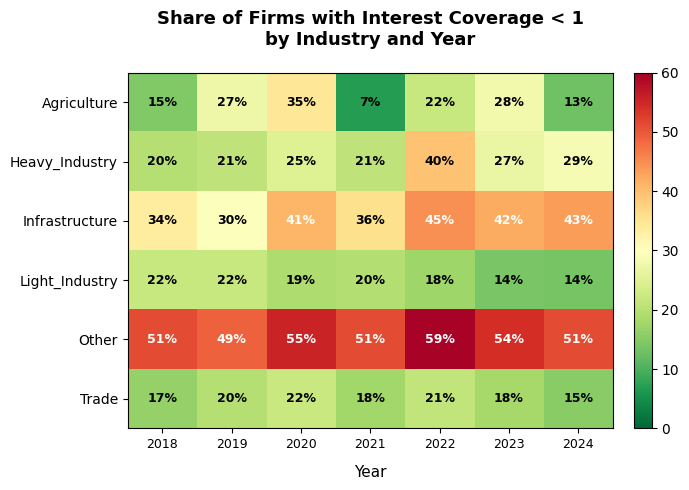

In [192]:


# ══════════════════════════════════════════════════════
# ГРАФІКИ
# ══════════════════════════════════════════════════════
fig, ax2 = plt.subplots(figsize=(7, 5))

# ── Графік 2: % фірм з IC < 1 по галузях і роках (heatmap) ──
heatmap_data = (
    df_ic.groupby(['Industry_Group', 'Year'])
    .apply(lambda x: (x['IC_Ratio'] < 1).mean() * 100)
    .unstack('Year')
    .round(1)
)

im = ax2.imshow(heatmap_data.values, cmap='RdYlGn_r',
                aspect='auto', vmin=0, vmax=60)

ax2.set_xticks(range(len(heatmap_data.columns)))
ax2.set_yticks(range(len(heatmap_data.index)))
ax2.set_xticklabels(heatmap_data.columns, fontsize=9)
ax2.set_xlabel('Year', fontsize=11, labelpad=10)
ax2.set_yticklabels(heatmap_data.index, fontsize=10)

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val   = heatmap_data.values[i, j]
        color = 'white' if val > 40 else 'black'
        ax2.text(j, i, f'{val:.0f}%', ha='center', va='center',
                 fontsize=9, fontweight='bold', color=color)

plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
ax2.set_title('Share of Firms with Interest Coverage < 1\nby Industry and Year',
              fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

In [193]:
# # ═══════════════════════════════════════════════════════════
# # CELL · INTEREST COVERAGE — DYNAMICS BY YEAR
# # ═══════════════════════════════════════════════════════════

# fig, ax = plt.subplots(figsize=(12, 6))

# years = sorted(df_ic['Year'].unique())
# x_pos = {y: i for i, y in enumerate(years)}
# y_max = (
#     df_ic.groupby(['Industry_Group', 'Year'])['IC_EBIT_wins']
#     .median().max()
# )

# offsets = {
#     'Agriculture'    :  0.0,
#     'Light_Industry' :  0.0,
#     'Heavy_Industry' : -0.3,
#     'Trade'          : -0.08,
#     'Infrastructure' :  0.0,
#     'Other'          : -0.0,
# }

# for industry in industries:
#     yearly = (
#         df_ic[df_ic['Industry_Group'] == industry]
#         .groupby('Year')['IC_EBIT_wins']
#         .median()
#     )
#     ax.plot(yearly.index.astype(str), yearly.values,
#             color=color_map[industry], linewidth=2.5, marker='o',
#             markersize=6, markerfacecolor='white',
#             markeredgecolor=color_map[industry], markeredgewidth=2,
#             label=industry)

#     last_y = yearly.values[-1] + offsets.get(industry, 0)
#     ax.text(len(yearly) - 0.7, last_y,
#             f'{industry}: {yearly.values[-1]:.2f}',
#             va='center', ha='left', fontsize=8,
#             color=color_map[industry])

# ax.axhline(y=1, color='red', linestyle='--', linewidth=1.5,
#            alpha=0.6, label='IC = 1')
# ax.axhline(y=3, color='gray', linestyle=':', linewidth=1.2,
#            alpha=0.5, label='IC = 3')

# ax.axvspan(x_pos[2019] + 0.7, x_pos[2020] + 0.3, alpha=0.15, color='steelblue')
# ax.axvspan(x_pos[2021] + 0.7, x_pos[2022] + 0.3, alpha=0.15, color='#6d6875')
# ax.text(x_pos[2020], y_max * 1.1, 'COVID-19\n(2020)',
#         ha='center', fontsize=8, color='steelblue', alpha=0.8)
# ax.text(x_pos[2022], y_max * 1.1, 'Full-scale War\n(2022)',
#         ha='center', fontsize=8, color='#6d6875', alpha=0.8)

# ax.set_ylim(0, y_max * 1.2)
# ax.set_title('Median IC (EBIT) by Year',
#              fontsize=13, fontweight='bold', pad=12)
# ax.set_xlabel('Year', fontsize=10, labelpad=8)
# ax.set_ylabel('Median IC', fontsize=10)
# ax.spines[['top', 'right']].set_visible(False)
# ax.grid(False)

# plt.tight_layout()
# plt.show()

##### Activity

PAYABLES TURNOVER ANALYSIS
Analytical sample: 70,351 observations

Firms with AP > 0 : 60,896  (86.6%)

Payables Turnover — Distress vs Non-Distress:
  Median Non-Distress : 7.6464
  Median Distress     : 1.2806
  Difference          : -6.3658
  Mann-Whitney p      : 0.0000
  Effect size (r)     : 0.3063  medium

Median Payables Turnover by Industry:
                Median    Mean   Non_D  Distress
Industry_Group                                  
Agriculture     12.501  74.091  14.354     2.807
Light_Industry   7.456  33.425   8.547     1.588
Trade            7.139  42.138   7.860     2.249
Heavy_Industry   6.281  39.477   8.303     0.834
Infrastructure   5.798  42.379   8.609     0.961
Other            1.460  60.806   1.807     0.793

Correlation: Payables Turnover vs AP/Assets:
  Pearson r = -0.2339


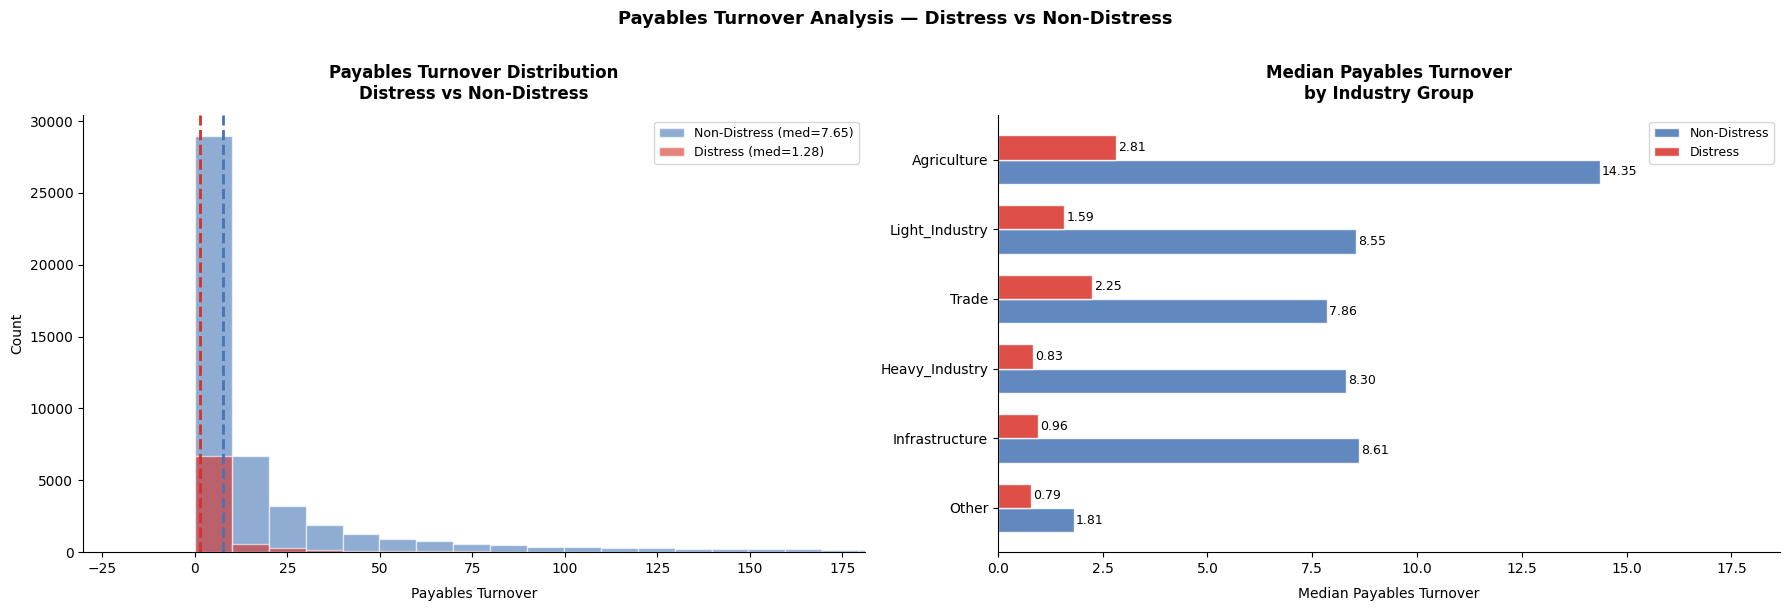

In [194]:
# ═══════════════════════════════════════════════════════════
# CELL · PAYABLES TURNOVER — DISTRESS vs NON-DISTRESS
# ═══════════════════════════════════════════════════════════

from scipy import stats

colors_group = {0: '#4575b4', 1: '#d73027'}
labels_group = {0: 'Non-Distress', 1: 'Distress'}
industries   = sorted(ana['Industry_Group'].dropna().unique())

# ── Statistics ──
print("=" * 65)
print("PAYABLES TURNOVER ANALYSIS")
print(f"Analytical sample: {len(ana):,} observations")
print("=" * 65)
print(f"\nFirms with AP > 0 : {ana['Payables_Turnover'].notna().sum():,}  "
      f"({ana['Payables_Turnover'].notna().mean()*100:.1f}%)")

d0 = ana[ana['Financial_Distress'] == 0]['Payables_Turnover'].dropna()
d1 = ana[ana['Financial_Distress'] == 1]['Payables_Turnover'].dropna()

stat, p_val = stats.mannwhitneyu(d0, d1, alternative='two-sided')
effect      = abs(1 - (2 * stat) / (len(d0) * len(d1)))

print(f"\nPayables Turnover — Distress vs Non-Distress:")
print(f"  Median Non-Distress : {d0.median():.4f}")
print(f"  Median Distress     : {d1.median():.4f}")
print(f"  Difference          : {d1.median() - d0.median():+.4f}")
print(f"  Mann-Whitney p      : {p_val:.4f}")
print(f"  Effect size (r)     : {effect:.4f}  "
      f"{'large' if effect > 0.5 else 'medium' if effect > 0.3 else 'small'}")

print("\nMedian Payables Turnover by Industry:")
ind_pt = (
    ana.groupby('Industry_Group')['Payables_Turnover']
    .agg(
        Median  = 'median',
        Mean    = 'mean',
        Non_D   = lambda x: x[ana.loc[x.index, 'Financial_Distress'] == 0].median(),
        Distress= lambda x: x[ana.loc[x.index, 'Financial_Distress'] == 1].median()
    )
    .round(3)
    .sort_values('Median', ascending=False)
)
print(ind_pt.to_string())

print("\nCorrelation: Payables Turnover vs AP/Assets:")
corr = ana[['Payables_Turnover', 'AP_Assets']].corr().iloc[0, 1]
print(f"  Pearson r = {corr:.4f}")

# ── Plots ──
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Plot 1: Distribution ──
ax1 = axes[0]

all_data_hist = ana['Payables_Turnover'].dropna()
p10_h    = all_data_hist.quantile(0.10)
p90_h    = all_data_hist.quantile(0.90)
margin_h = (p90_h - p10_h) * 0.2

for group in [0, 1]:
    data = ana[ana['Financial_Distress'] == group]['Payables_Turnover'].dropna()
    ax1.hist(data, bins=50,
             color=colors_group[group], alpha=0.6,
             edgecolor='white',
             label=f"{labels_group[group]} (med={data.median():.2f})")
    ax1.axvline(data.median(), color=colors_group[group],
                linewidth=2, linestyle='--')

ax1.set_xlim(p10_h - margin_h, p90_h + margin_h)
ax1.set_title('Payables Turnover Distribution\nDistress vs Non-Distress',
              fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel('Payables Turnover', fontsize=10, labelpad=8)
ax1.set_ylabel('Count', fontsize=10)
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

ax1.grid(False)

# ── Plot 2: By industry ──
ax2 = axes[1]
ind_sorted = ind_pt.sort_values('Median', ascending=True)
y     = np.arange(len(ind_sorted))
width = 0.35

bars1 = ax2.barh(y - width/2, ind_sorted['Non_D'],
                 height=width, color=colors_group[0],
                 edgecolor='white', alpha=0.85, label='Non-Distress')
bars2 = ax2.barh(y + width/2, ind_sorted['Distress'],
                 height=width, color=colors_group[1],
                 edgecolor='white', alpha=0.85, label='Distress')

for bar, val in zip(bars1, ind_sorted['Non_D']):
    ax2.text(val + 0.05, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', ha='left', fontsize=9)
for bar, val in zip(bars2, ind_sorted['Distress']):
    ax2.text(val + 0.05, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', ha='left', fontsize=9)

ax2.set_yticks(y)
ax2.set_yticklabels(ind_sorted.index, fontsize=10)
ax2.set_title('Median Payables Turnover\nby Industry Group',
              fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel('Median Payables Turnover', fontsize=10, labelpad=8)
ax2.set_xlim(0, ind_sorted[['Non_D', 'Distress']].max().max() * 1.3)
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(fontsize=9)
ax2.grid(False)


fig.suptitle('Payables Turnover Analysis — Distress vs Non-Distress',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

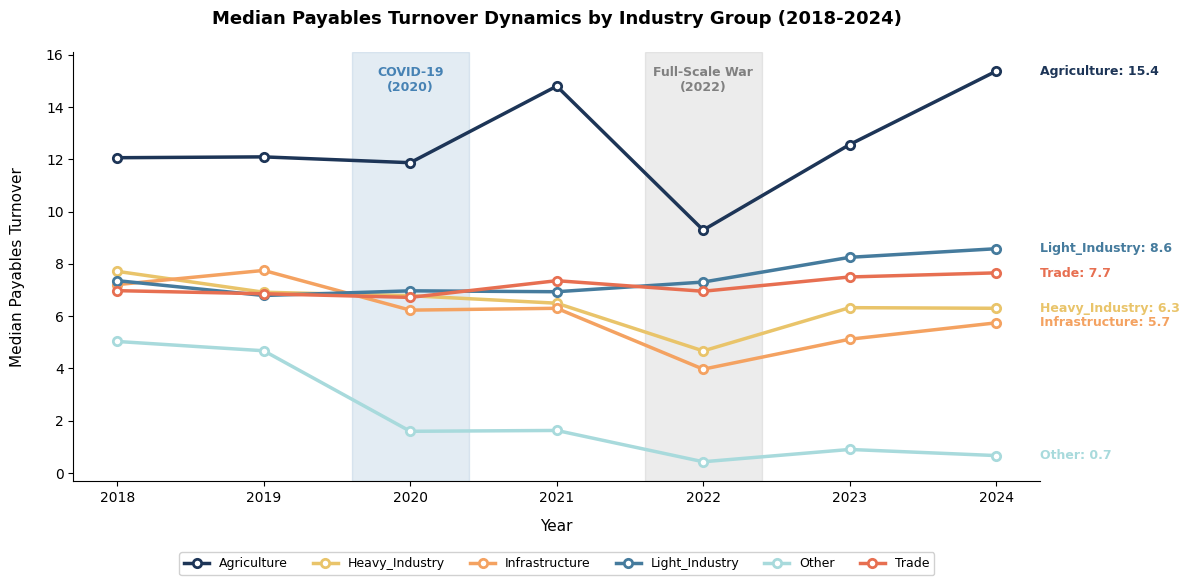

In [195]:
# ═══════════════════════════════════════════════════════════
# CELL · PAYABLES TURNOVER — DYNAMICS BY YEAR AND INDUSTRY
# ═══════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(12, 6))

years = sorted(df_clean['Year'].unique())
x_pos = {y: i for i, y in enumerate(years)}
y_max = df_clean.groupby(['Industry_Group', 'Year'])['Payables_Turnover'].median().max()

for industry in industries:
    yearly = (
        df_clean[df_clean['Industry_Group'] == industry]
        .groupby('Year')['Payables_Turnover']
        .median()
    )
    ax.plot(yearly.index.astype(str), yearly.values,
            color=color_map[industry], linewidth=2.5, marker='o',
            markersize=6, markerfacecolor='white',
            markeredgecolor=color_map[industry], markeredgewidth=2,
            label=industry)
    # ── Підпис в кінці лінії ──
    ax.text(len(yearly) - 0.7, yearly.values[-1],
            f'{industry}: {yearly.values[-1]:.1f}',
            va='center', ha='left', fontsize=9,
            color=color_map[industry], fontweight='bold')

ax.axvspan(x_pos[2019] + 0.6, x_pos[2020] + 0.4,
           alpha=0.15, color='steelblue')
ax.axvspan(x_pos[2021] + 0.6, x_pos[2022] + 0.4,
           alpha=0.15, color='gray')
ax.text(x_pos[2020], y_max * 0.95, 'COVID-19\n(2020)',
        ha='center', fontsize=9, color='steelblue', fontweight='bold')
ax.text(x_pos[2022], y_max * 0.95, 'Full-Scale War\n(2022)',
        ha='center', fontsize=9, color='gray', fontweight='bold')

ax.set_title('Median Payables Turnover Dynamics by Industry Group (2018-2024)',
             fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=11, labelpad=10)
ax.set_ylabel('Median Payables Turnover', fontsize=11, labelpad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
                fontsize=9, ncol=6, framealpha=0.9)
ax.grid(False)

plt.tight_layout()
plt.show()

ASSET TURNOVER ANALYSIS
Analytical sample: 70,351 observations

Asset Turnover — Distress vs Non-Distress:
  Median Non-Distress : 0.7200
  Median Distress     : 0.2574
  Difference          : -0.4626
  Mann-Whitney p      : 0.0000
  Effect size (r)     : 0.2210  small

Median Asset Turnover by Industry:
                Median  Non_D  Distress
Industry_Group                         
Trade            2.146  2.305     0.791
Light_Industry   1.383  1.492     0.360
Heavy_Industry   0.918  1.072     0.160
Infrastructure   0.804  0.968     0.344
Agriculture      0.616  0.637     0.344
Other            0.159  0.165     0.116


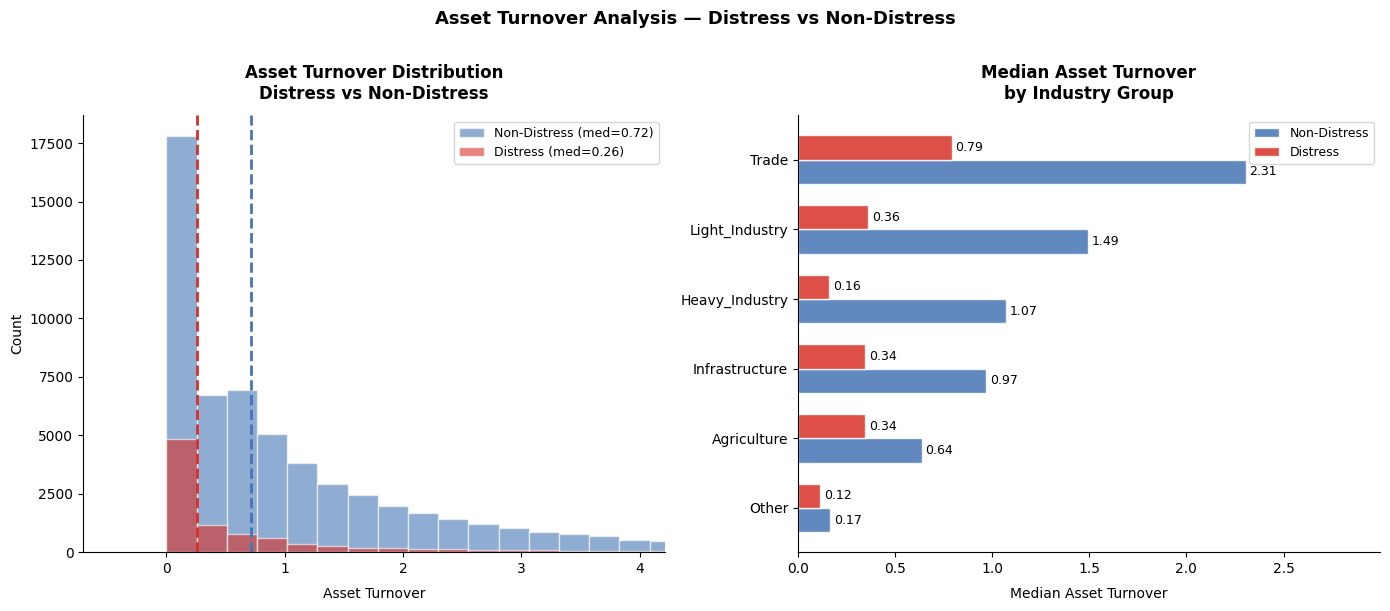

In [196]:
# ═══════════════════════════════════════════════════════════
# CELL · ASSET TURNOVER — DISTRIBUTION AND BY INDUSTRY
# ═══════════════════════════════════════════════════════════

from scipy import stats

colors_group = {0: '#4575b4', 1: '#d73027'}
labels_group = {0: 'Non-Distress', 1: 'Distress'}
industries   = sorted(ana['Industry_Group'].dropna().unique())

# ── Statistics ──
print("=" * 65)
print("ASSET TURNOVER ANALYSIS")
print(f"Analytical sample: {len(ana):,} observations")
print("=" * 65)

d0 = ana[ana['Financial_Distress'] == 0]['Asset_Turnover'].dropna()
d1 = ana[ana['Financial_Distress'] == 1]['Asset_Turnover'].dropna()

stat, p_val = stats.mannwhitneyu(d0, d1, alternative='two-sided')
effect      = abs(1 - (2 * stat) / (len(d0) * len(d1)))

print(f"\nAsset Turnover — Distress vs Non-Distress:")
print(f"  Median Non-Distress : {d0.median():.4f}")
print(f"  Median Distress     : {d1.median():.4f}")
print(f"  Difference          : {d1.median() - d0.median():+.4f}")
print(f"  Mann-Whitney p      : {p_val:.4f}")
print(f"  Effect size (r)     : {effect:.4f}  "
      f"{'large' if effect > 0.5 else 'medium' if effect > 0.3 else 'small'}")

print("\nMedian Asset Turnover by Industry:")
ind_at = (
    ana.groupby('Industry_Group')['Asset_Turnover']
    .agg(
        Median   = 'median',
        Non_D    = lambda x: x[ana.loc[x.index, 'Financial_Distress'] == 0].median(),
        Distress = lambda x: x[ana.loc[x.index, 'Financial_Distress'] == 1].median()
    )
    .round(3)
    .sort_values('Median', ascending=False)
)
print(ind_at.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Plot 1: Distribution ──
ax1 = axes[0]
all_data_hist = ana['Asset_Turnover'].dropna()
p10_h    = all_data_hist.quantile(0.10)
p90_h    = all_data_hist.quantile(0.90)
margin_h = (p90_h - p10_h) * 0.2

for group in [0, 1]:
    data = ana[ana['Financial_Distress'] == group]['Asset_Turnover'].dropna()
    ax1.hist(data, bins=50,
             color=colors_group[group], alpha=0.6,
             edgecolor='white',
             label=f"{labels_group[group]} (med={data.median():.2f})")
    ax1.axvline(data.median(), color=colors_group[group],
                linewidth=2, linestyle='--')

ax1.set_xlim(p10_h - margin_h, p90_h + margin_h)
ax1.set_title('Asset Turnover Distribution\nDistress vs Non-Distress',
              fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel('Asset Turnover', fontsize=10, labelpad=8)
ax1.set_ylabel('Count', fontsize=10)
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(False)

# ── Plot 2: By industry ──
ax2 = axes[1]
ind_sorted = ind_at.sort_values('Median', ascending=True)
y     = np.arange(len(ind_sorted))
width = 0.35

bars1 = ax2.barh(y - width/2, ind_sorted['Non_D'],
                 height=width, color=colors_group[0],
                 edgecolor='white', alpha=0.85, label='Non-Distress')
bars2 = ax2.barh(y + width/2, ind_sorted['Distress'],
                 height=width, color=colors_group[1],
                 edgecolor='white', alpha=0.85, label='Distress')

for bar, val in zip(bars1, ind_sorted['Non_D']):
    ax2.text(val + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', ha='left', fontsize=9)
for bar, val in zip(bars2, ind_sorted['Distress']):
    ax2.text(val + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', ha='left', fontsize=9)

ax2.set_yticks(y)
ax2.set_yticklabels(ind_sorted.index, fontsize=10)
ax2.set_title('Median Asset Turnover\nby Industry Group',
              fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel('Median Asset Turnover', fontsize=10, labelpad=8)
ax2.set_xlim(0, ind_sorted[['Non_D', 'Distress']].max().max() * 1.3)
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(fontsize=9)
ax2.grid(False)

fig.suptitle('Asset Turnover Analysis — Distress vs Non-Distress',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

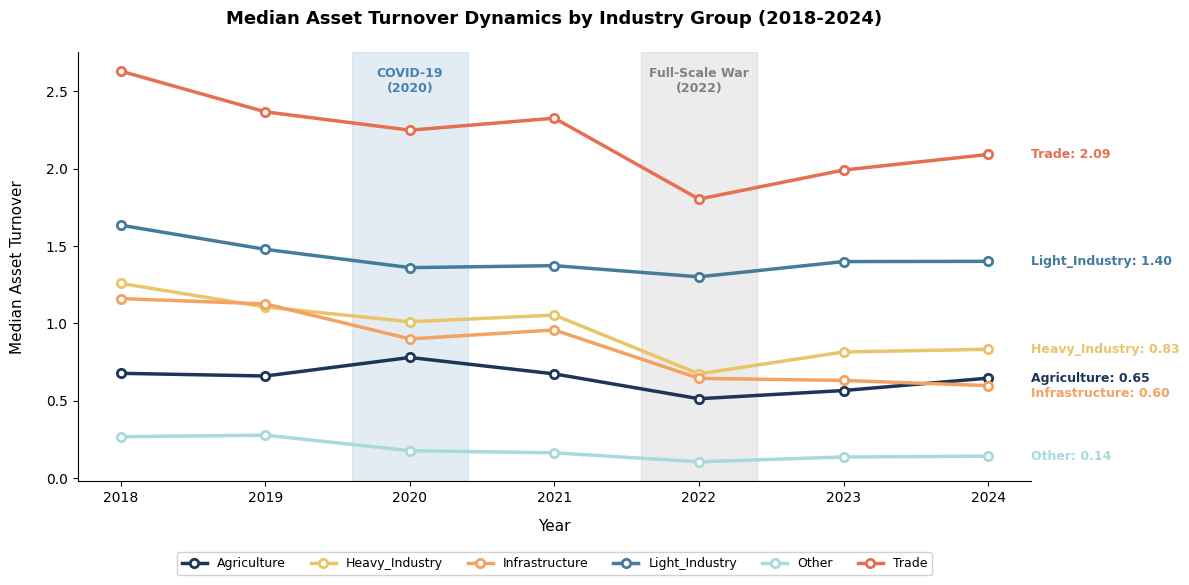

In [197]:
# ═══════════════════════════════════════════════════════════
# CELL · ASSET TURNOVER — DYNAMICS BY YEAR AND INDUSTRY
# ═══════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(12, 6))

years = sorted(df_clean['Year'].unique())
x_pos = {y: i for i, y in enumerate(years)}
y_max = (
    df_clean.groupby(['Industry_Group', 'Year'])['Asset_Turnover']
    .median().max()
)

offsets = {
    'Trade'          :  0.0,
    'Light_Industry' :  0.0,
    'Heavy_Industry' : 0.00,
    'Infrastructure' : -0.05,
    'Agriculture'    :  0.00,
    'Other'          :  0.00,
}

for industry in industries:
    yearly = (
        df_clean[df_clean['Industry_Group'] == industry]
        .groupby('Year')['Asset_Turnover']
        .median()
    )
    ax.plot(yearly.index.astype(str), yearly.values,
            color=color_map[industry], linewidth=2.5, marker='o',
            markersize=6, markerfacecolor='white',
            markeredgecolor=color_map[industry], markeredgewidth=2,
            label=industry)

    last_y = yearly.values[-1] + offsets.get(industry, 0)
    ax.text(len(yearly) - 0.7, last_y,
            f'{industry}: {yearly.values[-1]:.2f}',
            va='center', ha='left', fontsize=9,
            color=color_map[industry], fontweight='bold')

ax.axvspan(x_pos[2019] + 0.6, x_pos[2020] + 0.4,
           alpha=0.15, color='steelblue')
ax.axvspan(x_pos[2021] + 0.6, x_pos[2022] + 0.4,
           alpha=0.15, color='gray')
ax.text(x_pos[2020], y_max * 0.95, 'COVID-19\n(2020)',
        ha='center', fontsize=9, color='steelblue', fontweight='bold')
ax.text(x_pos[2022], y_max * 0.95, 'Full-Scale War\n(2022)',
        ha='center', fontsize=9, color='gray', fontweight='bold')

ax.set_title('Median Asset Turnover Dynamics by Industry Group (2018-2024)',
             fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=11, labelpad=10)
ax.set_ylabel('Median Asset Turnover', fontsize=11, labelpad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
                fontsize=9, ncol=6, framealpha=0.9)
ax.grid(False)

plt.tight_layout()
plt.show()

#### Investment Opportunities

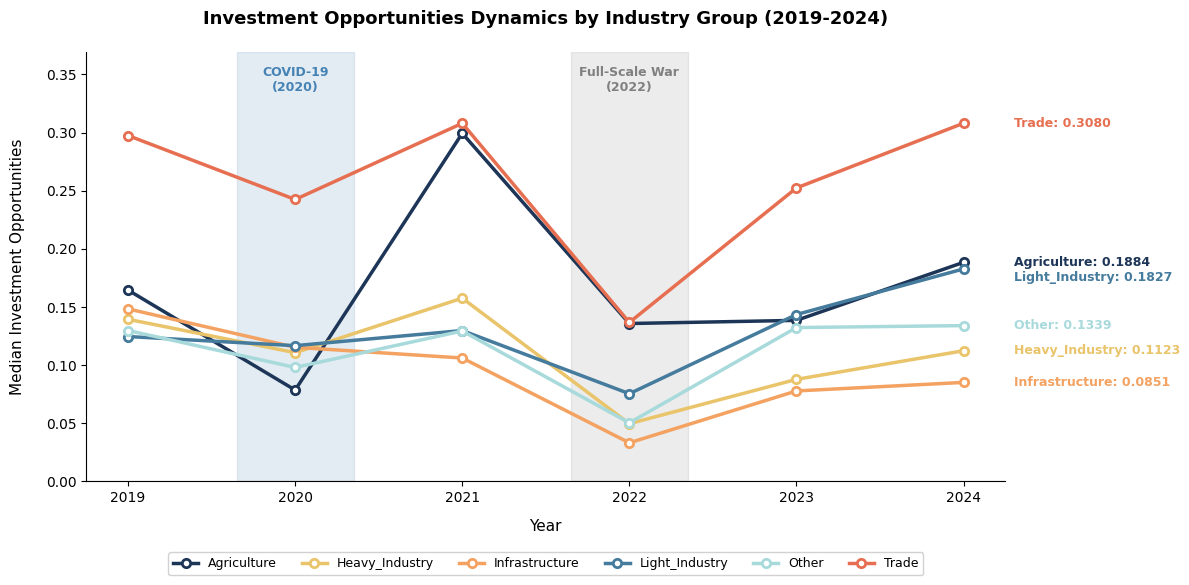

In [198]:
# ═══════════════════════════════════════════════════════════
# CELL · INVESTMENT OPPORTUNITIES — DYNAMICS BY YEAR
# ═══════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(12, 6))

years = sorted(df_clean['Year'].unique())
x_pos = {y: i for i, y in enumerate(years)}
y_max = (
    df_clean.groupby(['Industry_Group', 'Year'])['Investment_Opportunities']
    .median().max()
)

offsets = {
    'Agriculture'    :  0.00,
    'Heavy_Industry' :  0.00,
    'Infrastructure' :  0.00,
    'Light_Industry' : -0.007,
    'Other'          : 0.00,
    'Trade'          :  0.00,
}

for industry in industries:
    yearly = (
        df_clean[df_clean['Industry_Group'] == industry]
        .groupby('Year')['Investment_Opportunities']
        .median()
    )
    ax.plot(yearly.index.astype(str), yearly.values,
            color=color_map[industry], linewidth=2.5, marker='o',
            markersize=6, markerfacecolor='white',
            markeredgecolor=color_map[industry], markeredgewidth=2,
            label=industry)

    last_y = yearly.values[-1] + offsets.get(industry, 0)
    ax.text(len(yearly) - 0.7, last_y,
            f'{industry}: {yearly.values[-1]:.4f}',
            va='center', ha='left', fontsize=9, fontweight='bold',
            color=color_map[industry])

ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-', alpha=0.4)

ax.axvspan(x_pos[2019] + 0.65, x_pos[2020] + 0.35, alpha=0.15, color='steelblue')
ax.axvspan(x_pos[2021] + 0.65, x_pos[2022] + 0.35, alpha=0.15, color='gray')
ax.text(x_pos[2020], y_max * 1.09, 'COVID-19\n(2020)',
        ha='center', fontsize=9, color='steelblue', fontweight='bold')
ax.text(x_pos[2022], y_max * 1.09, 'Full-Scale War\n(2022)',
        ha='center', fontsize=9, color='gray', fontweight='bold')

ax.set_ylim(0, y_max * 1.2)
ax.set_title('Investment Opportunities Dynamics by Industry Group (2019-2024)',
             fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=11, labelpad=10)
ax.set_ylabel('Median Investment Opportunities', fontsize=11, labelpad=15)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
                fontsize=9, ncol=6, framealpha=0.9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()

INVESTMENT OPPORTUNITIES ANALYSIS

Total observations (df_clean)   : 81,269
Valid IO observations (df_clean) : 53,859  (66.3%)
Valid IO observations (ana)      : 53,859  (76.6%)

Median IO by Industry (df_clean):
Industry_Group
Trade             0.2479
Agriculture       0.1683
Light_Industry    0.1256
Other             0.1090
Heavy_Industry    0.1086
Infrastructure    0.0917

Median IO by Year (df_clean):
Year
2018       NaN
2019    0.1597
2020    0.1239
2021    0.1864
2022    0.0794
2023    0.1386
2024    0.1662

IO — Distress vs Non-Distress:
  Median Non-Distress : 0.1661
  Median Distress     : 0.0121
  Difference          : -0.1540
  Mann-Whitney p      : 0.0000
  Effect size (r)     : 0.3167  medium


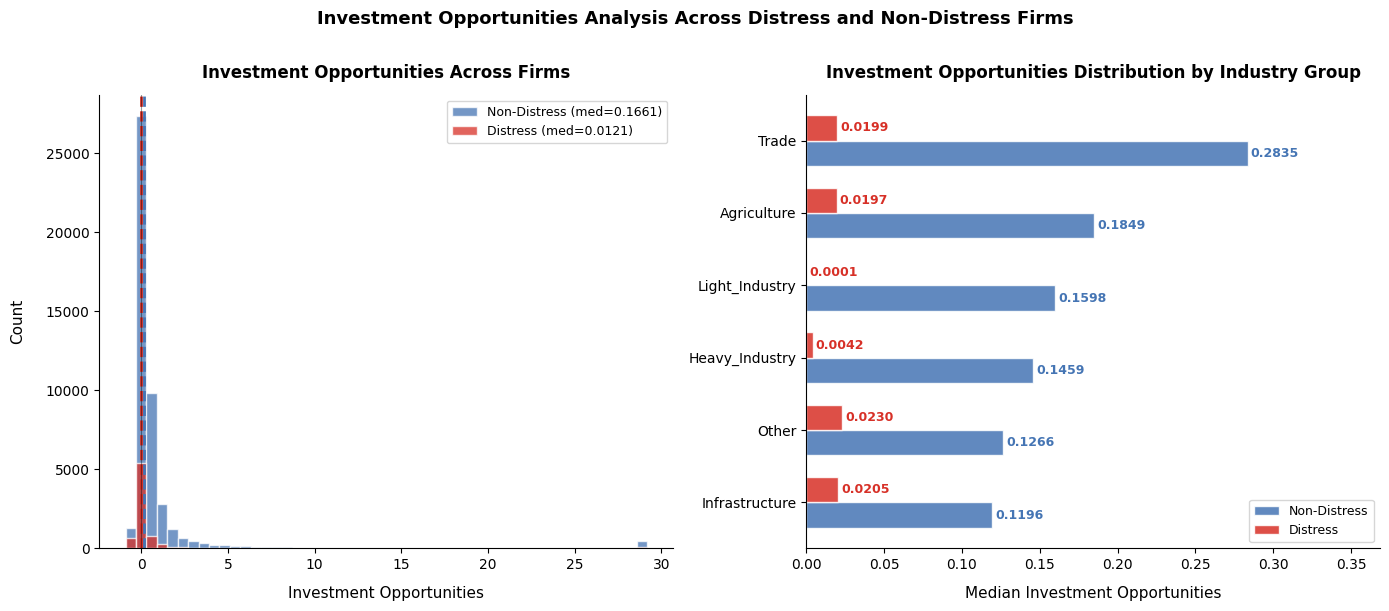

In [199]:
# ═══════════════════════════════════════════════════════════
# CELL · INVESTMENT OPPORTUNITIES — DISTRESS vs NON-DISTRESS
# ═══════════════════════════════════════════════════════════

from scipy import stats

colors_group = {0: '#4575b4', 1: '#d73027'}
labels_group = {0: 'Non-Distress', 1: 'Distress'}
colors_ind   = ['#1d3557', '#457b9d', '#a8dadc', '#e9c46a', '#f4a261', '#e76f51']
industries   = sorted(ana['Industry_Group'].dropna().unique())

# ── Statistics ──
print("=" * 65)
print("INVESTMENT OPPORTUNITIES ANALYSIS")
print("=" * 65)
print(f"\nTotal observations (df_clean)   : {len(df_clean):,}")
print(f"Valid IO observations (df_clean) : "
      f"{df_clean['Investment_Opportunities'].notna().sum():,}  "
      f"({df_clean['Investment_Opportunities'].notna().mean()*100:.1f}%)")
print(f"Valid IO observations (ana)      : "
      f"{ana['Investment_Opportunities'].notna().sum():,}  "
      f"({ana['Investment_Opportunities'].notna().mean()*100:.1f}%)")

print("\nMedian IO by Industry (df_clean):")
print(
    df_clean.groupby('Industry_Group')['Investment_Opportunities']
    .median().round(4)
    .sort_values(ascending=False)
    .to_string()
)

print("\nMedian IO by Year (df_clean):")
print(df_clean.groupby('Year')['Investment_Opportunities']
      .median().round(4).to_string())

d0 = ana[ana['Financial_Distress'] == 0]['Investment_Opportunities'].dropna()
d1 = ana[ana['Financial_Distress'] == 1]['Investment_Opportunities'].dropna()

stat_mw, p_val = stats.mannwhitneyu(d0, d1, alternative='two-sided')
effect         = abs(1 - (2 * stat_mw) / (len(d0) * len(d1)))

print(f"\nIO — Distress vs Non-Distress:")
print(f"  Median Non-Distress : {d0.median():.4f}")
print(f"  Median Distress     : {d1.median():.4f}")
print(f"  Difference          : {d1.median() - d0.median():+.4f}")
print(f"  Mann-Whitney p      : {p_val:.4f}")
print(f"  Effect size (r)     : {effect:.4f}  "
      f"{'large' if effect > 0.5 else 'medium' if effect > 0.3 else 'small'}")

# ── Plots ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Plot 3: Distribution distress vs non-distress ──
ax3 = axes[0]

for group in [0, 1]:
    data = ana[ana['Financial_Distress'] == group]['Investment_Opportunities'].dropna()
    ax3.hist(data, bins=50,
             color=colors_group[group], alpha=0.75,
             edgecolor='white',
             label=f"{labels_group[group]} (med={data.median():.4f})")
    ax3.axvline(data.median(), color=colors_group[group],
                linewidth=2, linestyle='--')

ax3.axvline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.4)
ax3.set_title('Investment Opportunities Across Firms',
              fontsize=12, fontweight='bold', pad=12)
ax3.set_xlabel('Investment Opportunities', fontsize=11, labelpad=10)
ax3.set_ylabel('Count', fontsize=11, labelpad=15)
ax3.legend(fontsize=9)
ax3.spines[['top', 'right']].set_visible(False)
ax3.grid(False)

# ── Plot 4: IO by industry distress vs non-distress ──
ax4 = axes[1]
ind_comp = (
    ana.groupby('Industry_Group')['Investment_Opportunities']
    .agg(
        Non_D    = lambda x: x[ana.loc[x.index, 'Financial_Distress'] == 0].median(),
        Distress = lambda x: x[ana.loc[x.index, 'Financial_Distress'] == 1].median()
    )
    .round(4)
    .sort_values('Non_D', ascending=True)
)

y     = np.arange(len(ind_comp))
width = 0.35

bars1 = ax4.barh(y - width/2, ind_comp['Non_D'],
                 height=width, color=colors_group[0],
                 edgecolor='white', alpha=0.85, label='Non-Distress')
bars2 = ax4.barh(y + width/2, ind_comp['Distress'],
                 height=width, color=colors_group[1],
                 edgecolor='white', alpha=0.85, label='Distress')

for bar, val in zip(bars1, ind_comp['Non_D']):
    ax4.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', ha='left', fontsize=9, color='#4575b4', fontweight='bold')
for bar, val in zip(bars2, ind_comp['Distress']):
    ax4.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', ha='left', fontsize=9, color='#d73027', fontweight='bold')
    


ax4.set_yticks(y)
ax4.set_yticklabels(ind_comp.index, fontsize=10)
ax4.set_title('Investment Opportunities Distribution by Industry Group',
              fontsize=12, fontweight='bold', pad=12)
ax4.set_xlabel('Median Investment Opportunities', fontsize=11, labelpad=10, )
ax4.set_xlim(0, ind_comp.max().max() * 1.3)
ax4.spines[['top', 'right']].set_visible(False)
ax4.legend(fontsize=9, loc='lower right')
ax4.grid(False)

fig.suptitle(
    'Investment Opportunities Analysis Across Distress and Non-Distress Firms',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

##### Size & Age

LOG(ASSETS) vs DISTRESS
Analytical sample: 70,351 observations

Log(Assets) — Distress vs Non-Distress:
  Median Non-Distress : 11.2123  (Assets = 74,035)
  Median Distress     : 10.2542  (Assets = 28,401)
  Difference          : -0.9581
  Mann-Whitney p      : 0.0000
  Effect size (r)     : 0.2052  small

Log(Assets) by Industry — Distress vs Non-Distress:
                 Median    Non_D  Distress  Assets_Non_D  Assets_Distress
Industry_Group                                                           
Trade           11.8066  11.8819   11.0457        144625            62673
Agriculture     11.6991  11.7320   11.3015        124492            80942
Light_Industry  11.3545  11.5297    9.9983        101691            21989
Infrastructure  11.2910  11.4319   10.6800         92217            43477
Heavy_Industry  11.2442  11.4505   10.2211         93948            27476
Other           10.1659  10.2633    9.3373         28661            11353

Distress rate by Size Quintile:
               

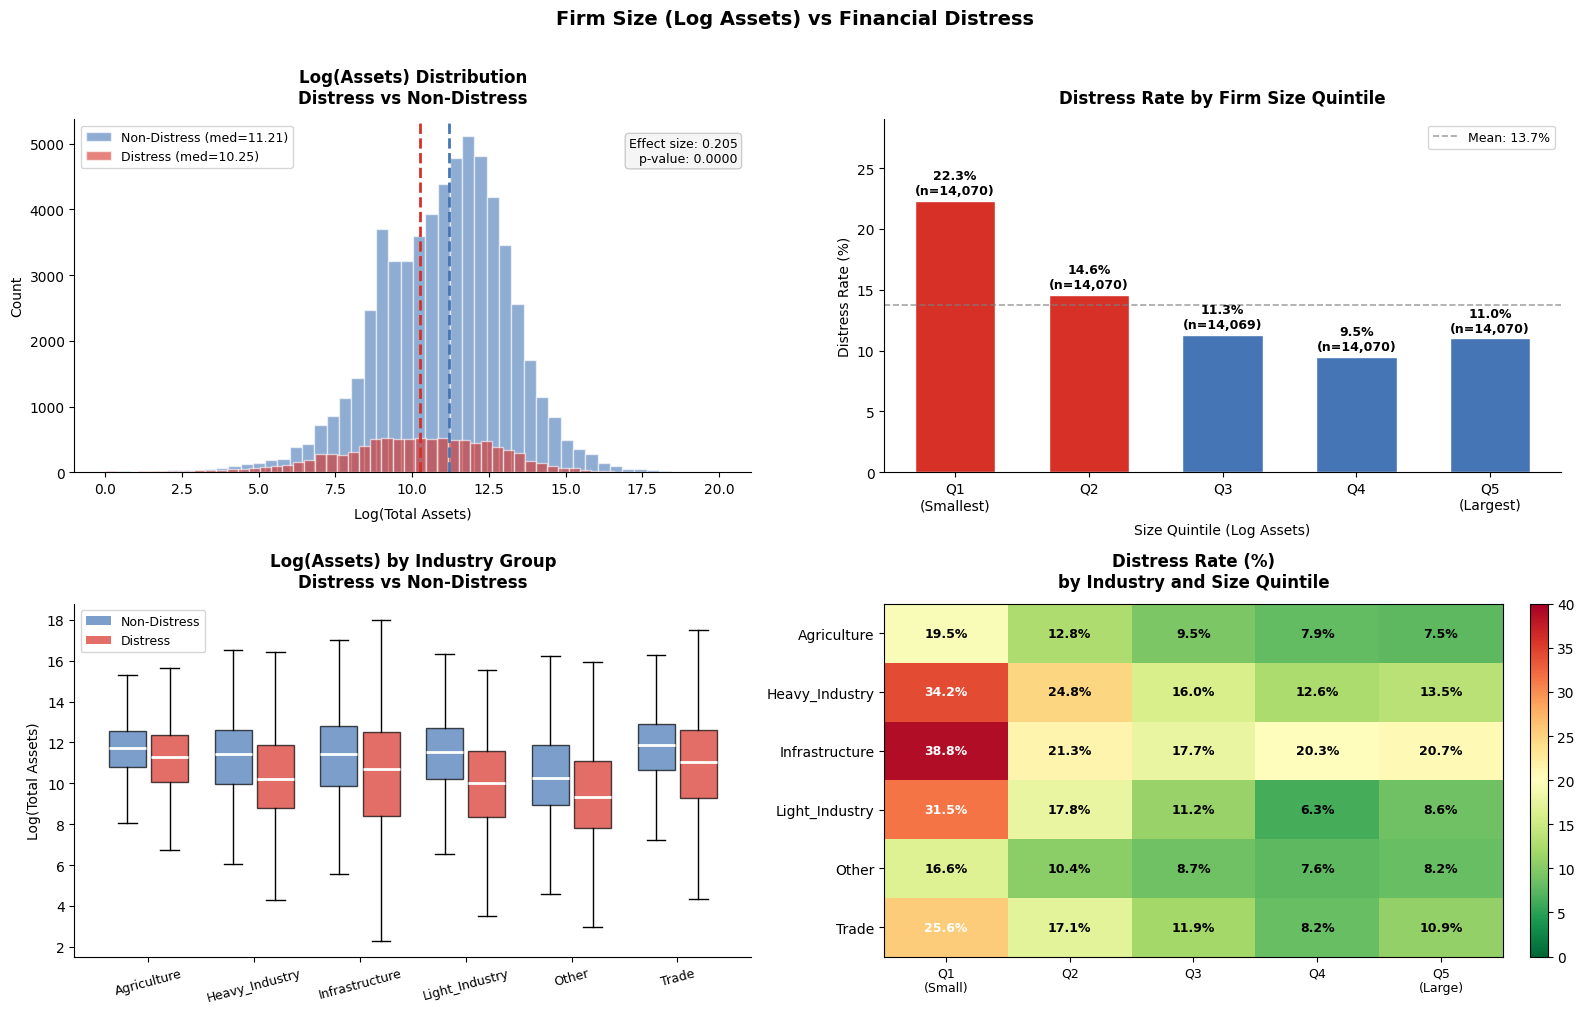

In [200]:
# ═══════════════════════════════════════════════════════════
# CELL · LOG(ASSETS) vs DISTRESS
# ═══════════════════════════════════════════════════════════

from scipy import stats
from matplotlib.patches import Patch

colors_group = {0: '#4575b4', 1: '#d73027'}
labels_group = {0: 'Non-Distress', 1: 'Distress'}
colors_ind   = ['#1d3557', '#457b9d', '#a8dadc', '#e9c46a', '#f4a261', '#e76f51']
industries   = sorted(ana['Industry_Group'].dropna().unique())

# ── Statistics ──
print("=" * 65)
print("LOG(ASSETS) vs DISTRESS")
print(f"Analytical sample: {len(ana):,} observations")
print("=" * 65)

d0 = ana[ana['Financial_Distress'] == 0]['Log_Assets'].dropna()
d1 = ana[ana['Financial_Distress'] == 1]['Log_Assets'].dropna()

stat_mw, p_val = stats.mannwhitneyu(d0, d1, alternative='two-sided')
effect         = abs(1 - (2 * stat_mw) / (len(d0) * len(d1)))

print(f"\nLog(Assets) — Distress vs Non-Distress:")
print(f"  Median Non-Distress : {d0.median():.4f}  "
      f"(Assets = {np.exp(d0.median()):,.0f})")
print(f"  Median Distress     : {d1.median():.4f}  "
      f"(Assets = {np.exp(d1.median()):,.0f})")
print(f"  Difference          : {d1.median() - d0.median():+.4f}")
print(f"  Mann-Whitney p      : {p_val:.4f}")
print(f"  Effect size (r)     : {effect:.4f}  "
      f"{'large' if effect > 0.5 else 'medium' if effect > 0.3 else 'small'}")

print("\nLog(Assets) by Industry — Distress vs Non-Distress:")
ind_size = (
    ana.groupby('Industry_Group')['Log_Assets']
    .agg(
        Median   = 'median',
        Non_D    = lambda x: x[ana.loc[x.index, 'Financial_Distress'] == 0].median(),
        Distress = lambda x: x[ana.loc[x.index, 'Financial_Distress'] == 1].median()
    )
    .round(4)
    .sort_values('Median', ascending=False)
)
ind_size['Assets_Non_D']    = np.exp(ind_size['Non_D']).astype(int)
ind_size['Assets_Distress'] = np.exp(ind_size['Distress']).astype(int)
print(ind_size.to_string())

print("\nDistress rate by Size Quintile:")
ana['Size_quintile'] = pd.qcut(
    ana['Log_Assets'],
    q=5,
    labels=['Q1\n(Smallest)', 'Q2', 'Q3', 'Q4', 'Q5\n(Largest)']
)
size_distress = (
    ana.groupby('Size_quintile', observed=True)['Financial_Distress']
    .agg(N='count', Distress_Rate='mean')
    .assign(Distress_Rate=lambda x: (x['Distress_Rate'] * 100).round(1))
)
print(size_distress.to_string())

# ── Plots ──
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── Plot 1: Distribution ──
ax1 = axes[0, 0]
for group in [0, 1]:
    data = ana[ana['Financial_Distress'] == group]['Log_Assets'].dropna()
    ax1.hist(data, bins=50,
             color=colors_group[group], alpha=0.6,
             edgecolor='white',
             label=f"{labels_group[group]} (med={data.median():.2f})")
    ax1.axvline(data.median(), color=colors_group[group],
                linewidth=2, linestyle='--')

ax1.set_title('Log(Assets) Distribution\nDistress vs Non-Distress',
              fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel('Log(Total Assets)', fontsize=10, labelpad=8)
ax1.set_ylabel('Count', fontsize=10)
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)
ax1.text(0.98, 0.95,
         f'Effect size: {effect:.3f}\np-value: {p_val:.4f}',
         transform=ax1.transAxes, ha='right', va='top',
         fontsize=9, bbox=dict(boxstyle='round', facecolor='#f5f5f5',
                               edgecolor='#cccccc'))
ax1.grid(False)

# ── Plot 2: Distress rate by size quintile ──
ax2 = axes[0, 1]
colors_q = ['#d73027' if v > size_distress['Distress_Rate'].mean()
            else '#4575b4' for v in size_distress['Distress_Rate']]

bars = ax2.bar(size_distress.index.tolist(),
               size_distress['Distress_Rate'],
               color=colors_q, edgecolor='white', width=0.6)

for bar, val, n in zip(bars,
                        size_distress['Distress_Rate'],
                        size_distress['N']):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}%\n(n={n:,})',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.axhline(y=size_distress['Distress_Rate'].mean(),
            color='gray', linestyle='--', linewidth=1.2, alpha=0.7,
            label=f'Mean: {size_distress["Distress_Rate"].mean():.1f}%')
ax2.set_title('Distress Rate by Firm Size Quintile',
              fontsize=12, fontweight='bold', pad=12)
ax2.set_ylabel('Distress Rate (%)', fontsize=10)
ax2.set_xlabel('Size Quintile (Log Assets)', fontsize=10, labelpad=8)
ax2.set_ylim(0, size_distress['Distress_Rate'].max() * 1.3)
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(fontsize=9)
ax2.grid(False)

# ── Plot 3: Boxplot by industry ──
ax3 = axes[1, 0]
positions_0 = np.arange(len(industries)) - 0.2
positions_1 = np.arange(len(industries)) + 0.2

data_0 = [ana[(ana['Industry_Group'] == ind) &
               (ana['Financial_Distress'] == 0)]['Log_Assets'].dropna()
           for ind in industries]
data_1 = [ana[(ana['Industry_Group'] == ind) &
               (ana['Financial_Distress'] == 1)]['Log_Assets'].dropna()
           for ind in industries]

bp0 = ax3.boxplot(data_0, positions=positions_0, widths=0.35,
                  patch_artist=True, showfliers=False,
                  medianprops=dict(color='white', linewidth=2))
bp1 = ax3.boxplot(data_1, positions=positions_1, widths=0.35,
                  patch_artist=True, showfliers=False,
                  medianprops=dict(color='white', linewidth=2))

for patch in bp0['boxes']:
    patch.set_facecolor(colors_group[0])
    patch.set_alpha(0.7)
for patch in bp1['boxes']:
    patch.set_facecolor(colors_group[1])
    patch.set_alpha(0.7)

ax3.set_xticks(np.arange(len(industries)))
ax3.set_xticklabels(industries, rotation=15, fontsize=9)
ax3.set_title('Log(Assets) by Industry Group\nDistress vs Non-Distress',
              fontsize=12, fontweight='bold', pad=12)
ax3.set_ylabel('Log(Total Assets)', fontsize=10)
ax3.spines[['top', 'right']].set_visible(False)
ax3.legend(handles=[
    Patch(facecolor=colors_group[0], alpha=0.7, label='Non-Distress'),
    Patch(facecolor=colors_group[1], alpha=0.7, label='Distress')
], fontsize=9)
ax3.grid(False)

# ── Plot 4: Heatmap by industry and size quintile ──
ax4 = axes[1, 1]
heatmap_data = (
    ana.groupby(['Industry_Group', 'Size_quintile'], observed=True)
    ['Financial_Distress']
    .mean()
    .mul(100)
    .round(1)
    .unstack('Size_quintile')
)

im = ax4.imshow(heatmap_data.values, cmap='RdYlGn_r',
                aspect='auto', vmin=0, vmax=40)

ax4.set_xticks(range(5))
ax4.set_yticks(range(len(heatmap_data)))
ax4.set_xticklabels(['Q1\n(Small)', 'Q2', 'Q3', 'Q4', 'Q5\n(Large)'], fontsize=9)
ax4.set_yticklabels(heatmap_data.index, fontsize=10)

for i in range(len(heatmap_data)):
    for j in range(5):
        val   = heatmap_data.values[i, j]
        color = 'white' if val > 25 else 'black'
        ax4.text(j, i, f'{val:.1f}%',
                 ha='center', va='center',
                 fontsize=9, fontweight='bold', color=color)

plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)
ax4.set_title('Distress Rate (%)\nby Industry and Size Quintile',
              fontsize=12, fontweight='bold', pad=12)

fig.suptitle('Firm Size (Log Assets) vs Financial Distress',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

FIRM AGE vs DISTRESS
Analytical sample: 70,351 observations

Firm Age distribution:
count    70351.0
mean        16.4
std          9.0
min          1.0
10%          4.0
25%          8.0
50%         17.0
75%         24.0
90%         28.0
max        103.0

Firm Age — Distress vs Non-Distress:
  Median Non-Distress : 17.0 years
  Median Distress     : 18.0 years
  Difference          : +1.0 years
  Mann-Whitney p      : 0.0001
  Effect size (r)     : 0.0247  small

Distress rate by Age Group:
                   N  Distress_Rate
Age_group                          
0-5\n(Young)   11315           12.5
6-10           10234           14.9
11-15           9067           13.7
16-20          13083           12.9
21-30          24551           14.3
30+\n(Mature)   2098           14.1

Survivor Bias Analysis — Firms per Age:
 Firm Age  N_Firms
        1     1246
        2     2132
        3     2524
        4     2744
        5     2669
        6     2418
        7     2194
        8     1994
     

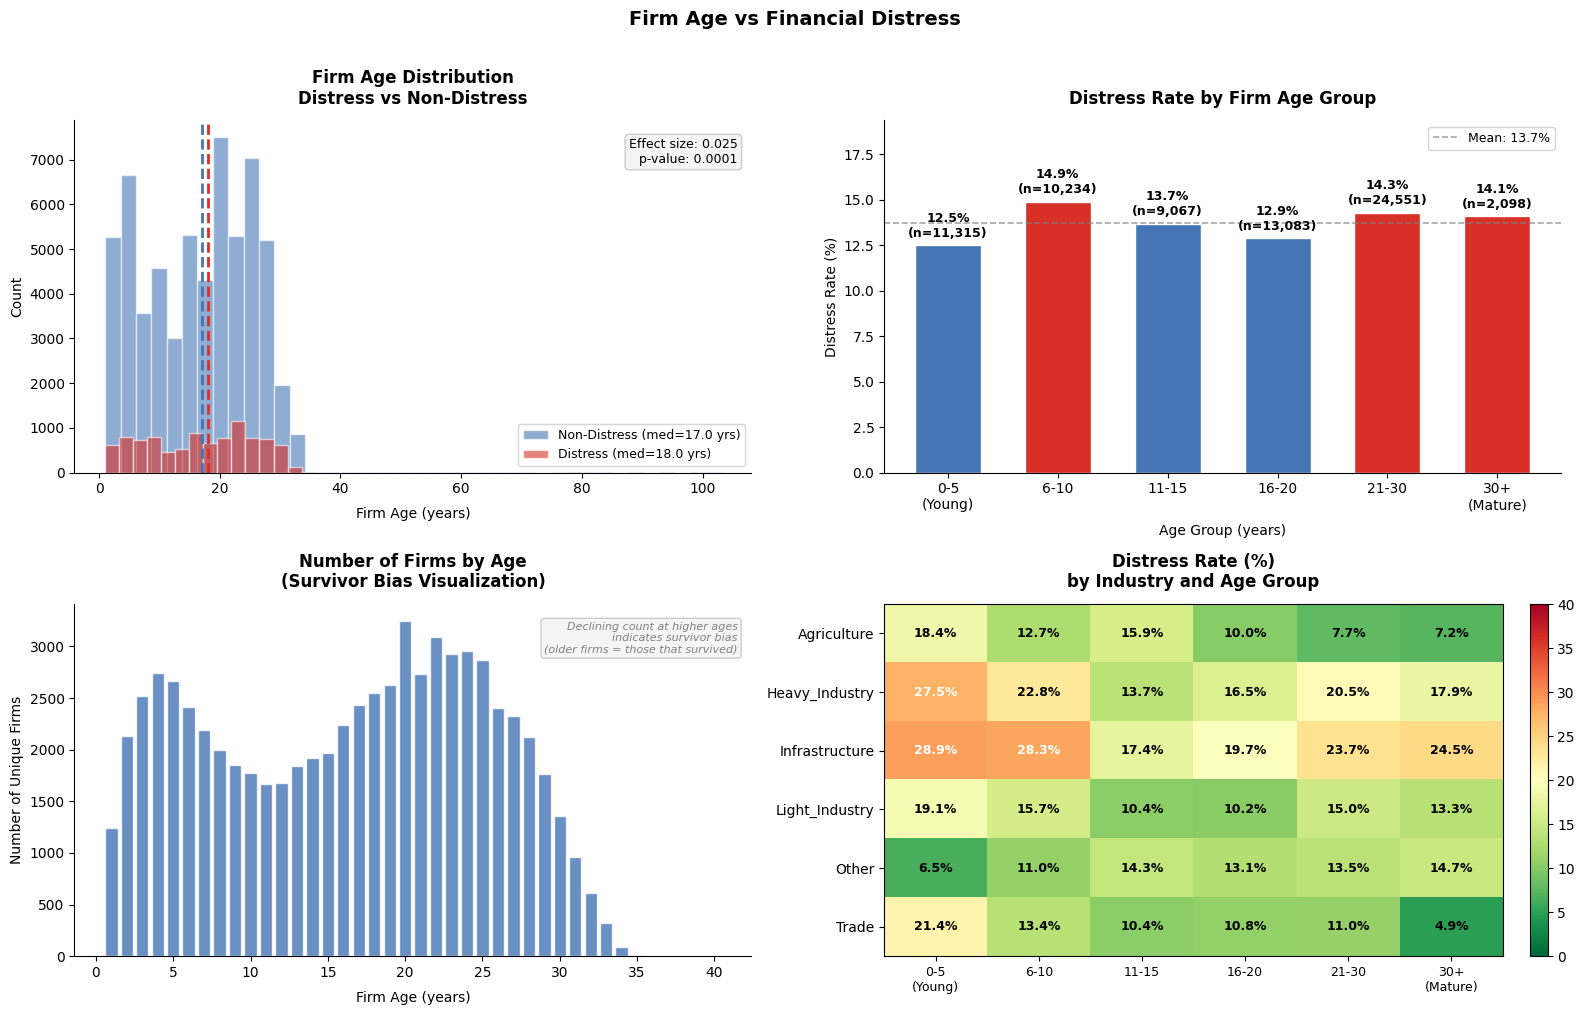

In [201]:
# ═══════════════════════════════════════════════════════════
# CELL · FIRM AGE vs DISTRESS
# ═══════════════════════════════════════════════════════════

from scipy import stats

colors_group = {0: '#4575b4', 1: '#d73027'}
labels_group = {0: 'Non-Distress', 1: 'Distress'}
industries   = sorted(ana['Industry_Group'].dropna().unique())

# ── Statistics ──
print("=" * 65)
print("FIRM AGE vs DISTRESS")
print(f"Analytical sample: {len(ana):,} observations")
print("=" * 65)

print(f"\nFirm Age distribution:")
print(ana['Firm Age'].describe(percentiles=[.1,.25,.5,.75,.9]).round(1).to_string())

d0 = ana[ana['Financial_Distress'] == 0]['Firm Age'].dropna()
d1 = ana[ana['Financial_Distress'] == 1]['Firm Age'].dropna()

stat_mw, p_val = stats.mannwhitneyu(d0, d1, alternative='two-sided')
effect         = abs(1 - (2 * stat_mw) / (len(d0) * len(d1)))

print(f"\nFirm Age — Distress vs Non-Distress:")
print(f"  Median Non-Distress : {d0.median():.1f} years")
print(f"  Median Distress     : {d1.median():.1f} years")
print(f"  Difference          : {d1.median() - d0.median():+.1f} years")
print(f"  Mann-Whitney p      : {p_val:.4f}")
print(f"  Effect size (r)     : {effect:.4f}  "
      f"{'large' if effect > 0.5 else 'medium' if effect > 0.3 else 'small'}")

# Age groups
ana['Age_group'] = pd.cut(
    ana['Firm Age'],
    bins=[0, 5, 10, 15, 20, 30, 100],
    labels=['0-5\n(Young)', '6-10', '11-15',
            '16-20', '21-30', '30+\n(Mature)']
)

age_distress = (
    ana.groupby('Age_group', observed=True)['Financial_Distress']
    .agg(N='count', Distress_Rate='mean')
    .assign(Distress_Rate=lambda x: (x['Distress_Rate'] * 100).round(1))
)

print("\nDistress rate by Age Group:")
print(age_distress.to_string())

print("\nSurvivor Bias Analysis — Firms per Age:")
cohort = (
    ana.groupby('Firm Age')['Firm ID']
    .nunique()
    .reset_index()
    .rename(columns={'Firm ID': 'N_Firms'})
    .sort_values('Firm Age')
)
print(cohort.head(20).to_string(index=False))

print("\nMedian Firm Age by Industry — Distress vs Non-Distress:")
ind_age = (
    ana.groupby('Industry_Group')['Firm Age']
    .agg(
        Median   = 'median',
        Non_D    = lambda x: x[ana.loc[x.index, 'Financial_Distress'] == 0].median(),
        Distress = lambda x: x[ana.loc[x.index, 'Financial_Distress'] == 1].median()
    )
    .round(1)
    .sort_values('Median', ascending=False)
)
print(ind_age.to_string())

# ── Plots ──
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── Plot 1: Distribution ──
ax1 = axes[0, 0]
for group in [0, 1]:
    data = ana[ana['Financial_Distress'] == group]['Firm Age'].dropna()
    ax1.hist(data, bins=40,
             color=colors_group[group], alpha=0.6,
             edgecolor='white',
             label=f"{labels_group[group]} (med={data.median():.1f} yrs)")
    ax1.axvline(data.median(), color=colors_group[group],
                linewidth=2, linestyle='--')

ax1.set_title('Firm Age Distribution\nDistress vs Non-Distress',
              fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel('Firm Age (years)', fontsize=10, labelpad=8)
ax1.set_ylabel('Count', fontsize=10)
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)
ax1.text(0.98, 0.95,
         f'Effect size: {effect:.3f}\np-value: {p_val:.4f}',
         transform=ax1.transAxes, ha='right', va='top',
         fontsize=9, bbox=dict(boxstyle='round', facecolor='#f5f5f5',
                               edgecolor='#cccccc'))
ax1.grid(False)

# ── Plot 2: Distress rate by age group ──
ax2 = axes[0, 1]
colors_age = ['#d73027' if v > age_distress['Distress_Rate'].mean()
              else '#4575b4' for v in age_distress['Distress_Rate']]

bars = ax2.bar(age_distress.index.tolist(),
               age_distress['Distress_Rate'],
               color=colors_age, edgecolor='white', width=0.6)

for bar, val, n in zip(bars,
                        age_distress['Distress_Rate'],
                        age_distress['N']):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}%\n(n={n:,})',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.axhline(y=age_distress['Distress_Rate'].mean(),
            color='gray', linestyle='--', linewidth=1.2, alpha=0.7,
            label=f'Mean: {age_distress["Distress_Rate"].mean():.1f}%')
ax2.set_title('Distress Rate by Firm Age Group',
              fontsize=12, fontweight='bold', pad=12)
ax2.set_ylabel('Distress Rate (%)', fontsize=10)
ax2.set_xlabel('Age Group (years)', fontsize=10, labelpad=8)
ax2.set_ylim(0, age_distress['Distress_Rate'].max() * 1.3)
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(fontsize=9)
ax2.grid(False)

# ── Plot 3: Survivor bias ──
ax3 = axes[1, 0]
cohort_plot = cohort[cohort['Firm Age'] <= 40]
ax3.bar(cohort_plot['Firm Age'], cohort_plot['N_Firms'],
        color='#4575b4', edgecolor='white', alpha=0.8, width=0.8)
ax3.set_title('Number of Firms by Age\n(Survivor Bias Visualization)',
              fontsize=12, fontweight='bold', pad=12)
ax3.set_xlabel('Firm Age (years)', fontsize=10, labelpad=8)
ax3.set_ylabel('Number of Unique Firms', fontsize=10)
ax3.spines[['top', 'right']].set_visible(False)
ax3.text(0.98, 0.95,
         'Declining count at higher ages\nindicates survivor bias\n'
         '(older firms = those that survived)',
         transform=ax3.transAxes, ha='right', va='top',
         fontsize=8, style='italic', color='gray',
         bbox=dict(boxstyle='round', facecolor='#f5f5f5', edgecolor='#cccccc'))
ax3.grid(False)

# ── Plot 4: Heatmap by industry and age group ──
ax4 = axes[1, 1]
heatmap_data = (
    ana.groupby(['Industry_Group', 'Age_group'], observed=True)
    ['Financial_Distress']
    .mean()
    .mul(100)
    .round(1)
    .unstack('Age_group')
)

im = ax4.imshow(heatmap_data.values, cmap='RdYlGn_r',
                aspect='auto', vmin=0, vmax=40)

ax4.set_xticks(range(len(heatmap_data.columns)))
ax4.set_yticks(range(len(heatmap_data)))
ax4.set_xticklabels(heatmap_data.columns.tolist(), fontsize=9)
ax4.set_yticklabels(heatmap_data.index, fontsize=10)

for i in range(len(heatmap_data)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        if not np.isnan(val):
            color = 'white' if val > 25 else 'black'
            ax4.text(j, i, f'{val:.1f}%',
                     ha='center', va='center',
                     fontsize=9, fontweight='bold', color=color)

plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)
ax4.set_title('Distress Rate (%)\nby Industry and Age Group',
              fontsize=12, fontweight='bold', pad=12)

fig.suptitle('Firm Age vs Financial Distress',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

##### Crisis 

SUBPERIOD ANALYSIS — 2019 vs 2020 vs 2022

Median values by subperiod (df_clean):
Period3                   Pre-Crisis\n(2019)  COVID-19\n(2020)  Full-Scale War\n(2022)
ROA                                   0.0155            0.0078                  0.0066
Current Ratio                         1.4536            1.3388                  1.6329
TL/Assets                             0.4584            0.5096                  0.4124
AP/Assets                             0.0493            0.0409                  0.0309
Asset Turnover                        0.8107            0.7645                  0.5154
Payables Turnover                     7.5116            5.7457                  4.9135
Interest Coverage                     2.4140            1.9871                  2.5208
Investment Opportunities              0.1597            0.1239                  0.0794

Change (%) vs Pre-crisis (2019):
                          COVID-19\n(2020)  Full-Scale War\n(2022)
ROA                               

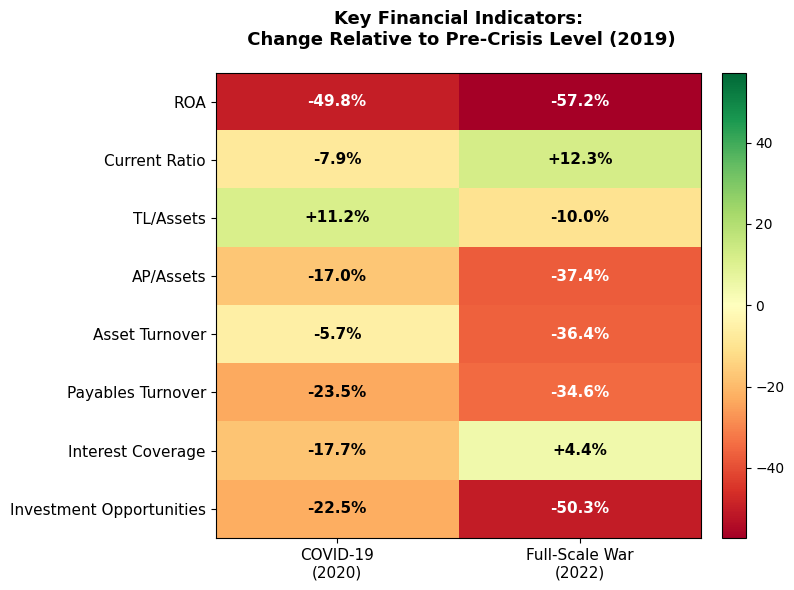

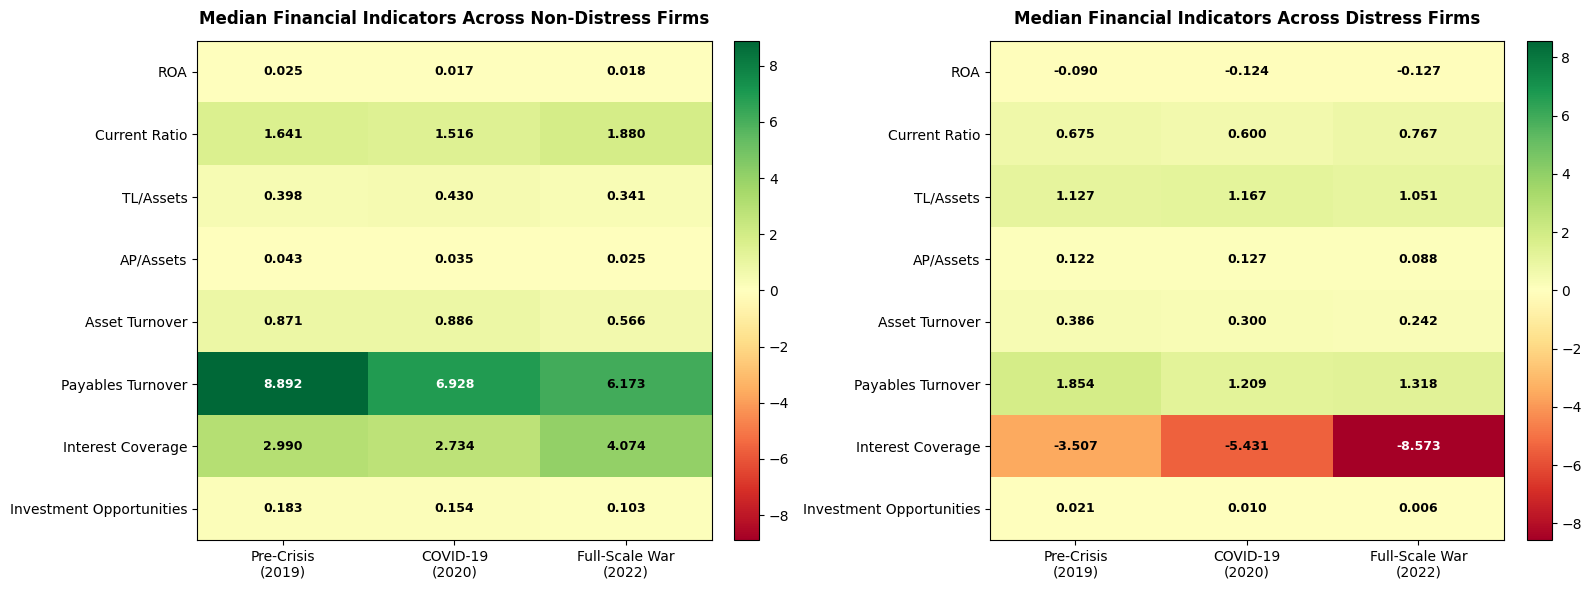

In [202]:
# ═══════════════════════════════════════════════════════════
# CELL · CRISIS HETEROGENEITY ANALYSIS
# ═══════════════════════════════════════════════════════════

colors_ind = ['#1d3557', '#457b9d', '#a8dadc', '#e9c46a', '#f4a261', '#e76f51']

# ── Subperiods ──
for d in [df_clean, ana]:
    d['Period'] = pd.cut(
        d['Year'],
        bins=[2018, 2019, 2020, 2022, 2024],
        labels=['Pre-Crisis\n(2019)', 'COVID-19\n(2020)', 'Full-Scale War\n(2022)', 'Post-war\n(2023-2024)']
    )

# Якщо хочеш тільки три: 2019, 2020, 2022
for d in [df_clean, ana]:
    d['Period3'] = np.where(
        d['Year'] == 2019, 'Pre-Crisis\n(2019)',
        np.where(d['Year'] == 2020, 'COVID-19\n(2020)',
        np.where(d['Year'] == 2022, 'Full-Scale War\n(2022)', None))
    )

# ── Indicators ──
indicators = {
    'ROA'            : 'ROA',
    'Current Ratio'    : 'Current_Ratio',
    'TL/Assets'      : 'TL_Assets',
    'AP/Assets': 'AP_Assets',
    'Asset Turnover' : 'Asset_Turnover',
    'Payables Turnover' : 'Payables_Turnover',
    'Interest Coverage': 'IC_Ratio',
    'Investment Opportunities' : 'Investment_Opportunities'
}
indicators = {k: v for k, v in indicators.items() if v in df_clean.columns}

# ── Statistics ──
print("=" * 65)
print("SUBPERIOD ANALYSIS — 2019 vs 2020 vs 2022")
print("=" * 65)

period_df = pd.DataFrame({
    name: df_clean[df_clean['Period3'].notna()]
    .groupby('Period3')[col].median()
    for name, col in indicators.items()
}).T

period_cols = ['Pre-Crisis\n(2019)', 'COVID-19\n(2020)', 'Full-Scale War\n(2022)']
period_df   = period_df.reindex(columns=period_cols)

print("\nMedian values by subperiod (df_clean):")
print(period_df.round(4).to_string())

changes_df = pd.DataFrame()
for col in ['COVID-19\n(2020)', 'Full-Scale War\n(2022)']:
    changes_df[col] = (
        (period_df[col] - period_df['Pre-Crisis\n(2019)']) /
        period_df['Pre-Crisis\n(2019)'].abs() * 100
    ).round(1)

print("\nChange (%) vs Pre-crisis (2019):")
print(changes_df.to_string())

print("\nDistress rate by subperiod (ana):")
distress_by_period = (
    ana[ana['Period3'].notna()]
    .groupby('Period3')['Financial_Distress']
    .agg(N='count', Rate='mean')
    .assign(Rate=lambda x: (x['Rate'] * 100).round(1))
    .reindex(period_cols)
)
print(distress_by_period.to_string())

print("\nNon-Distress — median by subperiod:")
nd_df = pd.DataFrame({
    name: ana[(ana['Financial_Distress'] == 0) & ana['Period3'].notna()]
    .groupby('Period3')[col].median()
    for name, col in indicators.items()
}).T.reindex(columns=period_cols)
print(nd_df.round(4).to_string())

print("\nDistress — median by subperiod:")
d_df = pd.DataFrame({
    name: ana[(ana['Financial_Distress'] == 1) & ana['Period3'].notna()]
    .groupby('Period3')[col].median()
    for name, col in indicators.items()
}).T.reindex(columns=period_cols)
print(d_df.round(4).to_string())

# ── Plot 1: Heatmap % changes ──
fig1, ax1 = plt.subplots(figsize=(8, 6))

change_data = changes_df.values.astype(float)
max_abs     = np.nanmax(np.abs(change_data))

im1 = ax1.imshow(change_data, cmap='RdYlGn', aspect='auto',
                 vmin=-max_abs, vmax=max_abs)

ax1.set_xticks(range(2))
ax1.set_yticks(range(len(changes_df)))
ax1.set_xticklabels(['COVID-19\n(2020)', 'Full-Scale War\n(2022)'], fontsize=11)
ax1.set_yticklabels(changes_df.index, fontsize=11)

for i in range(len(changes_df)):
    for j in range(2):
        val   = change_data[i, j]
        color = 'white' if abs(val) > max_abs * 0.6 else 'black'
        sign  = '+' if val > 0 else ''
        ax1.text(j, i, f'{sign}{val:.1f}%',
                 ha='center', va='center',
                 fontsize=11, fontweight='bold', color=color)

plt.colorbar(im1, ax=ax1, fraction=0.05, pad=0.04)
ax1.set_title('Key Financial Indicators:\n Change Relative to Pre-Crisis Level (2019)',
              fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ── Plot 3: Heatmap Non-D vs Distress ──
fig3, axes3 = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, title in zip(
    axes3,
    [nd_df, d_df],
    ['Median Financial Indicators Across Non-Distress Firms',
     'Median Financial Indicators Across Distress Firms']
):
    plot_vals = data.values.astype(float)
    abs_max   = np.nanmax(np.abs(plot_vals))
    im = ax.imshow(plot_vals, cmap='RdYlGn', aspect='auto',
                   vmin=-abs_max, vmax=abs_max)

    ax.set_xticks(range(3))
    ax.set_yticks(range(len(data)))
    ax.set_xticklabels(period_cols, fontsize=10)
    ax.set_yticklabels(data.index, fontsize=10)

    for i in range(len(data)):
        for j in range(3):
            val   = plot_vals[i, j]
            color = 'white' if abs(val) > abs_max * 0.7 else 'black'
            ax.text(j, i, f'{val:.3f}',
                    ha='center', va='center',
                    fontsize=9, fontweight='bold', color=color)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)


plt.tight_layout()
plt.show()

INDUSTRY REACTION TO CRISES

ROA:
Period3         Pre-Crisis\n(2019)  COVID-19\n(2020)  Full-Scale War\n(2022)  COVID vs Pre (%)  War vs Pre (%)
Industry_Group                                                                                                
Agriculture                 0.0347            0.0108                  0.0507             -68.9            46.1
Heavy_Industry              0.0290            0.0202                  0.0046             -30.3           -84.1
Infrastructure              0.0120            0.0030                  0.0006             -75.0           -95.0
Light_Industry              0.0237            0.0190                  0.0233             -19.8            -1.7
Other                       0.0026            0.0017                  0.0004             -34.6           -84.6
Trade                       0.0310            0.0249                  0.0233             -19.7           -24.8

Current Ratio:
Period3         Pre-Crisis\n(2019)  COVID-19\n(2020)  Full-Sca

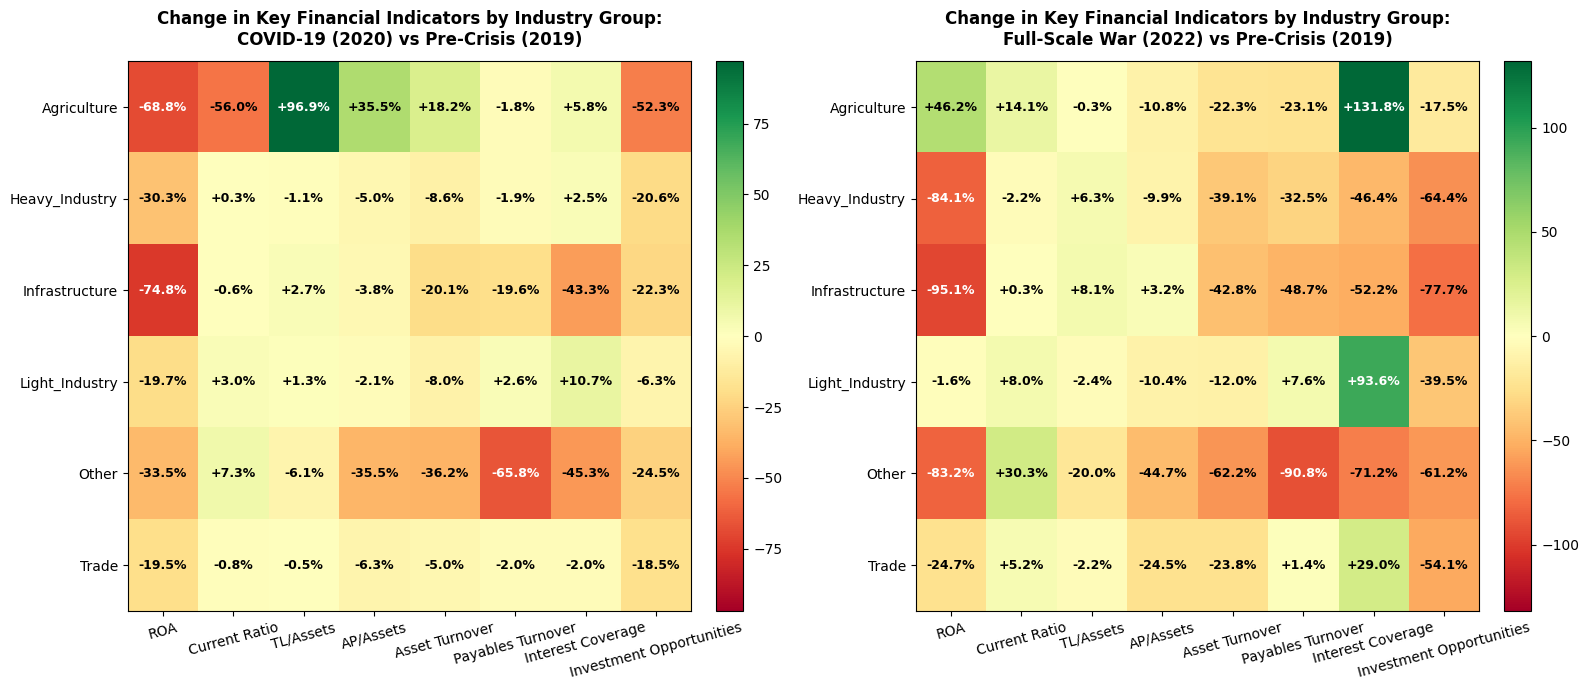

In [253]:
# ═══════════════════════════════════════════════════════════
# CELL · INDUSTRY REACTION TO CRISES
# ═══════════════════════════════════════════════════════════

colors_ind = ['#1d3557', '#457b9d', '#a8dadc', '#e9c46a', '#f4a261', '#e76f51']
industries = sorted(df_clean['Industry_Group'].dropna().unique())

indicators = {
    'ROA'            : 'ROA',
    'Current Ratio'    : 'Current_Ratio',
    'TL/Assets'      : 'TL_Assets',
    'AP/Assets': 'AP_Assets',
    'Asset Turnover' : 'Asset_Turnover',
    'Payables Turnover': 'Payables_Turnover',
    'Interest Coverage': 'IC_Ratio',
    'Investment Opportunities' : 'Investment_Opportunities',
}
indicators = {k: v for k, v in indicators.items() if v in df_clean.columns}

periods   = ['Pre-Crisis\n(2019)', 'COVID-19\n(2020)', 'Full-Scale War\n(2022)']
colors_p  = ['#52b788', '#f4a261', '#e76f51']

# ── Statistics ──
print("=" * 65)
print("INDUSTRY REACTION TO CRISES")
print("=" * 65)

for name, col in indicators.items():
    print(f"\n{name}:")
    pivot = (
        df_clean[df_clean['Period3'].notna()]
        .groupby(['Industry_Group', 'Period3'], observed=True)[col]
        .median()
        .unstack('Period3')
        .reindex(columns=periods)
        .round(4)
    )
    pivot['COVID vs Pre (%)'] = (
        (pivot['COVID-19\n(2020)'] - pivot['Pre-Crisis\n(2019)']) /
        pivot['Pre-Crisis\n(2019)'].abs() * 100
    ).round(1)
    pivot['War vs Pre (%)'] = (
        (pivot['Full-Scale War\n(2022)'] - pivot['Pre-Crisis\n(2019)']) /
        pivot['Pre-Crisis\n(2019)'].abs() * 100
    ).round(1)
    print(pivot.to_string())

print("\nDistress Rate by Industry and Subperiod:")
distress_pivot = (
    ana[ana['Period3'].notna()]
    .groupby(['Industry_Group', 'Period3'], observed=True)
    ['Financial_Distress'] 
    .mean()
    .mul(100)
    .round(1)
    .unstack('Period3')
    .reindex(columns=periods)
)
distress_pivot['COVID vs Pre (pp)'] = (
    distress_pivot['COVID-19\n(2020)'] - distress_pivot['Pre-Crisis\n(2019)']
).round(1)
distress_pivot['War vs Pre (pp)'] = (
    distress_pivot['Full-Scale War\n(2022)'] - distress_pivot['Pre-Crisis\n(2019)']
).round(1)
print(distress_pivot.to_string())

# ── Plot 1: Heatmap % changes by industry ──
fig1, axes1 = plt.subplots(1, 2, figsize=(16, 7))

for ax, period, title in zip(
    axes1,
    ['COVID-19\n(2020)', 'Full-Scale War\n(2022)'],
    ['COVID-19 (2020) vs Pre-Crisis (2019)', 'Full-Scale War (2022) vs Pre-Crisis (2019)']
):
    change_matrix = pd.DataFrame(index=industries, columns=list(indicators.keys()))
    for name, col in indicators.items():
        pre  = df_clean[df_clean['Period3'] == 'Pre-Crisis\n(2019)'] \
               .groupby('Industry_Group')[col].median()
        curr = df_clean[df_clean['Period3'] == period] \
               .groupby('Industry_Group')[col].median()
        change_matrix[name] = ((curr - pre) / pre.abs() * 100).round(1)

    change_data = change_matrix.values.astype(float)
    max_abs     = np.nanmax(np.abs(change_data))

    im = ax.imshow(change_data, cmap='RdYlGn', aspect='auto',
                   vmin=-max_abs, vmax=max_abs)

    ax.set_xticks(range(len(indicators)))
    ax.set_yticks(range(len(industries)))
    ax.set_xticklabels(list(indicators.keys()), fontsize=10, rotation=15)
    ax.set_yticklabels(industries, fontsize=10)

    for i in range(len(industries)):
        for j in range(len(indicators)):
            val   = change_data[i, j]
            color = 'white' if abs(val) > max_abs * 0.6 else 'black'
            sign  = '+' if val > 0 else ''
            ax.text(j, i, f'{sign}{val:.1f}%',
                    ha='center', va='center',
                    fontsize=9, fontweight='bold', color=color)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f'Change in Key Financial Indicators by Industry Group:\n{title}',
                 fontsize=12, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

### Modelling

## Різниця між групами

In [204]:
# ═══════════════════════════════════════════════════════════
# CELL · MANN-WHITNEY U TEST — DISTRESS VS NON-DISTRESS
# ═══════════════════════════════════════════════════════════
from scipy.stats import mannwhitneyu

test_vars = [
    # Profitability
    'ROA',
    'EBIT_Assets',
    'Gross_Margin',
    # Liquidity
    'WC_Assets',
    'Current_Ratio',
    'Quick_Ratio',
    # Leverage
    'TL_Assets',
    'LT_Liab_Assets',
    'ST_Liab_Assets',
    'AP_Assets',
    # Solvency
    'IC_Ratio',
    # Activity
    'Asset_Turnover',
    'Payables_Turnover',
    # Investment
    'Investment_Opportunities',
    # Size
    'Log_Assets',
    'Firm Age',
]

test_vars = [v for v in test_vars if v in ana.columns]

distress     = ana[ana['Financial_Distress'] == 1]
non_distress = ana[ana['Financial_Distress'] == 0]

rows = []
for var in test_vars:
    d  = distress[var].dropna()
    nd = non_distress[var].dropna()
    if len(d) < 10 or len(nd) < 10:
        continue

    stat, p = mannwhitneyu(d, nd, alternative='two-sided')

    # ── Effect size: rank-biserial correlation ──────────────
    r      = 1 - (2 * stat) / (len(d) * len(nd))
    r_abs  = abs(r)
    mag    = ('large'  if r_abs >= 0.5 else
              'medium' if r_abs >= 0.3 else
              'small'  if r_abs >= 0.1 else 'negligible')
    # ────────────────────────────────────────────────────────

    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))

    rows.append({
        'Variable'        : var,
        'Median Distress' : round(d.median(), 4),
        'Median Non-Dist' : round(nd.median(), 4),
        'Difference'      : round(d.median() - nd.median(), 4),
        'U-stat'          : round(stat, 0),
        'p-value'         : round(p, 4),
        'Sig'             : sig,
        'Effect r'        : round(r, 4),       # rank-biserial correlation
        'Magnitude'       : mag,
    })

mw_table = pd.DataFrame(rows).set_index('Variable')

print("MANN-WHITNEY U TEST — DISTRESS vs NON-DISTRESS")
print("=" * 80)
print(f"  N distress     : {len(distress):,}")
print(f"  N non-distress : {len(non_distress):,}")
print()
print(mw_table.to_string())
print()
print("*** p < 0.001  ** p < 0.01  * p < 0.05  ns = not significant")
print("Effect size |r|: ≥0.5 large | 0.3–0.5 medium | 0.1–0.3 small | <0.1 negligible")
print(f"\nSignificant variables (p < 0.05): "
      f"{(mw_table['p-value'] < 0.05).sum()} of {len(mw_table)}")

MANN-WHITNEY U TEST — DISTRESS vs NON-DISTRESS
  N distress     : 9,670
  N non-distress : 60,681

                          Median Distress  Median Non-Dist  Difference       U-stat  p-value  Sig  Effect r   Magnitude
Variable                                                                                                               
ROA                               -0.1009           0.0253     -0.1263   68803423.0   0.0000  ***    0.7654       large
EBIT_Assets                       -0.1020           0.0332     -0.1353   63435385.0   0.0000  ***    0.7837       large
Gross_Margin                       0.1011           0.2000     -0.0989  161030062.0   0.0000  ***    0.2244       small
WC_Assets                         -0.3271           0.2419     -0.5690  130385526.0   0.0000  ***    0.5556       large
Current_Ratio                      0.6389           1.7860     -1.1471  134367928.0   0.0000  ***    0.5274       large
Quick_Ratio                        0.4047           1.1423   

## Лаги

In [205]:
lag_vars = [
    'ROA', 'EBIT_Assets',
    'WC_Assets', 'Current_Ratio',
    'TL_Assets', 'ST_Liab_Assets', 'AP_Assets',
    'Asset_Turnover', 'Payables_Turnover', 'Investment_Opportunities', 'IC_Ratio',
    'Log_Assets', 'Has_Debt',
]

lag_vars = [v for v in lag_vars if v in df_clean.columns]

for var in lag_vars:
    df_clean[f'{var}_lag'] = df_clean.groupby('Firm ID')[var].shift(1)

# ── Summary ──
lag_cols = [f'{v}_lag' for v in lag_vars]

print("LAGGED VARIABLES — AVAILABILITY")
print("=" * 55)
print(f"{'Variable':<30} {'N present':>10}  {'N missing':>10}")
print("-" * 55)
for col in lag_cols:
    n_present = df_clean[col].notna().sum()
    n_missing = df_clean[col].isna().sum()
    print(f"{col:<30} {n_present:>10,}  {n_missing:>10,}")

LAGGED VARIABLES — AVAILABILITY
Variable                        N present   N missing
-------------------------------------------------------
ROA_lag                            63,075      18,194
EBIT_Assets_lag                    63,075      18,194
WC_Assets_lag                      63,084      18,185
Current_Ratio_lag                  62,065      19,204
TL_Assets_lag                      63,084      18,185
ST_Liab_Assets_lag                 63,084      18,185
AP_Assets_lag                      63,084      18,185
Asset_Turnover_lag                 63,054      18,215
Payables_Turnover_lag              54,962      26,307
Investment_Opportunities_lag       38,708      42,561
IC_Ratio_lag                       25,577      55,692
Log_Assets_lag                     63,084      18,185
Has_Debt_lag                       63,086      18,183


## Кореляція з залежною

In [206]:
from scipy.stats import pointbiserialr

# Аналітична вибірка — 2019–2024 де є Financial_Distress
ana = df_clean[df_clean['Financial_Distress'].notna()].copy()

lag_cols = [
    'ROA_lag', 'EBIT_Assets_lag',
    'WC_Assets_lag', 'Current_Ratio_lag',
    'TL_Assets_lag', 'ST_Liab_Assets_lag',
    'AP_Assets_lag', 'Payables_Turnover_lag', 'Asset_Turnover_lag', 
    'Investment_Opportunities_lag', 'IC_Ratio_lag', 'Log_Assets_lag', 'Has_Debt_lag', 'Firm Age'
]
lag_cols = [c for c in lag_cols if c in ana.columns]

# ── 1. Point-Biserial: кожен предиктор vs Financial_Distress ──
print("POINT-BISERIAL CORRELATION — Predictors vs Financial_Distress")
print("=" * 60)
print(f"{'Variable':<35} {'r':>8}  {'p-value':>10}  {'Sig':>5}")
print("-" * 60)

for col in lag_cols:
    tmp = ana[['Financial_Distress', col]].dropna()
    r, p = pointbiserialr(tmp['Financial_Distress'], tmp[col])
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f"{col:<35} {r:>8.3f}  {p:>10.4f}  {sig:>5}")

POINT-BISERIAL CORRELATION — Predictors vs Financial_Distress
Variable                                   r     p-value    Sig
------------------------------------------------------------
ROA_lag                               -0.265      0.0000    ***
EBIT_Assets_lag                       -0.263      0.0000    ***
WC_Assets_lag                         -0.356      0.0000    ***
Current_Ratio_lag                     -0.087      0.0000    ***
TL_Assets_lag                          0.375      0.0000    ***
ST_Liab_Assets_lag                     0.367      0.0000    ***
AP_Assets_lag                          0.236      0.0000    ***
Payables_Turnover_lag                 -0.062      0.0000    ***
Asset_Turnover_lag                    -0.009      0.0298      *
Investment_Opportunities_lag          -0.006      0.2225     ns
IC_Ratio_lag                          -0.107      0.0000    ***
Log_Assets_lag                        -0.110      0.0000    ***
Has_Debt_lag                          -0.073 

## Кореляція між собою


HIGH CORRELATION PAIRS (|r| > 0.65)
  ROA_lag                        × EBIT_Assets_lag                r = 0.843
  ROA_lag                        × IC_Ratio_lag                   r = 0.752
  EBIT_Assets_lag                × IC_Ratio_lag                   r = 0.738
  WC_Assets_lag                  × Current_Ratio_lag              r = 0.920
  WC_Assets_lag                  × TL_Assets_lag                  r = -0.671
  WC_Assets_lag                  × ST_Liab_Assets_lag             r = -0.684
  Current_Ratio_lag              × TL_Assets_lag                  r = -0.778
  Current_Ratio_lag              × ST_Liab_Assets_lag             r = -0.814
  TL_Assets_lag                  × ST_Liab_Assets_lag             r = 0.936


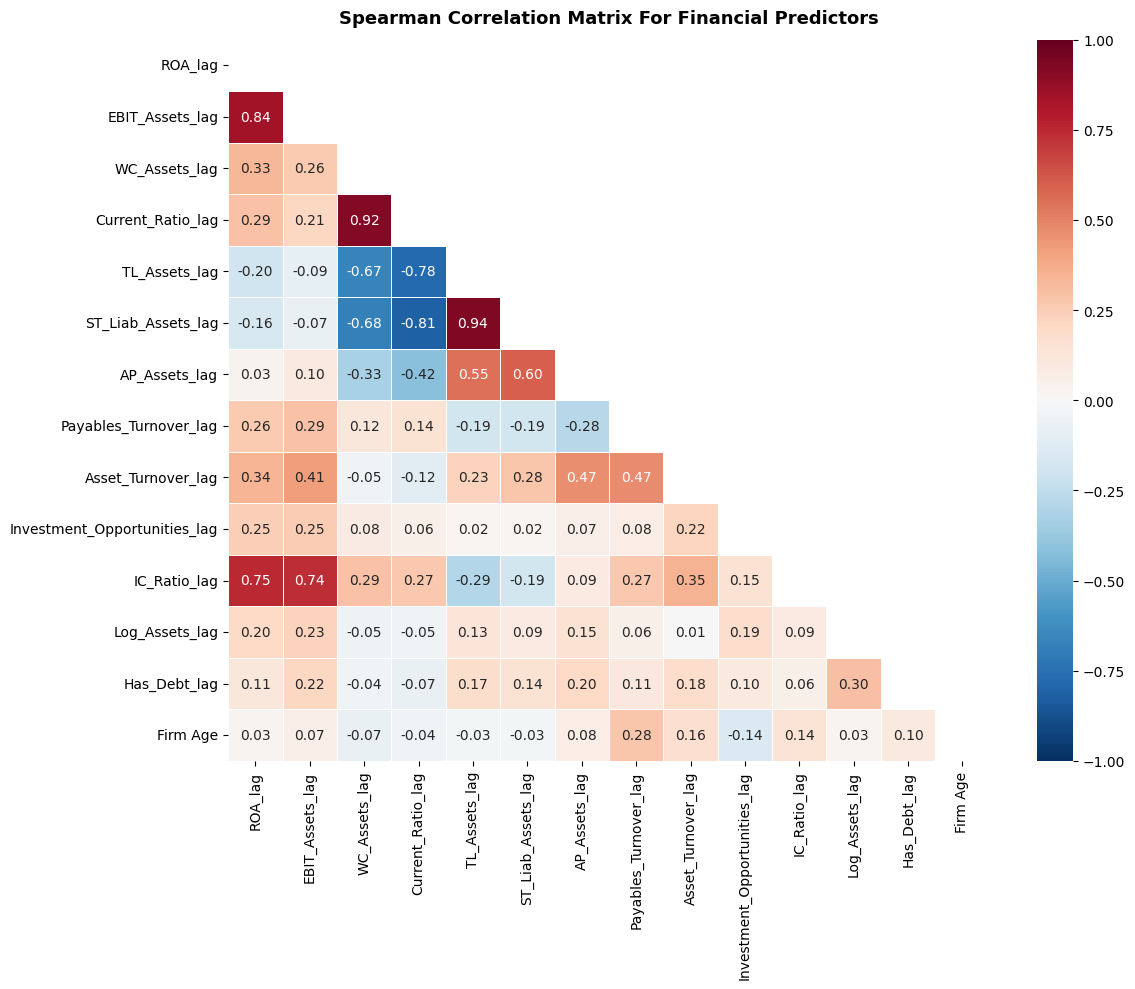

In [254]:
import seaborn as sns

# Додай Firm_Age до списку якщо ще не там
cols_for_corr = lag_cols + ['Firm Age'] if 'Firm Age' not in lag_cols else lag_cols

corr_matrix = ana[cols_for_corr].corr(method='spearman')


# Automatic flag |r| > 0.65
print("\nHIGH CORRELATION PAIRS (|r| > 0.65)")
print("=" * 55)
found = False
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.65:
            print(f"  {corr_matrix.columns[i]:<30} × "
                  f"{corr_matrix.columns[j]:<30} r = {r:.3f}")
            found = True
if not found:
    print("  No high correlation pairs found")

# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Spearman Correlation Matrix For Financial Predictors',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

In [208]:
# ═══════════════════════════════════════════════════════════
# CELL · PREPARE ANALYTICAL SAMPLE FOR MODELLING
# ═══════════════════════════════════════════════════════════

import statsmodels.api as sm

# Analytical sample: 2019–2024, Financial_Distress not NaN
ana = df_clean[df_clean['Financial_Distress'].notna()].copy()

# Crisis dummies
ana['covid_dummy'] = (ana['Year'] == 2020).astype(int)
ana['war_dummy']   = (ana['Year'] == 2022).astype(int)



# Industry dummies — Other as base category
industry_dummies = pd.get_dummies(
    ana['Industry_Group'], prefix='ind', drop_first=False
).astype(int)
industry_dummies = industry_dummies.drop(columns=['ind_Other'])
ana = pd.concat([ana, industry_dummies], axis=1)

ind_cols = industry_dummies.columns.tolist()

print(f"Analytical sample : {len(ana):,} obs")
print(f"Unique firms      : {ana['Firm ID'].nunique():,}")
print(f"Distress rate     : {ana['Financial_Distress'].mean() * 100:.1f}%")
print(f"Industry dummies  : {ind_cols}")

Analytical sample : 70,351 obs
Unique firms      : 18,183
Distress rate     : 13.7%
Industry dummies  : ['ind_Agriculture', 'ind_Heavy_Industry', 'ind_Infrastructure', 'ind_Light_Industry', 'ind_Trade']


In [209]:
# ═══════════════════════════════════════════════════════════
# CELL · LOGIT FUNCTION
# ═══════════════════════════════════════════════════════════

def run_logit(data, predictors, dv='Financial_Distress',
              cluster_var='Firm ID'):
    tmp = data[predictors + [dv, cluster_var]].dropna().copy()
    X   = sm.add_constant(tmp[predictors])
    y   = tmp[dv]
    grp = tmp[cluster_var]

    model = sm.Logit(y, X).fit(
        cov_type='cluster',
        cov_kwds={'groups': grp},
        maxiter=200,
        disp=False
    )
    return model, len(tmp)

results = {}

In [210]:
# ═══════════════════════════════════════════════════════════
# CELL · VIF FUNCTION
# ═══════════════════════════════════════════════════════════

from statsmodels.stats.outliers_influence import variance_inflation_factor

def check_vif(data, predictors):
    tmp = data[predictors].dropna().copy()
    X   = sm.add_constant(tmp)
    
    vif = pd.DataFrame({
        'Variable' : X.columns,
        'VIF'      : [variance_inflation_factor(X.values, i)
                      for i in range(X.shape[1])]
    })
    vif = vif[vif['Variable'] != 'const'].reset_index(drop=True)
    vif['Status'] = vif['VIF'].apply(
        lambda x: '✓ ok' if x < 5 else ('⚠ moderate' if x < 10 else '✗ high')
    )
    
    print(f"{'Variable':<35} {'VIF':>8}  {'Status':>12}")
    print("-" * 58)
    for _, row in vif.iterrows():
        print(f"{row['Variable']:<35} {row['VIF']:>8.2f}  {row['Status']:>12}")
    
    n_high = (vif['VIF'] >= 10).sum()
    if n_high > 0:
        print(f"\n⚠  {n_high} variable(s) with VIF >= 10 → multicollinearity problem")
    else:
        print(f"\n✓ No multicollinearity issues detected")
    
    return vif

In [211]:
def print_ame(model, model_name='Model'):
    try:
        ame = model.get_margeff(at='overall')

        print(f"\nAVERAGE MARGINAL EFFECTS — {model_name}")
        print("=" * 65)
        print(f"{'Variable':<30} {'AME (pp)':>10}  {'Std Err':>10}  "
              f"{'p-value':>10}  {'Sig':>5}")
        print("-" * 65)

        # Беремо імена змінних з model.params (без const)
        var_names = [v for v in model.params.index if v != 'const']

        for i, var in enumerate(var_names):
            me  = ame.margeff[i]  * 100
            se  = ame.margeff_se[i] * 100
            p   = ame.pvalues[i]
            sig = ('***' if p < 0.001 else
                   '**'  if p < 0.01  else
                   '*'   if p < 0.05  else 'ns')
            print(f"{var:<30} {me:>9.3f}pp  {se:>9.3f}pp  "
                  f"{p:>10.4f}  {sig:>5}")

        print()
        print("AME = change in P(distress) in pp for 1-unit increase")

    except Exception as e:
        print(f"AME failed: {e}")

In [212]:
# ═══════════════════════════════════════════════════════════
# CELL · M1 — BASELINE
# ═══════════════════════════════════════════════════════════

m1_vars = ['ROA_lag', 'TL_Assets_lag', 'Asset_Turnover_lag']

# ── VIF Check ──
print("VIF CHECK — M1")
print("=" * 58)
check_vif(ana, m1_vars)
print()

VIF CHECK — M1
Variable                                 VIF        Status
----------------------------------------------------------
ROA_lag                                 1.23          ✓ ok
TL_Assets_lag                           1.23          ✓ ok
Asset_Turnover_lag                      1.02          ✓ ok

✓ No multicollinearity issues detected



In [213]:
# ── Run model ──
m1, n1 = run_logit(ana, m1_vars)
results['M1_Baseline'] = {'model': m1, 'n': n1}
print(f"\nN = {n1:,} | Pseudo R² = {m1.prsquared:.4f} | AIC = {m1.aic:.1f}")
print()
print(m1.summary2())
print()
print_ame(m1, 'M1_Baseline')


N = 63,049 | Pseudo R² = 0.1427 | AIC = 44697.0

                          Results: Logit
Model:              Logit              Method:           MLE       
Dependent Variable: Financial_Distress Pseudo R-squared: 0.143     
Date:               2026-04-29 00:07   AIC:              44696.9961
No. Observations:   63049              BIC:              44733.2028
Df Model:           3                  Log-Likelihood:   -22344.   
Df Residuals:       63045              LL-Null:          -26064.   
Converged:          1.0000             LLR p-value:      0.0000    
No. Iterations:     7.0000             Scale:            1.0000    
-------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------
const              -2.3725   0.0322 -73.7032 0.0000 -2.4356 -2.3094
ROA_lag            -1.4178   0.0656 -21.6000 0.0000 -1.5464 -1.2891
TL_Assets_lag       0.835

In [214]:
m2_vars = ['ROA_lag', 'WC_Assets_lag',
           'TL_Assets_lag', 'Asset_Turnover_lag']

# ── VIF Check ──
print("VIF CHECK — M2")
print("=" * 58)
check_vif(ana, m2_vars)
print()

VIF CHECK — M2
Variable                                 VIF        Status
----------------------------------------------------------
ROA_lag                                 1.24          ✓ ok
WC_Assets_lag                           5.34    ⚠ moderate
TL_Assets_lag                           5.41    ⚠ moderate
Asset_Turnover_lag                      1.02          ✓ ok

✓ No multicollinearity issues detected



In [215]:
# ═══════════════════════════════════════════════════════════
# CELL · M2 — LIQUIDITY
# ═══════════════════════════════════════════════════════════

m2, n2 = run_logit(ana, m2_vars)
results['M2_Liq'] = {'model': m2, 'n': n2}
print(f"\nN = {n2:,} | Pseudo R² = {m2.prsquared:.4f} | AIC = {m2.aic:.1f}")
print()
print(m2.summary2())
print()
print_ame(m2, 'M2_Liq')


N = 63,049 | Pseudo R² = 0.1437 | AIC = 44649.9

                          Results: Logit
Model:              Logit              Method:           MLE       
Dependent Variable: Financial_Distress Pseudo R-squared: 0.144     
Date:               2026-04-29 00:07   AIC:              44649.8987
No. Observations:   63049              BIC:              44695.1571
Df Model:           4                  Log-Likelihood:   -22320.   
Df Residuals:       63044              LL-Null:          -26064.   
Converged:          1.0000             LLR p-value:      0.0000    
No. Iterations:     7.0000             Scale:            1.0000    
-------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------
const              -2.2425   0.0400 -55.9955 0.0000 -2.3210 -2.1640
ROA_lag            -1.3897   0.0662 -21.0011 0.0000 -1.5194 -1.2600
WC_Assets_lag      -0.225

In [216]:
m3_vars = ['ROA_lag', 'WC_Assets_lag',
           'TL_Assets_lag', 'Asset_Turnover_lag', 
           'AP_Assets_lag']

# ── VIF Check ──
print("VIF CHECK — M3")
print("=" * 58)
check_vif(ana, m3_vars)
print()

VIF CHECK — M3
Variable                                 VIF        Status
----------------------------------------------------------
ROA_lag                                 1.24          ✓ ok
WC_Assets_lag                           5.36    ⚠ moderate
TL_Assets_lag                           5.59    ⚠ moderate
Asset_Turnover_lag                      1.08          ✓ ok
AP_Assets_lag                           1.37          ✓ ok

✓ No multicollinearity issues detected



In [217]:
# ═══════════════════════════════════════════════════════════
# CELL · M3 — TRADE CREDIT
# ═══════════════════════════════════════════════════════════

m3, n3 = run_logit(ana, m3_vars)
results['M3_TradeCred'] = {'model': m3, 'n': n3}
print(f"\nN = {n3:,} | Pseudo R² = {m3.prsquared:.4f} | AIC = {m3.aic:.1f}")
print()
print(m3.summary2())
print()
print_ame(m3, 'M3_TradeCred')


N = 63,049 | Pseudo R² = 0.1491 | AIC = 44367.0

                          Results: Logit
Model:              Logit              Method:           MLE       
Dependent Variable: Financial_Distress Pseudo R-squared: 0.149     
Date:               2026-04-29 00:07   AIC:              44366.9600
No. Observations:   63049              BIC:              44421.2700
Df Model:           5                  Log-Likelihood:   -22177.   
Df Residuals:       63043              LL-Null:          -26064.   
Converged:          1.0000             LLR p-value:      0.0000    
No. Iterations:     7.0000             Scale:            1.0000    
-------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------
const              -2.2818   0.0371 -61.4535 0.0000 -2.3546 -2.2090
ROA_lag            -1.3863   0.0653 -21.2180 0.0000 -1.5143 -1.2582
WC_Assets_lag      -0.192

In [218]:
m4_vars = ['ROA_lag', 'WC_Assets_lag',
           'TL_Assets_lag', 'Asset_Turnover_lag', 
           'AP_Assets_lag', 'Has_Debt_lag']

# ── VIF Check ──
print("VIF CHECK — M4")
print("=" * 58)
check_vif(ana, m4_vars)
print()


VIF CHECK — M4
Variable                                 VIF        Status
----------------------------------------------------------
ROA_lag                                 1.24          ✓ ok
WC_Assets_lag                           5.39    ⚠ moderate
TL_Assets_lag                           5.63    ⚠ moderate
Asset_Turnover_lag                      1.08          ✓ ok
AP_Assets_lag                           1.37          ✓ ok
Has_Debt_lag                            1.01          ✓ ok

✓ No multicollinearity issues detected



In [219]:
# ═══════════════════════════════════════════════════════════
# CELL · M4 — CREDIT ACCESS
# ═══════════════════════════════════════════════════════════

m4, n4 = run_logit(ana, m4_vars)
results['M4_CredAccess'] = {'model': m4, 'n': n4}
print(f"\nN = {n4:,} | Pseudo R² = {m4.prsquared:.4f} | AIC = {m4.aic:.1f}")
print()
print(m4.summary2())
print()
print_ame(m4, 'M4_CredAccess')


N = 63,049 | Pseudo R² = 0.1553 | AIC = 44046.9

                          Results: Logit
Model:              Logit              Method:           MLE       
Dependent Variable: Financial_Distress Pseudo R-squared: 0.155     
Date:               2026-04-29 00:07   AIC:              44046.9305
No. Observations:   63049              BIC:              44110.2922
Df Model:           6                  Log-Likelihood:   -22016.   
Df Residuals:       63042              LL-Null:          -26064.   
Converged:          1.0000             LLR p-value:      0.0000    
No. Iterations:     7.0000             Scale:            1.0000    
-------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------
const              -2.2089   0.0379 -58.2459 0.0000 -2.2832 -2.1345
ROA_lag            -1.3264   0.0652 -20.3375 0.0000 -1.4543 -1.1986
WC_Assets_lag      -0.148

In [220]:
m5_vars = ['ROA_lag', 'WC_Assets_lag',
           'TL_Assets_lag', 'Asset_Turnover_lag', 
           'AP_Assets_lag', 'Has_Debt_lag', 'Log_Assets_lag', 'Firm Age']

# ── VIF Check ──
print("VIF CHECK — M5")
print("=" * 58)
check_vif(ana, m5_vars)
print()

VIF CHECK — M5
Variable                                 VIF        Status
----------------------------------------------------------
ROA_lag                                 1.30          ✓ ok
WC_Assets_lag                           5.55    ⚠ moderate
TL_Assets_lag                           5.75    ⚠ moderate
Asset_Turnover_lag                      1.14          ✓ ok
AP_Assets_lag                           1.39          ✓ ok
Has_Debt_lag                            1.12          ✓ ok
Log_Assets_lag                          1.22          ✓ ok
Firm Age                                1.04          ✓ ok

✓ No multicollinearity issues detected



In [221]:
# ═══════════════════════════════════════════════════════════
# CELL · M5 — SIZE AND AGE
# ═══════════════════════════════════════════════════════════

m5_vars = ['ROA_lag', 'WC_Assets_lag',
           'TL_Assets_lag', 'Asset_Turnover_lag', 
           'AP_Assets_lag', 'Has_Debt_lag', 'Log_Assets_lag', 'Firm Age']

m5, n5 = run_logit(ana, m5_vars)
results['M5_SizeAge'] = {'model': m5, 'n': n5}
print(f"\nN = {n5:,} | Pseudo R² = {m5.prsquared:.4f} | AIC = {m5.aic:.1f}")
print()
print(m5.summary2())
print()
print_ame(m5, 'M5_SizeAge')


N = 63,049 | Pseudo R² = 0.1564 | AIC = 43995.3

                          Results: Logit
Model:              Logit              Method:           MLE       
Dependent Variable: Financial_Distress Pseudo R-squared: 0.156     
Date:               2026-04-29 00:07   AIC:              43995.2823
No. Observations:   63049              BIC:              44076.7473
Df Model:           8                  Log-Likelihood:   -21989.   
Df Residuals:       63040              LL-Null:          -26064.   
Converged:          1.0000             LLR p-value:      0.0000    
No. Iterations:     7.0000             Scale:            1.0000    
-------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------
const              -1.8679   0.1059 -17.6429 0.0000 -2.0754 -1.6604
ROA_lag            -1.2559   0.0690 -18.2102 0.0000 -1.3910 -1.1207
WC_Assets_lag      -0.120

In [222]:
m6_vars = ['ROA_lag', 'WC_Assets_lag',
           'TL_Assets_lag', 'Asset_Turnover_lag', 
           'AP_Assets_lag', 'Has_Debt_lag', 'Log_Assets_lag', 'Firm Age'] + ind_cols

# ── VIF Check ──
print("VIF CHECK — M6")
print("=" * 58)
check_vif(ana, m6_vars)
print()

VIF CHECK — M6
Variable                                 VIF        Status
----------------------------------------------------------
ROA_lag                                 1.30          ✓ ok
WC_Assets_lag                           5.65    ⚠ moderate
TL_Assets_lag                           5.82    ⚠ moderate
Asset_Turnover_lag                      1.29          ✓ ok
AP_Assets_lag                           1.48          ✓ ok
Has_Debt_lag                            1.24          ✓ ok
Log_Assets_lag                          1.28          ✓ ok
Firm Age                                1.12          ✓ ok
ind_Agriculture                         1.43          ✓ ok
ind_Heavy_Industry                      1.27          ✓ ok
ind_Infrastructure                      1.24          ✓ ok
ind_Light_Industry                      1.25          ✓ ok
ind_Trade                               1.59          ✓ ok

✓ No multicollinearity issues detected



In [223]:
# ═══════════════════════════════════════════════════════════
# CELL · M6 — INDUSTRIES
# ═══════════════════════════════════════════════════════════

m6, n6 = run_logit(ana, m6_vars)
results['M6_Ind'] = {'model': m6, 'n': n6}
print(f"\nN = {n6:,} | Pseudo R² = {m6.prsquared:.4f} | AIC = {m6.aic:.1f}")
print()
print(m6.summary2())
print()
print_ame(m6, 'M6_Ind')



N = 63,049 | Pseudo R² = 0.1615 | AIC = 43735.5

                          Results: Logit
Model:              Logit              Method:           MLE       
Dependent Variable: Financial_Distress Pseudo R-squared: 0.162     
Date:               2026-04-29 00:07   AIC:              43735.4917
No. Observations:   63049              BIC:              43862.2150
Df Model:           13                 Log-Likelihood:   -21854.   
Df Residuals:       63035              LL-Null:          -26064.   
Converged:          1.0000             LLR p-value:      0.0000    
No. Iterations:     7.0000             Scale:            1.0000    
-------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------
const              -1.8514   0.1049 -17.6521 0.0000 -2.0570 -1.6458
ROA_lag            -1.2605   0.0689 -18.2824 0.0000 -1.3957 -1.1254
WC_Assets_lag      -0.100

In [224]:
m7_vars = ['ROA_lag', 'WC_Assets_lag',
           'TL_Assets_lag', 'Asset_Turnover_lag',
           'AP_Assets_lag', 'Has_Debt_lag', 'Log_Assets_lag', 'covid_dummy', 'war_dummy'] + ind_cols

# ── VIF Check ──
print("VIF CHECK — M7")
print("=" * 58)
check_vif(ana, m7_vars)
print()

VIF CHECK — M7
Variable                                 VIF        Status
----------------------------------------------------------
ROA_lag                                 1.30          ✓ ok
WC_Assets_lag                           5.51    ⚠ moderate
TL_Assets_lag                           5.71    ⚠ moderate
Asset_Turnover_lag                      1.29          ✓ ok
AP_Assets_lag                           1.47          ✓ ok
Has_Debt_lag                            1.24          ✓ ok
Log_Assets_lag                          1.29          ✓ ok
covid_dummy                             1.06          ✓ ok
war_dummy                               1.04          ✓ ok
ind_Agriculture                         1.37          ✓ ok
ind_Heavy_Industry                      1.23          ✓ ok
ind_Infrastructure                      1.23          ✓ ok
ind_Light_Industry                      1.22          ✓ ok
ind_Trade                               1.58          ✓ ok

✓ No multicollinearity issues detected



In [225]:
# ═══════════════════════════════════════════════════════════
# CELL · M7 — FINAL INDICATORS
# ═══════════════════════════════════════════════════════════

m7, n7 = run_logit(ana, m7_vars)
results['M7_Final'] = {'model': m7, 'n': n7}
print(f"\nN = {n7:,} | Pseudo R² = {m7.prsquared:.4f} | AIC = {m7.aic:.1f}")
print()
print(m7.summary2())
print()
print_ame(m7, 'M7_Final')


N = 63,049 | Pseudo R² = 0.1651 | AIC = 43552.1

                          Results: Logit
Model:              Logit              Method:           MLE       
Dependent Variable: Financial_Distress Pseudo R-squared: 0.165     
Date:               2026-04-29 00:07   AIC:              43552.0987
No. Observations:   63049              BIC:              43687.8737
Df Model:           14                 Log-Likelihood:   -21761.   
Df Residuals:       63034              LL-Null:          -26064.   
Converged:          1.0000             LLR p-value:      0.0000    
No. Iterations:     7.0000             Scale:            1.0000    
-------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------
const              -1.9663   0.0992 -19.8261 0.0000 -2.1607 -1.7720
ROA_lag            -1.3000   0.0698 -18.6217 0.0000 -1.4368 -1.1632
WC_Assets_lag      -0.097

In [226]:
m8_vars = ['EBIT_Assets_lag', 'WC_Assets_lag',
           'TL_Assets_lag', 'Asset_Turnover_lag', 
           'AP_Assets_lag', 'Has_Debt_lag', 'Log_Assets_lag', 'covid_dummy', 'war_dummy'] + ind_cols

# ── VIF Check ──
print("VIF CHECK — M8")
print("=" * 58)
check_vif(ana, m8_vars)
print()

VIF CHECK — M8
Variable                                 VIF        Status
----------------------------------------------------------
EBIT_Assets_lag                         1.28          ✓ ok
WC_Assets_lag                           5.53    ⚠ moderate
TL_Assets_lag                           5.65    ⚠ moderate
Asset_Turnover_lag                      1.31          ✓ ok
AP_Assets_lag                           1.48          ✓ ok
Has_Debt_lag                            1.23          ✓ ok
Log_Assets_lag                          1.29          ✓ ok
covid_dummy                             1.06          ✓ ok
war_dummy                               1.04          ✓ ok
ind_Agriculture                         1.37          ✓ ok
ind_Heavy_Industry                      1.23          ✓ ok
ind_Infrastructure                      1.23          ✓ ok
ind_Light_Industry                      1.22          ✓ ok
ind_Trade                               1.59          ✓ ok

✓ No multicollinearity issues detected



In [227]:
# ═══════════════════════════════════════════════════════════
# CELL · M8 — ROBUSTNESS: ALT. PROFITABILITY
# ═══════════════════════════════════════════════════════════

m8, n8 = run_logit(ana, m8_vars)
results['M8_AltProf'] = {'model': m8, 'n': n8}
print(f"\nN = {n8:,} | Pseudo R² = {m8.prsquared:.4f} | AIC = {m8.aic:.1f}")
print()
print(m8.summary2())
print()
print_ame(m8, 'M8_AltProf')


N = 63,048 | Pseudo R² = 0.1685 | AIC = 43373.8

                          Results: Logit
Model:              Logit              Method:           MLE       
Dependent Variable: Financial_Distress Pseudo R-squared: 0.169     
Date:               2026-04-29 00:07   AIC:              43373.8359
No. Observations:   63048              BIC:              43509.6107
Df Model:           14                 Log-Likelihood:   -21672.   
Df Residuals:       63033              LL-Null:          -26064.   
Converged:          1.0000             LLR p-value:      0.0000    
No. Iterations:     7.0000             Scale:            1.0000    
-------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------
const              -2.0936   0.1000 -20.9454 0.0000 -2.2895 -1.8977
EBIT_Assets_lag    -1.4621   0.0704 -20.7803 0.0000 -1.6000 -1.3242
WC_Assets_lag      -0.071

In [228]:
m9_vars = ['EBIT_Assets_lag',
    'Current_Ratio_lag', # alternative liquidity
    'TL_Assets_lag',
    'AP_Assets_lag',
    'Asset_Turnover_lag',
    'Has_Debt_lag',
    'Log_Assets_lag',
    'covid_dummy',
    'war_dummy'] + ind_cols

# ── VIF Check ──
print("VIF CHECK — M9")
print("=" * 58)
check_vif(ana, m9_vars)
print()

VIF CHECK — M9
Variable                                 VIF        Status
----------------------------------------------------------
EBIT_Assets_lag                         1.27          ✓ ok
Current_Ratio_lag                       1.18          ✓ ok
TL_Assets_lag                           1.52          ✓ ok
AP_Assets_lag                           1.47          ✓ ok
Asset_Turnover_lag                      1.34          ✓ ok
Has_Debt_lag                            1.24          ✓ ok
Log_Assets_lag                          1.30          ✓ ok
covid_dummy                             1.06          ✓ ok
war_dummy                               1.04          ✓ ok
ind_Agriculture                         1.39          ✓ ok
ind_Heavy_Industry                      1.27          ✓ ok
ind_Infrastructure                      1.26          ✓ ok
ind_Light_Industry                      1.24          ✓ ok
ind_Trade                               1.60          ✓ ok

✓ No multicollinearity issues detected



In [229]:
# ═══════════════════════════════════════════════════════════
# CELL · M9 — FINAL MODEL
# ═══════════════════════════════════════════════════════════

m9, n9 = run_logit(ana, m9_vars)
results['M9_Final'] = {'model': m9, 'n': n9}
print(f"\nN = {n9:,} | Pseudo R² = {m9.prsquared:.4f} | AIC = {m9.aic:.1f}")
print()
print(m9.summary2())
print()
print_ame(m9, 'M9_Final')


N = 62,033 | Pseudo R² = 0.1699 | AIC = 42869.9

                          Results: Logit
Model:              Logit              Method:           MLE       
Dependent Variable: Financial_Distress Pseudo R-squared: 0.170     
Date:               2026-04-29 00:07   AIC:              42869.9418
No. Observations:   62033              BIC:              43005.4731
Df Model:           14                 Log-Likelihood:   -21420.   
Df Residuals:       62018              LL-Null:          -25804.   
Converged:          1.0000             LLR p-value:      0.0000    
No. Iterations:     7.0000             Scale:            1.0000    
-------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------
const              -1.9269   0.1015 -18.9883 0.0000 -2.1258 -1.7280
EBIT_Assets_lag    -1.4890   0.0725 -20.5373 0.0000 -1.6311 -1.3469
Current_Ratio_lag  -0.004

In [230]:
m10_vars = [
    'EBIT_Assets_lag',
    'Current_Ratio_lag',
    'ST_Liab_Assets_lag', # alternative leverage
    'AP_Assets_lag',
    'Asset_Turnover_lag',
    'Has_Debt_lag',
    'Log_Assets_lag',
    'covid_dummy',
    'war_dummy',
] + ind_cols

# ── VIF Check ──
print("VIF CHECK — M10")
print("=" * 58)
check_vif(ana, m10_vars)
print()

VIF CHECK — M10
Variable                                 VIF        Status
----------------------------------------------------------
EBIT_Assets_lag                         1.27          ✓ ok
Current_Ratio_lag                       1.18          ✓ ok
ST_Liab_Assets_lag                      1.63          ✓ ok
AP_Assets_lag                           1.55          ✓ ok
Asset_Turnover_lag                      1.34          ✓ ok
Has_Debt_lag                            1.23          ✓ ok
Log_Assets_lag                          1.31          ✓ ok
covid_dummy                             1.06          ✓ ok
war_dummy                               1.04          ✓ ok
ind_Agriculture                         1.39          ✓ ok
ind_Heavy_Industry                      1.27          ✓ ok
ind_Infrastructure                      1.26          ✓ ok
ind_Light_Industry                      1.24          ✓ ok
ind_Trade                               1.60          ✓ ok

✓ No multicollinearity issues detected


In [231]:
# ═══════════════════════════════════════════════════════════
# CELL · M10 — ROBUSTNESS: ALT. LEVERAGE
# ST_Liab_Assets instead of TL_Assets
# EDA: ST liabilities main driver (LT median = 0 both groups)
# ═══════════════════════════════════════════════════════════

m10_vars = [
    'EBIT_Assets_lag',
    'Current_Ratio_lag',
    'ST_Liab_Assets_lag', # alternative leverage
    'AP_Assets_lag',
    'Asset_Turnover_lag',
    'Has_Debt_lag',
    'Log_Assets_lag',
    'covid_dummy',
    'war_dummy',
] + ind_cols


m10, n10 = run_logit(ana, m10_vars)
results['M10_AltLev'] = {'model': m10, 'n': n10}
print(f"\nN = {n10:,} | Pseudo R² = {m10.prsquared:.4f} | AIC = {m10.aic:.1f}")
print(m10.summary2())
print()
print_ame(m10, 'M10_AltLev')


N = 62,033 | Pseudo R² = 0.1632 | AIC = 43215.4
                          Results: Logit
Model:              Logit              Method:           MLE       
Dependent Variable: Financial_Distress Pseudo R-squared: 0.163     
Date:               2026-04-29 00:07   AIC:              43215.4143
No. Observations:   62033              BIC:              43350.9456
Df Model:           14                 Log-Likelihood:   -21593.   
Df Residuals:       62018              LL-Null:          -25804.   
Converged:          1.0000             LLR p-value:      0.0000    
No. Iterations:     7.0000             Scale:            1.0000    
-------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------
const              -1.9460   0.1022 -19.0380 0.0000 -2.1463 -1.7456
EBIT_Assets_lag    -1.5239   0.0724 -21.0438 0.0000 -1.6659 -1.3820
Current_Ratio_lag  -0.0044

In [232]:
mio_vars = ['EBIT_Assets_lag',
    'Current_Ratio_lag',
    'TL_Assets_lag',
    'AP_Assets_lag',
    'Asset_Turnover_lag',
    'Has_Debt_lag',
    'Log_Assets_lag',
    'Investment_Opportunities_lag',  # sensitivity check
    'covid_dummy',
    'war_dummy',
] + ind_cols

# ── VIF Check ──
print("VIF CHECK — MIO")
print("=" * 58)
check_vif(ana, mio_vars)
print()

VIF CHECK — MIO
Variable                                 VIF        Status
----------------------------------------------------------
EBIT_Assets_lag                         1.28          ✓ ok
Current_Ratio_lag                       1.11          ✓ ok
TL_Assets_lag                           1.50          ✓ ok
AP_Assets_lag                           1.50          ✓ ok
Asset_Turnover_lag                      1.35          ✓ ok
Has_Debt_lag                            1.23          ✓ ok
Log_Assets_lag                          1.31          ✓ ok
Investment_Opportunities_lag            1.01          ✓ ok
covid_dummy                             1.09          ✓ ok
war_dummy                               1.06          ✓ ok
ind_Agriculture                         1.52          ✓ ok
ind_Heavy_Industry                      1.33          ✓ ok
ind_Infrastructure                      1.31          ✓ ok
ind_Light_Industry                      1.29          ✓ ok
ind_Trade                               

In [233]:
# ═══════════════════════════════════════════════════════════
# CELL · M_IO — SENSITIVITY: INVESTMENT OPPORTUNITIES
# Smaller N (~38k) — document separately
# ═══════════════════════════════════════════════════════════

mio_vars = ['EBIT_Assets_lag',
    'Current_Ratio_lag',
    'TL_Assets_lag',
    'AP_Assets_lag',
    'Asset_Turnover_lag',
    'Has_Debt_lag',
    'Log_Assets_lag',
    'Investment_Opportunities_lag',  # sensitivity check
    'covid_dummy',
    'war_dummy',
] + ind_cols

mio, nio = run_logit(ana, mio_vars)
results['M_IO_Sensitivity'] = {'model': mio, 'n': nio}
print(f"\n⚠ Note: N reduced to {nio:,}")
print(f"\nN = {nio:,} | Pseudo R² = {mio.prsquared:.4f} | AIC = {mio.aic:.1f}")
print(mio.summary2())
print()
print_ame(mio, 'M_IO_Sensitivity')



⚠ Note: N reduced to 38,369

N = 38,369 | Pseudo R² = 0.1774 | AIC = 26440.8
                               Results: Logit
Model:                  Logit                 Method:              MLE       
Dependent Variable:     Financial_Distress    Pseudo R-squared:    0.177     
Date:                   2026-04-29 00:07      AIC:                 26440.8055
No. Observations:       38369                 BIC:                 26577.6855
Df Model:               15                    Log-Likelihood:      -13204.   
Df Residuals:           38353                 LL-Null:             -16053.   
Converged:              1.0000                LLR p-value:         0.0000    
No. Iterations:         7.0000                Scale:               1.0000    
-----------------------------------------------------------------------------
                              Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-----------------------------------------------------------------------------
const             

In [234]:
mic_vars = ['EBIT_Assets_lag',
    'Current_Ratio_lag',
    'TL_Assets_lag',
    'AP_Assets_lag',
    'Asset_Turnover_lag',
    'Has_Debt_lag',
    'Log_Assets_lag',
    'IC_Ratio_lag',  # sensitivity check
    'covid_dummy',
    'war_dummy',
] + ind_cols

# ── VIF Check ──
print("VIF CHECK — MIC")
print("=" * 58)
check_vif(ana, mic_vars)
print()

VIF CHECK — MIC
Variable                                 VIF        Status
----------------------------------------------------------
EBIT_Assets_lag                         1.30          ✓ ok
Current_Ratio_lag                       1.17          ✓ ok
TL_Assets_lag                           1.27          ✓ ok
AP_Assets_lag                           1.38          ✓ ok
Asset_Turnover_lag                      1.46          ✓ ok
Has_Debt_lag                            1.29          ✓ ok
Log_Assets_lag                          1.18          ✓ ok
IC_Ratio_lag                            1.20          ✓ ok
covid_dummy                             1.07          ✓ ok
war_dummy                               1.04          ✓ ok
ind_Agriculture                         1.91          ✓ ok
ind_Heavy_Industry                      1.56          ✓ ok
ind_Infrastructure                      1.50          ✓ ok
ind_Light_Industry                      1.56          ✓ ok
ind_Trade                               

In [235]:
# ═══════════════════════════════════════════════════════════
# CELL · M_IC — SENSITIVITY: INTEREST COVERAGE
# Smaller N (~25k) — document separately
# ═══════════════════════════════════════════════════════════

mic_vars = ['EBIT_Assets_lag',
    'Current_Ratio_lag',
    'TL_Assets_lag',
    'AP_Assets_lag',
    'Asset_Turnover_lag',
    'Has_Debt_lag',
    'Log_Assets_lag',
    'IC_Ratio_lag',  # sensitivity check
    'covid_dummy',
    'war_dummy',
] + ind_cols

mic, nic = run_logit(ana, mic_vars)
results['M_IC_Sensitivity'] = {'model': mic, 'n': nic}
print(f"\n⚠ Note: N reduced to {nic:,}")
print(f"\nN = {nic:,} | Pseudo R² = {mic.prsquared:.4f} | AIC = {mic.aic:.1f}")
print(mic.summary2())
print()
print_ame(mic, 'M_IC_Sensitivity')



⚠ Note: N reduced to 25,474

N = 25,474 | Pseudo R² = 0.1700 | AIC = 15428.1
                          Results: Logit
Model:              Logit              Method:           MLE       
Dependent Variable: Financial_Distress Pseudo R-squared: 0.170     
Date:               2026-04-29 00:07   AIC:              15428.1216
No. Observations:   25474              BIC:              15558.4482
Df Model:           15                 Log-Likelihood:   -7698.1   
Df Residuals:       25458              LL-Null:          -9275.3   
Converged:          1.0000             LLR p-value:      0.0000    
No. Iterations:     7.0000             Scale:            1.0000    
-------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------
const              -2.4619   0.1947 -12.6441 0.0000 -2.8435 -2.0803
EBIT_Assets_lag    -1.5350   0.1372 -11.1891 0.0000 -1.8038 -1.26

In [236]:
mpt_vars = ['EBIT_Assets_lag',
    'Current_Ratio_lag',
    'TL_Assets_lag',
    'Payables_Turnover_lag', # sensitivity check
    'Asset_Turnover_lag',
    'Has_Debt_lag',
    'Log_Assets_lag',
    'covid_dummy',
    'war_dummy'] + ind_cols

# ── VIF Check ──
print("VIF CHECK — MPT")
print("=" * 58)
check_vif(ana, mpt_vars)
print()

VIF CHECK — MPT


Variable                                 VIF        Status
----------------------------------------------------------
EBIT_Assets_lag                         1.26          ✓ ok
Current_Ratio_lag                       1.17          ✓ ok
TL_Assets_lag                           1.26          ✓ ok
Payables_Turnover_lag                   1.06          ✓ ok
Asset_Turnover_lag                      1.37          ✓ ok
Has_Debt_lag                            1.22          ✓ ok
Log_Assets_lag                          1.28          ✓ ok
covid_dummy                             1.06          ✓ ok
war_dummy                               1.04          ✓ ok
ind_Agriculture                         1.45          ✓ ok
ind_Heavy_Industry                      1.31          ✓ ok
ind_Infrastructure                      1.28          ✓ ok
ind_Light_Industry                      1.27          ✓ ok
ind_Trade                               1.64          ✓ ok

✓ No multicollinearity issues detected



In [237]:
mpt_vars = ['EBIT_Assets_lag',
    'Current_Ratio_lag',
    'TL_Assets_lag',
    'Payables_Turnover_lag', #sensitivity check
    'Asset_Turnover_lag',
    'Has_Debt_lag',
    'Log_Assets_lag',
    'covid_dummy',
    'war_dummy',
] + ind_cols

mpt, npt = run_logit(ana, mpt_vars)
results['M_PT_Sensitivity'] = {'model': mpt, 'n': npt}
print(f"\n⚠ Note: N reduced to {npt:,}")
print(f"\nN = {npt:,} | Pseudo R² = {mpt.prsquared:.4f} | AIC = {mpt.aic:.1f}")
print(mpt.summary2())
print()
print_ame(mpt, 'M_PT_Sensitivity')


⚠ Note: N reduced to 54,960

N = 54,960 | Pseudo R² = 0.1716 | AIC = 38239.3
                            Results: Logit
Model:               Logit               Method:            MLE       
Dependent Variable:  Financial_Distress  Pseudo R-squared:  0.172     
Date:                2026-04-29 00:07    AIC:               38239.2896
No. Observations:    54960               BIC:               38373.0050
Df Model:            14                  Log-Likelihood:    -19105.   
Df Residuals:        54945               LL-Null:           -23061.   
Converged:           1.0000              LLR p-value:       0.0000    
No. Iterations:      7.0000              Scale:             1.0000    
----------------------------------------------------------------------
                       Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
----------------------------------------------------------------------
const                 -1.8606   0.1135 -16.3976 0.0000 -2.0830 -1.6382
EBIT_Assets_lag       -1.72

#### Robustness Check

In [238]:
# ═══════════════════════════════════════════════════════════
# CELL · M9 ON CEASED FIRMS ONLY
# ═══════════════════════════════════════════════════════════

ceased_statuses = [
    # 'Припинено',
    'Не перебуває в процесі припинення',
    # 'В стані припинення',
    # 'Порушено справу про банкрутство',
    # 'Порушено справу про банкрутство (санація)']
]

ceased_firms = df_clean[
    df_clean['Firm Status (Latest)'].isin(ceased_statuses)
]['Firm ID'].unique()

ana_ceased = ana[ana['Firm ID'].isin(ceased_firms)].copy()

print(f"N observations : {len(ana_ceased):,}")
print(f"N unique firms : {ana_ceased['Firm ID'].nunique():,}")
print(f"Distress rate  : {ana_ceased['Financial_Distress'].mean()*100:.1f}%")
print()

# M9 специфікація
predictors_m9 = [
    'EBIT_Assets_lag', 'Current_Ratio_lag', 'TL_Assets_lag',
    'AP_Assets_lag', 'Asset_Turnover_lag', 'Has_Debt_lag',
    'Log_Assets_lag', 'covid_dummy', 'war_dummy',
    'ind_Agriculture', 'ind_Heavy_Industry', 'ind_Infrastructure',
    'ind_Light_Industry', 'ind_Trade'
]

model_ceased, n_ceased = run_logit(
    ana_ceased,
    predictors_m9,
    dv='Financial_Distress',
    cluster_var='Firm ID'
)
print(model_ceased.summary())

N observations : 65,115
N unique firms : 16,491
Distress rate  : 12.6%

                           Logit Regression Results                           
Dep. Variable:     Financial_Distress   No. Observations:                57438
Model:                          Logit   Df Residuals:                    57423
Method:                           MLE   Df Model:                           14
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                  0.1712
Time:                        00:07:33   Log-Likelihood:                -18733.
converged:                       True   LL-Null:                       -22602.
Covariance Type:              cluster   LLR p-value:                     0.000
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -1.8797      0.108    -17.349      0.000      -2.092      -1.667
EBIT_Assets_lag       -1.3970      

#### Industry

In [239]:
m9_vars = [
    'EBIT_Assets_lag',
    'Current_Ratio_lag',
    'TL_Assets_lag',
    'AP_Assets_lag',
    'Asset_Turnover_lag',
    'Has_Debt_lag',
    'Log_Assets_lag',
    'covid_dummy',
    'war_dummy',
]

industries = sorted(ana['Industry_Group'].unique())

for industry in industries:
    ana_ind = ana[ana['Industry_Group'] == industry].copy()
    n_ind   = len(ana_ind)
    n_dist  = (ana_ind['Financial_Distress'] == 1).sum()

    print(f"\n{'='*70}")
    print(f"INDUSTRY: {industry}")
    print(f"N = {n_ind:,}  |  Distress = {n_dist:,} ({n_dist/n_ind*100:.1f}%)")
    print(f"{'='*70}")

    try:
        model, n = run_logit(ana_ind, m9_vars)

        print(f"N = {n:,} | Pseudo R² = {model.prsquared:.4f} | "
              f"AIC = {model.aic:.1f} | Converged = {model.mle_retvals['converged']}")
        print()
        print(f"{'Variable':<30} {'Coef':>10}  {'Std Err':>10}  "
              f"{'z':>8}  {'p-value':>10}  {'Sig':>5}")
        print("-" * 70)

        for var in model.params.index:
            coef = model.params[var]
            se   = model.bse[var]
            z    = model.tvalues[var]
            p    = model.pvalues[var]
            sig  = ('***' if p < 0.001 else
                    '**'  if p < 0.01  else
                    '*'   if p < 0.05  else 'ns')
            print(f"{var:<30} {coef:>10.4f}  {se:>10.4f}  "
                  f"{z:>8.3f}  {p:>10.4f}  {sig:>5}")
            
        print_ame(model, f'M9 — {industry}')

    except Exception as e:
        print(f"✗ Failed: {e}")


INDUSTRY: Agriculture
N = 10,689  |  Distress = 1,045 (9.8%)
N = 10,232 | Pseudo R² = 0.1878 | AIC = 5379.6 | Converged = True

Variable                             Coef     Std Err         z     p-value    Sig
----------------------------------------------------------------------
const                             -3.1077      0.3640    -8.538      0.0000    ***
EBIT_Assets_lag                   -2.0459      0.2773    -7.377      0.0000    ***
Current_Ratio_lag                 -0.0076      0.0028    -2.750      0.0060     **
TL_Assets_lag                      1.1037      0.1237     8.925      0.0000    ***
AP_Assets_lag                      0.8351      0.2073     4.029      0.0001    ***
Asset_Turnover_lag                -0.2907      0.0666    -4.366      0.0000    ***
Has_Debt_lag                      -0.5516      0.0892    -6.184      0.0000    ***
Log_Assets_lag                     0.0574      0.0292     1.966      0.0493      *
covid_dummy                        0.2616      0.1570

#### Crisis

In [240]:
m9_crisis_vars = [
    'EBIT_Assets_lag',
    'Current_Ratio_lag',
    'TL_Assets_lag',
    'AP_Assets_lag',
    'Asset_Turnover_lag',
    'Has_Debt_lag',
    'Log_Assets_lag',
] + ind_cols

subperiods = {
    'Pre-crisis (2019)' : ana[ana['Year'] == 2019].copy(),
    'COVID (2020)'      : ana[ana['Year'] == 2020].copy(),
    'War (2022)'        : ana[ana['Year'] == 2022].copy(),
}

for period_name, ana_sub in subperiods.items():
    n_sub  = len(ana_sub)
    n_dist = (ana_sub['Financial_Distress'] == 1).sum()

    print(f"\n{'='*70}")
    print(f"SUBPERIOD: {period_name}")
    print(f"N = {n_sub:,}  |  Distress = {n_dist:,} ({n_dist/n_sub*100:.1f}%)")
    print(f"{'='*70}")

    try:
        model, n = run_logit(ana_sub, m9_crisis_vars)

        print(f"N = {n:,} | Pseudo R² = {model.prsquared:.4f} | "
              f"AIC = {model.aic:.1f} | Converged = {model.mle_retvals['converged']}")
        print()
        print(f"{'Variable':<30} {'Coef':>10}  {'Std Err':>10}  "
              f"{'z':>8}  {'p-value':>10}  {'Sig':>5}")
        print("-" * 70)

        for var in model.params.index:
            coef = model.params[var]
            se   = model.bse[var]
            z    = model.tvalues[var]
            p    = model.pvalues[var]
            sig  = ('***' if p < 0.001 else
                    '**'  if p < 0.01  else
                    '*'   if p < 0.05  else 'ns')
            print(f"{var:<30} {coef:>10.4f}  {se:>10.4f}  "
                  f"{z:>8.3f}  {p:>10.4f}  {sig:>5}")
        print_ame(model, f'M9 — {period_name}')

    except Exception as e:
        print(f"✗ Failed: {e}")


SUBPERIOD: Pre-crisis (2019)
N = 12,528  |  Distress = 1,661 (13.3%)
N = 10,828 | Pseudo R² = 0.1550 | AIC = 7399.7 | Converged = True

Variable                             Coef     Std Err         z     p-value    Sig
----------------------------------------------------------------------
const                             -2.3175      0.2004   -11.564      0.0000    ***
EBIT_Assets_lag                   -1.9891      0.1798   -11.062      0.0000    ***
Current_Ratio_lag                  0.0000      0.0014     0.009      0.9927     ns
TL_Assets_lag                      0.5791      0.0575    10.068      0.0000    ***
AP_Assets_lag                      0.8669      0.1152     7.528      0.0000    ***
Asset_Turnover_lag                -0.0864      0.0223    -3.876      0.0001    ***
Has_Debt_lag                      -0.2217      0.0771    -2.874      0.0041     **
Log_Assets_lag                    -0.0156      0.0182    -0.859      0.3905     ns
ind_Agriculture                    0.2731    

# Prediction

## Data Split

In [241]:
# ═══════════════════════════════════════════════════════════
# CELL · PREDICTION — TRAIN/TEST SPLIT
# ═══════════════════════════════════════════════════════════

from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                              recall_score, confusion_matrix, roc_curve)

train = ana[ana['Year'] <= 2022][m9_vars + ['Financial_Distress', 'Firm ID', 'Year']].dropna().copy()
test  = ana[ana['Year'] >= 2023][m9_vars + ['Financial_Distress', 'Firm ID', 'Year']].dropna().copy()

print("TRAIN / TEST SPLIT")
print("=" * 50)
print(f"  Train (2019–2022) : {len(train):,} obs  |  "
      f"Distress rate: {train['Financial_Distress'].mean()*100:.1f}%")
print(f"  Test  (2023–2024) : {len(test):,} obs  |  "
      f"Distress rate: {test['Financial_Distress'].mean()*100:.1f}%")

TRAIN / TEST SPLIT
  Train (2019–2022) : 40,986 obs  |  Distress rate: 15.2%
  Test  (2023–2024) : 21,047 obs  |  Distress rate: 13.5%


## Logit Model

In [242]:
# ═══════════════════════════════════════════════════════════
# CELL · LOGIT PREDICTION — M9
# ═══════════════════════════════════════════════════════════


X_train   = sm.add_constant(train[m9_vars])
y_train   = train['Financial_Distress']
grp_train = train['Firm ID']

logit_train = sm.Logit(y_train, X_train).fit(
    cov_type='cluster',
    cov_kwds={'groups': grp_train},
    maxiter=200, disp=False
)

X_test = sm.add_constant(test[m9_vars])
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
y_test = test['Financial_Distress']

# Predicted probabilities
probs_train = logit_train.predict(X_train)
probs_test  = logit_train.predict(X_test)

# Optimal threshold — найдений на TRAIN (не на test!)
thresholds  = np.linspace(0.05, 0.95, 100)
f1_train    = [f1_score(y_train, probs_train > t, zero_division=0)
               for t in thresholds]
opt_t       = thresholds[np.argmax(f1_train)]

# Apply optimal threshold to TEST
y_pred = (probs_test > opt_t).astype(int)
cm     = confusion_matrix(y_test, y_pred)

print("LOGIT M9 — PREDICTION RESULTS")
print("=" * 55)
print(f"  Optimal threshold  : {opt_t:.3f}  (optimized on train)")
print()
print(f"  AUC-ROC            : {roc_auc_score(y_test, probs_test):.4f}")
print(f"  F1-Score           : {f1_score(y_test, y_pred):.4f}")
print(f"  Precision          : {precision_score(y_test, y_pred):.4f}")
print(f"  Recall             : {recall_score(y_test, y_pred):.4f}")
print()
print("CONFUSION MATRIX:")
print(f"  TN={cm[0,0]:,}  FP={cm[0,1]:,}")
print(f"  FN={cm[1,0]:,}  TP={cm[1,1]:,}")

LOGIT M9 — PREDICTION RESULTS
  Optimal threshold  : 0.205  (optimized on train)

  AUC-ROC            : 0.8086
  F1-Score           : 0.5136
  Precision          : 0.5806
  Recall             : 0.4606

CONFUSION MATRIX:
  TN=17,262  FP=945
  FN=1,532  TP=1,308


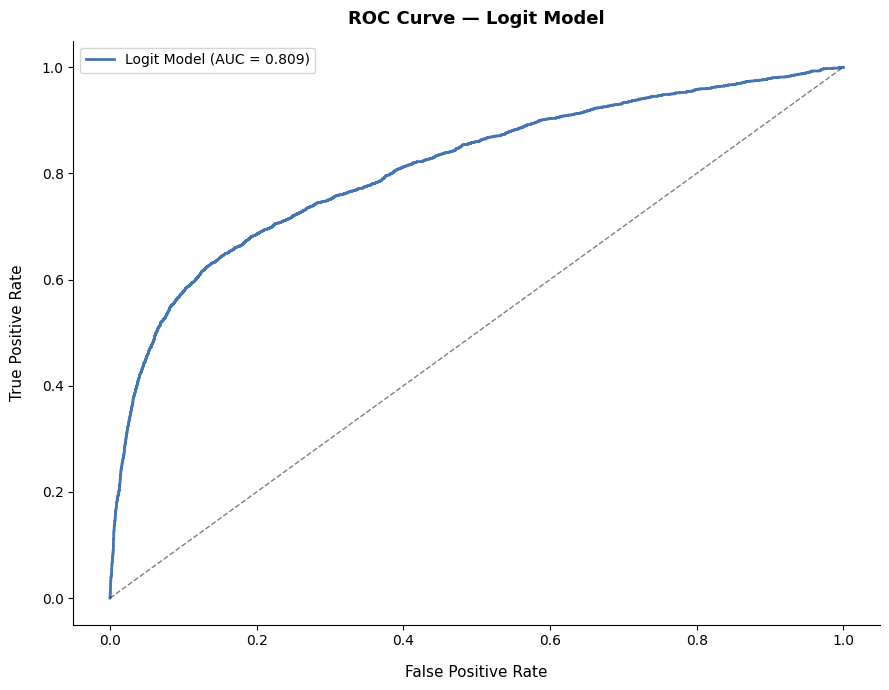

In [243]:
# ═══════════════════════════════════════════════════════════
# CELL · ROC + PRECISION-RECALL CURVES
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(figsize=(9, 7))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, probs_test)
auc_score   = roc_auc_score(y_test, probs_test)

axes.plot(fpr, tpr, color='#4575b4', lw=2,
             label=f'Logit Model (AUC = {auc_score:.3f})')
axes.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
axes.set_xlabel('False Positive Rate', fontsize=11, labelpad=12)
axes.set_ylabel('True Positive Rate', fontsize=11, labelpad=12)
axes.set_title('ROC Curve — Logit Model', fontsize=13,
                  fontweight='bold', pad=12)
axes.legend(fontsize=10)
axes.spines[['top', 'right']].set_visible(False)
axes.grid(False)

plt.tight_layout()
plt.show()

## Random Forest

In [244]:
# ═══════════════════════════════════════════════════════════
# CELL · RANDOM FOREST — PREPARATION
# ═══════════════════════════════════════════════════════════

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import accuracy_score

rf_vars = m9_vars.copy()

train_rf = train[rf_vars + ['Financial_Distress', 'Year']].dropna().sort_values('Year').copy()
test_rf  = test[rf_vars + ['Financial_Distress']].dropna().copy()

X_train_rf = train_rf[rf_vars].values
y_train_rf = train_rf['Financial_Distress'].values
X_test_rf  = test_rf[rf_vars].values
y_test_rf  = test_rf['Financial_Distress'].values

print("RANDOM FOREST — SAMPLE")
print("=" * 50)
print(f"  Train (2019–2022) : {len(train_rf):,} obs  |  "
      f"Distress: {y_train_rf.mean()*100:.1f}%")
print(f"  Test  (2023–2024) : {len(test_rf):,} obs  |  "
      f"Distress: {y_test_rf.mean()*100:.1f}%")
print(f"  Features          : {len(rf_vars)}")

RANDOM FOREST — SAMPLE
  Train (2019–2022) : 40,986 obs  |  Distress: 15.2%
  Test  (2023–2024) : 21,047 obs  |  Distress: 13.5%
  Features          : 9


In [245]:
# ═══════════════════════════════════════════════════════════
# CELL · RANDOM FOREST — HYPERPARAMETER TUNING
# ═══════════════════════════════════════════════════════════

tscv = TimeSeriesSplit(n_splits=3)

param_grid = {
    'n_estimators'    : [100, 300, 500],
    'max_depth'       : [4, 6, 8],
    'min_samples_leaf': [50, 100, 200],
    'class_weight'    : ['balanced'],
}

rf_cv = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=tscv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
rf_cv.fit(X_train_rf, y_train_rf)

print(f"Best params : {rf_cv.best_params_}")
print(f"Best CV AUC : {rf_cv.best_score_:.4f}")

rf_best = rf_cv.best_estimator_

Best params : {'class_weight': 'balanced', 'max_depth': 8, 'min_samples_leaf': 50, 'n_estimators': 500}
Best CV AUC : 0.8374


In [246]:
# ═══════════════════════════════════════════════════════════
# CELL · RANDOM FOREST — PREDICTION
# ═══════════════════════════════════════════════════════════

# Probabilities
probs_train_rf = rf_best.predict_proba(X_train_rf)[:,1]
probs_test_rf  = rf_best.predict_proba(X_test_rf)[:,1]

# Overfitting check
train_auc_rf = roc_auc_score(y_train_rf, probs_train_rf)
test_auc_rf  = roc_auc_score(y_test_rf,  probs_test_rf)

print("OVERFITTING CHECK")
print("=" * 40)
print(f"  Train AUC : {train_auc_rf:.4f}")
print(f"  Test AUC  : {test_auc_rf:.4f}")
print(f"  Gap       : {train_auc_rf - test_auc_rf:.4f} "
      f"({'⚠ overfitting' if train_auc_rf - test_auc_rf > 0.05 else '✓ ok'})")

# Optimal threshold on TRAIN
thresholds   = np.linspace(0.05, 0.95, 100)
f1_train_rf  = [f1_score(y_train_rf, probs_train_rf > t, zero_division=0)
                for t in thresholds]
opt_t_rf     = thresholds[np.argmax(f1_train_rf)]

# Apply to TEST
y_pred_rf = (probs_test_rf > opt_t_rf).astype(int)
cm_rf     = confusion_matrix(y_test_rf, y_pred_rf)

print()
print("RANDOM FOREST — PREDICTION RESULTS")
print("=" * 55)
print(f"  Optimal threshold  : {opt_t_rf:.3f}  (optimized on train)")
print()
print(f"  AUC-ROC            : {test_auc_rf:.4f}")
print(f"  F1-Score           : {f1_score(y_test_rf, y_pred_rf):.4f}")
print(f"  Precision          : {precision_score(y_test_rf, y_pred_rf):.4f}")
print(f"  Recall             : {recall_score(y_test_rf, y_pred_rf):.4f}")
print()
print("CONFUSION MATRIX:")
print(f"  TN={cm_rf[0,0]:,}  FP={cm_rf[0,1]:,}")
print(f"  FN={cm_rf[1,0]:,}  TP={cm_rf[1,1]:,}")

OVERFITTING CHECK
  Train AUC : 0.8643
  Test AUC  : 0.8710
  Gap       : -0.0067 (✓ ok)

RANDOM FOREST — PREDICTION RESULTS
  Optimal threshold  : 0.605  (optimized on train)

  AUC-ROC            : 0.8710
  F1-Score           : 0.5862
  Precision          : 0.5500
  Recall             : 0.6275

CONFUSION MATRIX:
  TN=16,749  FP=1,458
  FN=1,058  TP=1,782


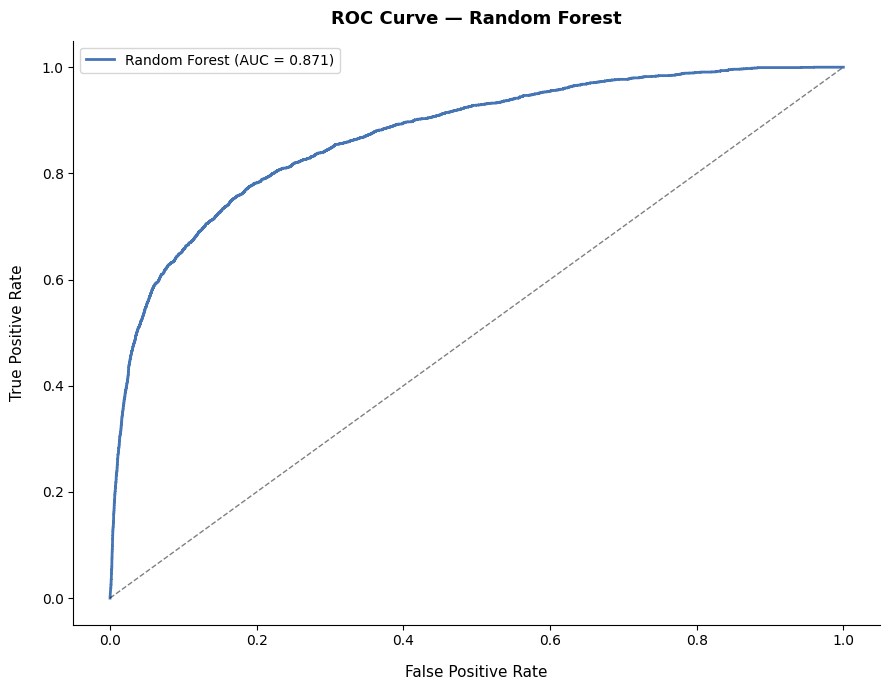

In [247]:
# ═══════════════════════════════════════════════════════════
# CELL · ROC + PRECISION-RECALL CURVES
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(figsize=(9, 7))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_rf, probs_test_rf)
auc_score   = roc_auc_score(y_test_rf, probs_test_rf)

axes.plot(fpr, tpr, color='#4575b4', lw=2,
             label=f'Random Forest (AUC = {auc_score:.3f})')
axes.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
axes.set_xlabel('False Positive Rate', fontsize=11, labelpad=12)
axes.set_ylabel('True Positive Rate', fontsize=11, labelpad=12)
axes.set_title('ROC Curve — Random Forest', fontsize=13,
                  fontweight='bold', pad=12)
axes.legend(fontsize=10)
axes.spines[['top', 'right']].set_visible(False)
axes.grid(False)


plt.tight_layout()
plt.show()

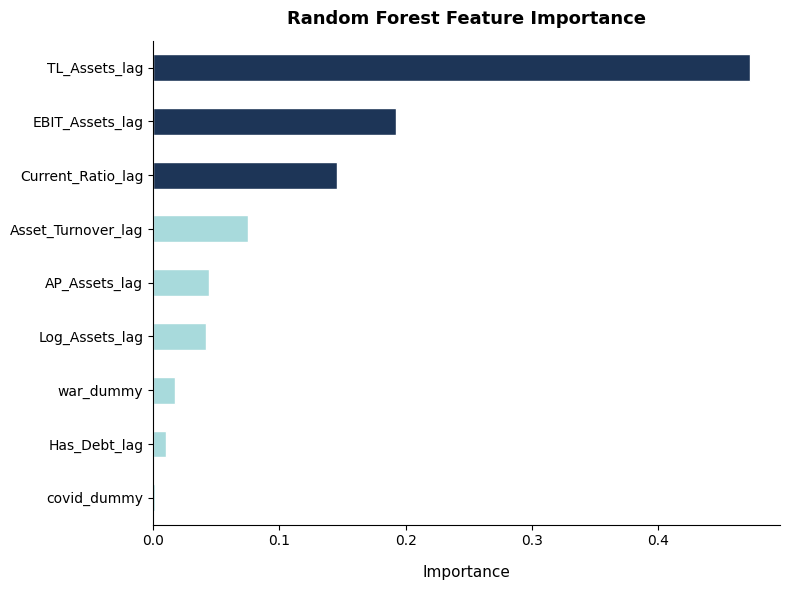

In [255]:
# ═══════════════════════════════════════════════════════════
# CELL · RANDOM FOREST — FEATURE IMPORTANCE
# ═══════════════════════════════════════════════════════════

importances = rf_best.feature_importances_
feat_imp = pd.Series(importances, index=rf_vars).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#1d3557' if i >= len(feat_imp)-3 else '#a8dadc'
          for i in range(len(feat_imp))]

feat_imp.plot(kind='barh', ax=ax, color=colors, edgecolor='white')

ax.set_title('Random Forest Feature Importance',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Importance', fontsize=11, labelpad=12)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.show()

## Comparison

In [249]:
# ═══════════════════════════════════════════════════════════
# CELL · MODELS COMPARISON TABLE
# ═══════════════════════════════════════════════════════════

comparison = pd.DataFrame([
    {
        'Model'     : 'Logit Model',
        'AUC-ROC'   : roc_auc_score(y_test, probs_test),
        'F1-Score'  : f1_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred),
        'Recall'    : recall_score(y_test, y_pred),
        'Threshold' : opt_t,
    },
    {
        'Model'     : 'Random Forest',
        'AUC-ROC'   : test_auc_rf,
        'F1-Score'  : f1_score(y_test_rf, y_pred_rf),
        'Precision' : precision_score(y_test_rf, y_pred_rf),
        'Recall'    : recall_score(y_test_rf, y_pred_rf),
        'Threshold' : opt_t_rf,
    },
])

print("MODELS COMPARISON — LOGIT vs RANDOM FOREST")
print("=" * 65)
print(comparison.to_string(
    index=False,
    float_format='{:.4f}'.format
))
print()
print(f"Best AUC : {comparison.loc[comparison['AUC-ROC'].idxmax(), 'Model']}")
print(f"Best F1  : {comparison.loc[comparison['F1-Score'].idxmax(), 'Model']}")

MODELS COMPARISON — LOGIT vs RANDOM FOREST
        Model  AUC-ROC  F1-Score  Precision  Recall  Threshold
  Logit Model   0.8086    0.5136     0.5806  0.4606     0.2045
Random Forest   0.8710    0.5862     0.5500  0.6275     0.6045

Best AUC : Random Forest
Best F1  : Random Forest


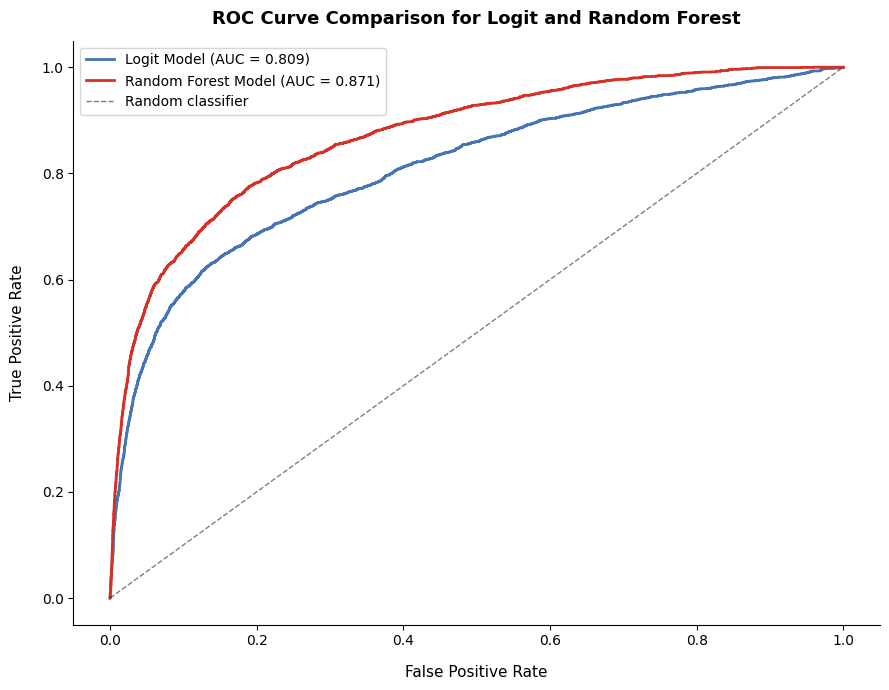

In [256]:
# ═══════════════════════════════════════════════════════════
# CELL · ROC CURVES — LOGIT vs RF
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(figsize=(9, 7))

# ── ROC Curve ──
fpr_logit, tpr_logit, _ = roc_curve(y_test, probs_test)
fpr_rf,    tpr_rf,    _ = roc_curve(y_test_rf, probs_test_rf)

auc_logit = roc_auc_score(y_test, probs_test)
auc_rf    = roc_auc_score(y_test_rf, probs_test_rf)

axes.plot(fpr_logit, tpr_logit, color='#4575b4', lw=2,
             label=f'Logit Model (AUC = {auc_logit:.3f})')
axes.plot(fpr_rf, tpr_rf, color='#d73027', lw=2,
             label=f'Random Forest Model (AUC = {auc_rf:.3f})')
axes.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5,
             label='Random classifier')
axes.set_xlabel('False Positive Rate', fontsize=11, labelpad=12)
axes.set_ylabel('True Positive Rate', fontsize=11, labelpad=12)
axes.set_title('ROC Curve Comparison for Logit and Random Forest', fontsize=13, fontweight='bold', pad=12)
axes.legend(fontsize=10)
axes.spines[['top', 'right']].set_visible(False)
axes.grid(False)

plt.tight_layout()
plt.show()

In [251]:
import sys
!{sys.executable} -m pip install imbalanced-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [252]:
# ═══════════════════════════════════════════════════════════
# CELL · SMOTE — SENSITIVITY CHECK WITH THRESHOLD OPTIMIZATION
# ═══════════════════════════════════════════════════════════

from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
import numpy as np

predictors_m9 = [
    'EBIT_Assets_lag', 'Current_Ratio_lag', 'TL_Assets_lag',
    'AP_Assets_lag', 'Asset_Turnover_lag', 'Has_Debt_lag',
    'Log_Assets_lag', 'covid_dummy', 'war_dummy',
    'ind_Agriculture', 'ind_Heavy_Industry', 'ind_Infrastructure',
    'ind_Light_Industry', 'ind_Trade'
]

# ── Train/Test split ──
train = ana[ana['Year'].isin([2019, 2020, 2021, 2022])].dropna(subset=predictors_m9 + ['Financial_Distress'])
test  = ana[ana['Year'].isin([2023, 2024])].dropna(subset=predictors_m9 + ['Financial_Distress'])

X_train = train[predictors_m9].values
y_train = train['Financial_Distress'].values
X_test  = test[predictors_m9].values
y_test  = test['Financial_Distress'].values

print(f"Train: {len(X_train):,} obs | Distress rate: {y_train.mean()*100:.1f}%")
print(f"Test : {len(X_test):,} obs  | Distress rate: {y_test.mean()*100:.1f}%")

# ── SMOTE ──
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"After SMOTE: {len(X_train_sm):,} obs | Distress rate: {y_train_sm.mean()*100:.1f}%")

# ── Функція для оптимізації threshold по F1 на train ──
def optimize_threshold(model, X_train, y_train):
    probs = model.predict_proba(X_train)[:, 1]
    thresholds = np.linspace(0.05, 0.95, 100)
    best_t, best_f1 = 0.5, 0
    for t in thresholds:
        preds = (probs >= t).astype(int)
        f1 = f1_score(y_train, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    return best_t

# ── Logit без SMOTE ──
logit_base = LogisticRegression(max_iter=1000, random_state=42)
logit_base.fit(X_train, y_train)
t_base = optimize_threshold(logit_base, X_train, y_train)
prob_base = logit_base.predict_proba(X_test)[:, 1]
pred_base = (prob_base >= t_base).astype(int)

# ── Logit зі SMOTE ──
logit_smote = LogisticRegression(max_iter=1000, random_state=42)
logit_smote.fit(X_train_sm, y_train_sm)
t_smote = optimize_threshold(logit_smote, X_train_sm, y_train_sm)
prob_smote = logit_smote.predict_proba(X_test)[:, 1]
pred_smote = (prob_smote >= t_smote).astype(int)

print("\n" + "=" * 60)
print("COMPARISON: Logit Baseline vs Logit + SMOTE")
print("=" * 60)
print(f"{'Metric':<20} {'Baseline':>15} {'SMOTE':>15}")
print("-" * 60)
print(f"{'Threshold':<20} {t_base:>15.3f} {t_smote:>15.3f}")
print(f"{'AUC':<20} {roc_auc_score(y_test, prob_base):>15.4f} {roc_auc_score(y_test, prob_smote):>15.4f}")
print(f"{'F1':<20} {f1_score(y_test, pred_base):>15.4f} {f1_score(y_test, pred_smote):>15.4f}")
print(f"{'Precision':<20} {precision_score(y_test, pred_base):>15.4f} {precision_score(y_test, pred_smote):>15.4f}")
print(f"{'Recall':<20} {recall_score(y_test, pred_base):>15.4f} {recall_score(y_test, pred_smote):>15.4f}")
print("=" * 60)

Train: 40,986 obs | Distress rate: 15.2%
Test : 21,047 obs  | Distress rate: 13.5%
After SMOTE: 69,520 obs | Distress rate: 50.0%

COMPARISON: Logit Baseline vs Logit + SMOTE
Metric                      Baseline           SMOTE
------------------------------------------------------------
Threshold                      0.205           0.386
AUC                           0.8069          0.8168
F1                            0.5193          0.4098
Precision                     0.5619          0.2808
Recall                        0.4827          0.7581
